<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="https://www.uoc.edu/content/dam/news/images/noticies/2016/202-nova-marca-uoc.jpg" align="left" width="45%">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.891 · Aprendizaje automático · PEC3</p>
<p style="margin: 0; text-align:right;">2025-1 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>

# PEC 3: Métodos supervisados

En esta práctica veremos diferentes métodos supervisados y trataremos de optimizar diferentes métricas. Veremos como los diferentes modelos clasifican las observaciones y con cuales obtenemos mayor rendimiento. Después aplicaremos todo lo que hemos aprendido hasta ahora a un dataset nuevo simulando un caso práctico real.

1. [Exploración de algoritmos supervisados](#ej1) \
    1.1. [Carga de datos](#ej1) \
    1.2. [Análisis Exploratorio de Datos](#ej12) \
    1.3. [Preparación de datos](#ej13) \
    1.4. [K vecinos más próximos (KNN)](#ej14) \
    1.5. [Máquinas de soporte vectorial (SVM)](#ej15) \
    1.6. [Árboles de decisión](#ej16) 
3. [Comprensión de algoritmos supervisados](#ej2)
4. [Implementación del caso práctico](#ej3)\
    2.1. [Carga de datos](#ej31) \
    2.2. [Análisis Exploratorio de Datos](#ej32) \
    2.3. [Preprocesamiento de Datos](#ej33) \
    2.4. [Modelización](#ej34) 


<u>Consideraciones generales</u>:

- La solución planteada no puede utilizar métodos, funciones o parámetros declarados **_deprecated_** en futuras versiones, a excepción de la carga de datos cómo se indica posteriormente.
- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
    <strong>Nombre y apellidos: JULIO UBEDA QUESADA</strong>
</div>

In [1]:
import os
import tqdm
import kagglehub
import umap

import seaborn as sns
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

from statsmodels.graphics.mosaicplot import mosaic

from sklearn import datasets
from sklearn import tree
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, train_test_split, cross_val_score

import warnings
warnings.filterwarnings('ignore', message='^.*will change.*$', category=FutureWarning)

get_ipython().run_line_magic('matplotlib', 'inline')

## Funciones auxiliares

He creado 1 funcion que ofrece un resumen centrado únicamente en las columnas que contienen valores nulos, indicando cuántos son, su porcentaje respecto al total y el tipo de dato correspondiente.

In [ ]:
def null_summary(data): 
    """
    Devuelve un resumen de las columnas del DataFrame que contienen valores nulos.
    Incluye: Column, Non-null Count, Null Count, % Null Values y TotalCount.

    :param data: DataFrame de pandas.
    :return: DataFrame con el resumen de las columnas del DataFrame que contienen valores nulos.
    """
    # Crear base del resumen
    total = len(data)
    summary = pd.DataFrame({
        'Column': data.columns,
        'Data Type': data.dtypes.astype(str),
        'Non-null Count': data.count().values,
        'Null Count': data.isnull().sum().values,
        '% Null Values': ((data.isnull().sum() / total) * 100).round(2).values,
        'TotalCount': total
    })
    
    # Filtrar y ordenar solo columnas con valores nulos
    summary = summary[summary['Null Count'] > 0]
    summary = summary.sort_values(by='% Null Values', ascending=False).reset_index(drop=True)

    
    return summary

<a id='ej1'></a>
# 1. Exploración de algoritmos supervisados (4.5 puntos)

## 1.1. Carga de datos

La aplicación de técnicas de ciencia de datos en la detección de software malicioso resulta de gran interés y utilidad, ya que permite analizar grandes volúmenes de datos y descubrir patrones complejos de comportamiento malicioso que los métodos tradicionales no logran identificar. Los modelos de aprendizaje automático aportan un valor añadido al facilitar la detección adaptativa y temprana de amenazas en constante evolución, anticipándose incluso a nuevas variantes de ransomware que los métodos basados en firmas o reglas estáticas no pueden predecir.

Por ello, en este ejercicio vamos a trabajar con un subconjunto del dataset [Ransomware 2024](https://zenodo.org/records/13890887#). Este dataset nos permitirá analizar las diferentes caracteríscas del software que se pueden utilizar para abordar el problema de la detección automática de ransomware. En total, el conjunto de datos ofrece 21.752 muestras etiquetadas, con 10.876 archivos maliciosos y 10.876 benignos, abarcando 26 familias distintas de malware con especial énfasis en varias familias notorias de ransomware.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> Cargad el conjunto de datos 'Ransomware_2024_subset.cvs' en una variable con nombre 'data' y mostrad:

1. El número y nombre de los atributos descriptivos (variables que podrían ser usadas para predecir la variable objetivo "Malware").
2. El número de filas (muestras) del conjunto de datos.
3. Verificad si hay o no "missing values" y en qué columnas.
   
</div>

### 1.1.1. Análisis de Estructura y Tipos de Datos

El conjunto de datos contiene **21.752 muestras** y **23 columnas**, de las cuales:

* **22 son atributos descriptivos**
* **1 es la variable objetivo:** `Malware` (0 = benigno, 1 = malicioso)

Un aspecto importante es que **no existen valores nulos**, por lo que no se requiere imputación ni eliminación de registros.

Los atributos incluyen:

* **Características de cabecera PE (Portable Executable):** `PEType`, `LoaderFlags`, `SizeofStackReserve`, etc.
* **Indicadores de actividad del sistema:** `registry_*`, `network_*`, `processes_*`. 
* **Indicadores de archivos sospechosos o maliciosos:** `files_suspicious`, `files_malicious`, `files_text`, etc.
* **Atributos numéricos relacionados con `APIs` y `DLLs_calls`**.

In [3]:
# Carga de datos
data = pd.read_csv("../Data/Ransomware_2024_subset.csv")
data.head()

,PEType,bytes_on_last_page,max_extra_paragraphs,init_sp_value,SizeofStackReserve,LoaderFlags,text_PointerToRelocations,registry_read,registry_write,registry_delete,...,processes_suspicious,processes_monitored,total_procsses,files_malicious,files_suspicious,files_text,files_unknown,dlls_calls,apis,Malware
0,PE32+,0x0090,0xFFFF,0x00B8,0x0000000000100000,0x00000000,0x00000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,162.0,0
1,PE32+,0x0090,0xFFFF,0x00B8,0x0000000000100000,0x00000000,0x00000000,5.0,0.0,0.0,...,0.0,2.0,93.0,0.0,0.0,0.0,0.0,22.0,778.0,0
2,PE32,0x0090,0xFFFF,0x00B8,0x00100000,0x00000000,0x00000000,58.0,0.0,0.0,...,0.0,1.0,35.0,0.0,0.0,0.0,0.0,1.0,1.0,0
3,PE32+,0x0090,0xFFFF,0x008B,0x0000000000200000,0x00000000,0x00000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,40.0,0
4,PE32,0x0090,0xFFFF,0x00B8,0x00100000,0x00000000,0x00000000,253.0,0.0,0.0,...,0.0,1.0,36.0,0.0,0.0,0.0,0.0,1.0,1.0,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21752 entries, 0 to 21751
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PEType                     21752 non-null  object 
 1   bytes_on_last_page         21752 non-null  object 
 2   max_extra_paragraphs       21752 non-null  object 
 3   init_sp_value              21752 non-null  object 
 4   SizeofStackReserve         21752 non-null  object 
 5   LoaderFlags                21752 non-null  object 
 6   text_PointerToRelocations  21752 non-null  object 
 7   registry_read              21752 non-null  float64
 8   registry_write             21752 non-null  float64
 9   registry_delete            21752 non-null  float64
 10  network_dns                21752 non-null  float64
 11  network_http               21752 non-null  float64
 12  network_connections        21752 non-null  float64
 13  processes_suspicious       21752 non-null  flo

In [5]:
# Variable objetivo  
target = "Malware"

# Atributos descriptivos (todas las columnas menos el target)
atributos_descriptivos = [col for col in data.columns if col != target]

# Mostrar resumen ordenado
print("=" * 50)
print("\tInformación del Dataset")
print("=" * 50)

# Información general
print(f"- Nº de muestras        : {data.shape[0]}")
print(f"- Nº total de columnas  : {data.shape[1]}")

# Variable objetivo
print("\n- Variable objetivo:")
print(f"\t* {target}")

# Atributos descriptivos
print("\n- Atributos descriptivos:")
print(f"\t* Número de atributos: {len(atributos_descriptivos)}")
print("\t* Lista de atributos:")
for atributo in atributos_descriptivos:
    print(f"\t\t- {atributo}")

print("=" * 50)


	Información del Dataset
- Nº de muestras        : 21752
- Nº total de columnas  : 23

- Variable objetivo:
	* Malware

- Atributos descriptivos:
	* Número de atributos: 22
	* Lista de atributos:
		- PEType
		- bytes_on_last_page
		- max_extra_paragraphs
		- init_sp_value
		- SizeofStackReserve
		- LoaderFlags
		- text_PointerToRelocations
		- registry_read
		- registry_write
		- registry_delete
		- network_dns
		- network_http
		- network_connections
		- processes_suspicious
		- processes_monitored
		- total_procsses
		- files_malicious
		- files_suspicious
		- files_text
		- files_unknown
		- dlls_calls
		- apis


In [6]:
# Revision de valores nulos (missing values)
null_summary(data)

,Column,Data Type,Non-null Count,Null Count,% Null Values,TotalCount


<a id='ej12'></a>
## 1.2. Análisis Exploratorio de Datos (EDA) (0.75 puntos)

En este apartado vamos a realizar un análisis de exploratorio de datos centrado en analizar patrones y relaciones entre las diversas variables.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> Calculad la correlación de las variables numéricas y mostrad un mapa de calor con el resultado.
</div>

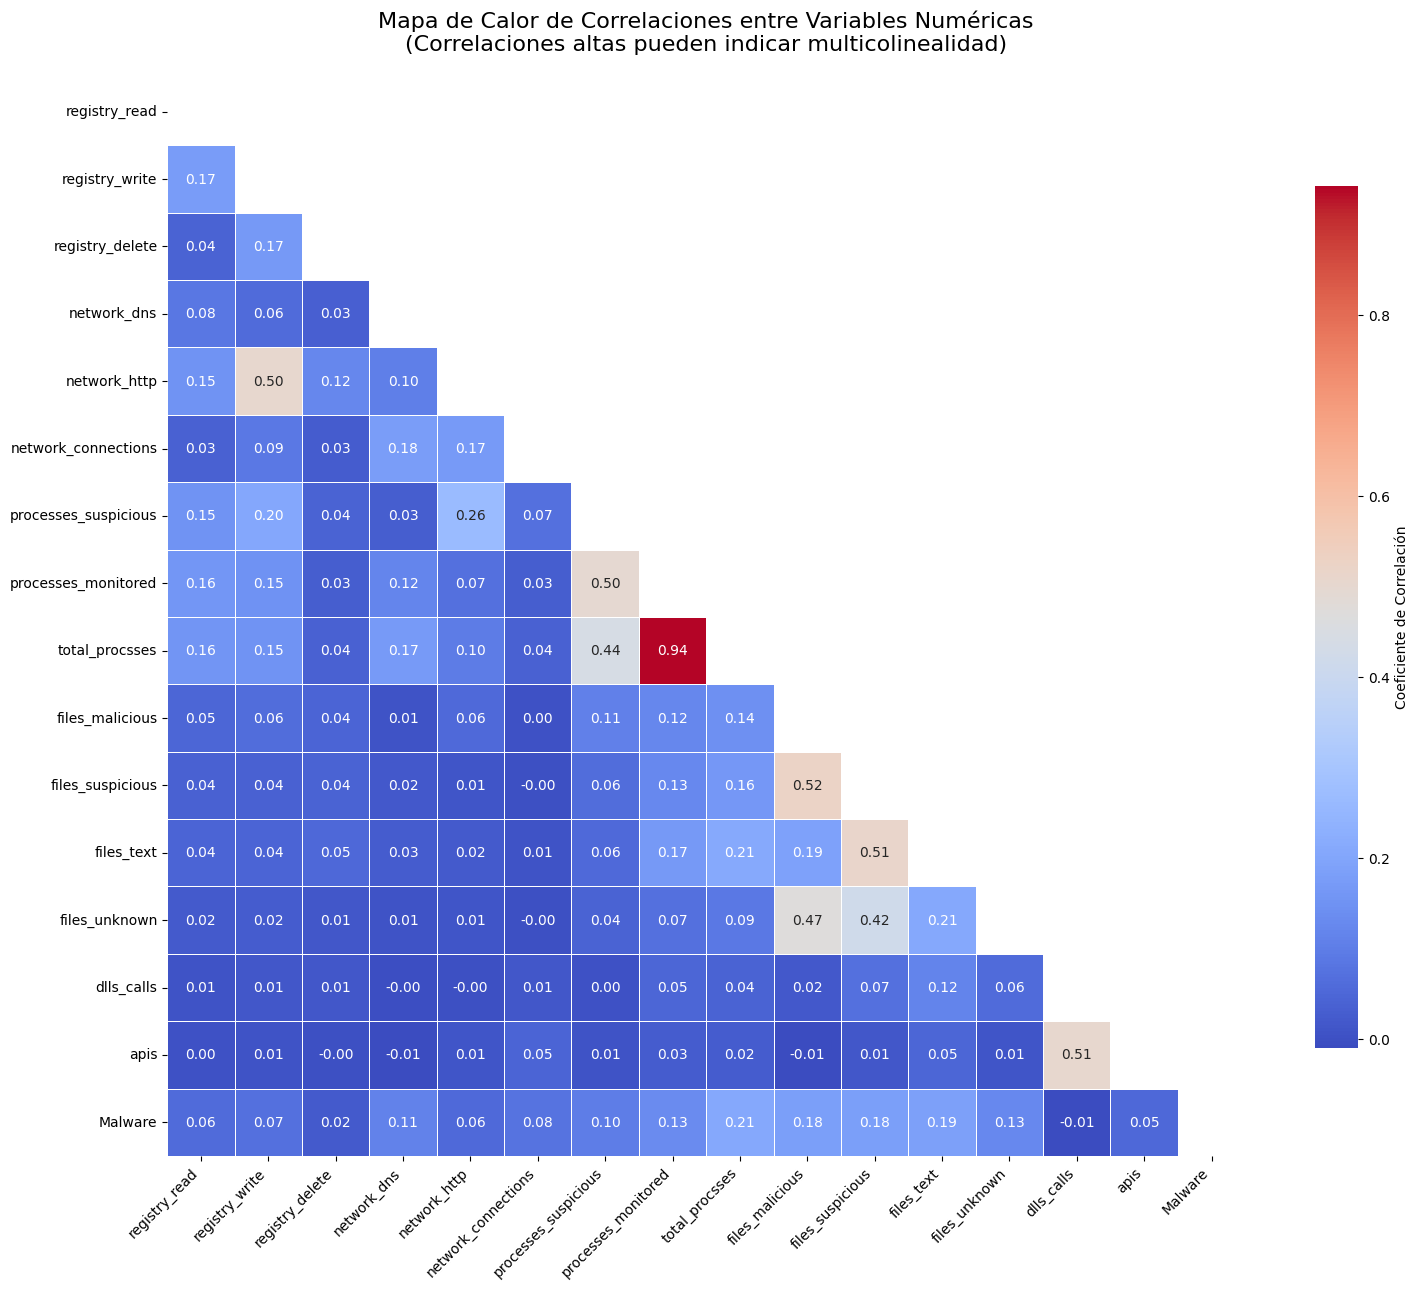

In [7]:
# Selección de variables numéricas
var_num = data.select_dtypes(include=["int64", "float64"])

# Matriz de correlación
corr = var_num.corr()

# Heatmap 
plt.figure(figsize=(18, 14))

# Máscara para mostrar solo la mitad superior
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"shrink": 0.8, "label": "Coeficiente de Correlación"},
    square=True,
)

plt.title(
    "Mapa de Calor de Correlaciones entre Variables Numéricas\n"
    "(Correlaciones altas pueden indicar multicolinealidad)",
    fontsize=16,
    pad=20,
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Guardar gráfico en alta resolución
plt.savefig("../Visualizaciones/correlaciones_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()


### 1.2.1 Análisis de Correlaciones (Heatmap)

El **mapa de calor** revela relaciones lineales importantes entre las variables numéricas:

**Correlaciones muy altas:**

-  `total_processes` y `processes_monitored` (0.94): Muestra una alta multicolinealidad, indicando redundancia severa que debe resolverse eliminando una de estas variables. 

**Correlaciones moderadas:**

- `network_http` y `registry_write` (0.50): Posiblemente debido a cuando un Malware se comunica externamente y suele establecer persistencia mediante modificación del registro.
- `processes_suspicious` y `processes_monitored` (0.50): Al parecer los sistemas de monitoreo priorizan correctamente procesos con comportamientos anómalos.
- `processes_suspicious` y `total_processes` (0.44): Mayor actividad de procesos aumenta probabilísticamente comportamientos sospechosos.
- `apis` y `dlls_calls` (0.51): Evidencia la relación arquitectónica inherente de Windows donde APIs se implementan en DLLs.
- Variables de archivos (`files_malicious`, `files_suspicious`, `files_text` y `files_unknown`) entre 0.42-0.52: Indica que el malware manipula múltiples tipos de archivos simultáneamente, o comportamientos comunes entre archivos sospechosos y sus textos.

**Correlaciones bajas o casi inexistentes:**

- Variables de registro (`registry_read`, `registry_write`, `registry_delete`) muestran correlaciones prácticamente nulas con el target y entre sí.

**Relación con la variable objetivo:**

- Correlaciones generalmente débiles con `Malware` (<= 0.21), sugiriendo ausencia de predictores lineales fuertes.
- Variables más prometedoras: `total_processes` (0.21), `files_` (0.13-0.19) y `network_dns` (0.11).

**Conclusión:**

El dataset tiene **poca redundancia**, salvo en el bloque de variables relacionadas con procesos y archivos, donde sí podría ser necesario revisar multicolinealidad para modelos lineales.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> Seleccionad cuatro características numéricas en base al resultado obtenido en el apartado anterior y representad gráficamente las relaciones entre estas variables (scatterplots). Diferenciad con colores diferentes las diferentes clases.

    
La finalidad es poder observar y analizar las correlaciones de manera gráfica entre algunas de las variables.
<hr>
Sugerencia: podéis usar la función "pairplot" de la librería 'seaborn' con el parámetro "hue".
</div>

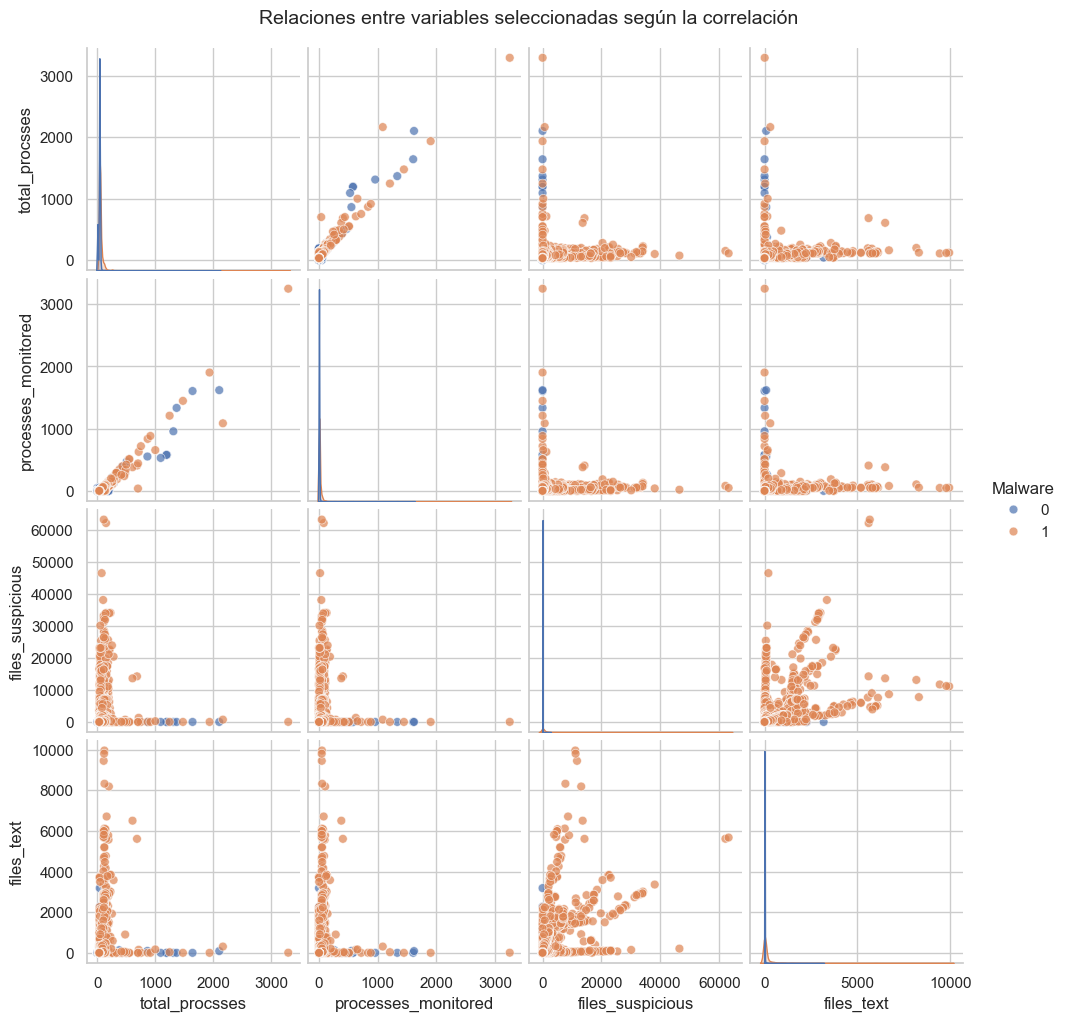

In [8]:
# Selección de 4 variables numéricas relevantes
vars_seleccionadas = [
    "total_procsses",
    "processes_monitored",
    "files_suspicious",
    "files_text"
]

# Pairplot con diferenciación por clase
sns.set(style="whitegrid")

g = sns.pairplot(
    data,
    vars=vars_seleccionadas,
    hue="Malware",
    diag_kind="kde",
    plot_kws={"alpha": 0.7, "s": 40},
    height=2.5
)

g.fig.suptitle("Relaciones entre variables seleccionadas según la correlación", 
               y=1.02, fontsize=14)

# Guardar imagen
g.fig.savefig("../Visualizaciones/pairplot_variables_correlacion.png", dpi=300, bbox_inches="tight")

plt.show()

### 1.2.2. Análisis de las variables seleccionadas por correlación (Pairplot)

El **gráfico de pairplot** (entre `total_procsses`, `processes_monitored`, `files_suspicious` y `files_text`) nos da pistas sobre la forma de los datos:

**Líneas verticales/horizontales:**

-El dataset tiene muchos valores repetidos o acumulados en 0 en varias variables (lo que es de esperar de logs de actividad).

**Asociación visible con `Malware`:**

- La variable `Malware` presenta con más frecuencia valores **elevados** en `total_procsses`, `processes_monitored`, `files_suspicious` y `files_text`.
- Esto respalda que los malware suelen generar mucha actividad en archivos y procesos sospechosos.

**Clúster diagonal entre `total_procsses` y `processes_monitored`:**

- Esto refuerza la fuerte correlación detectada en el heatmap.

**Conclusión:**

Las variables relacionadas con actividad del sistema (procesos, archivos y eventos sospechosos) parecen ser **buenas candidatas para predicción**.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> Mostrad un gráfico de mosaico para cada una de las variables categóricas, de forma que en cada gráfico se visualice la relación entre una variable categórica y la variable objetivo (Malware).
<hr>
Sugerencia: podéis usar la función "mosaic" de la librería 'statsmodels'.

</div>

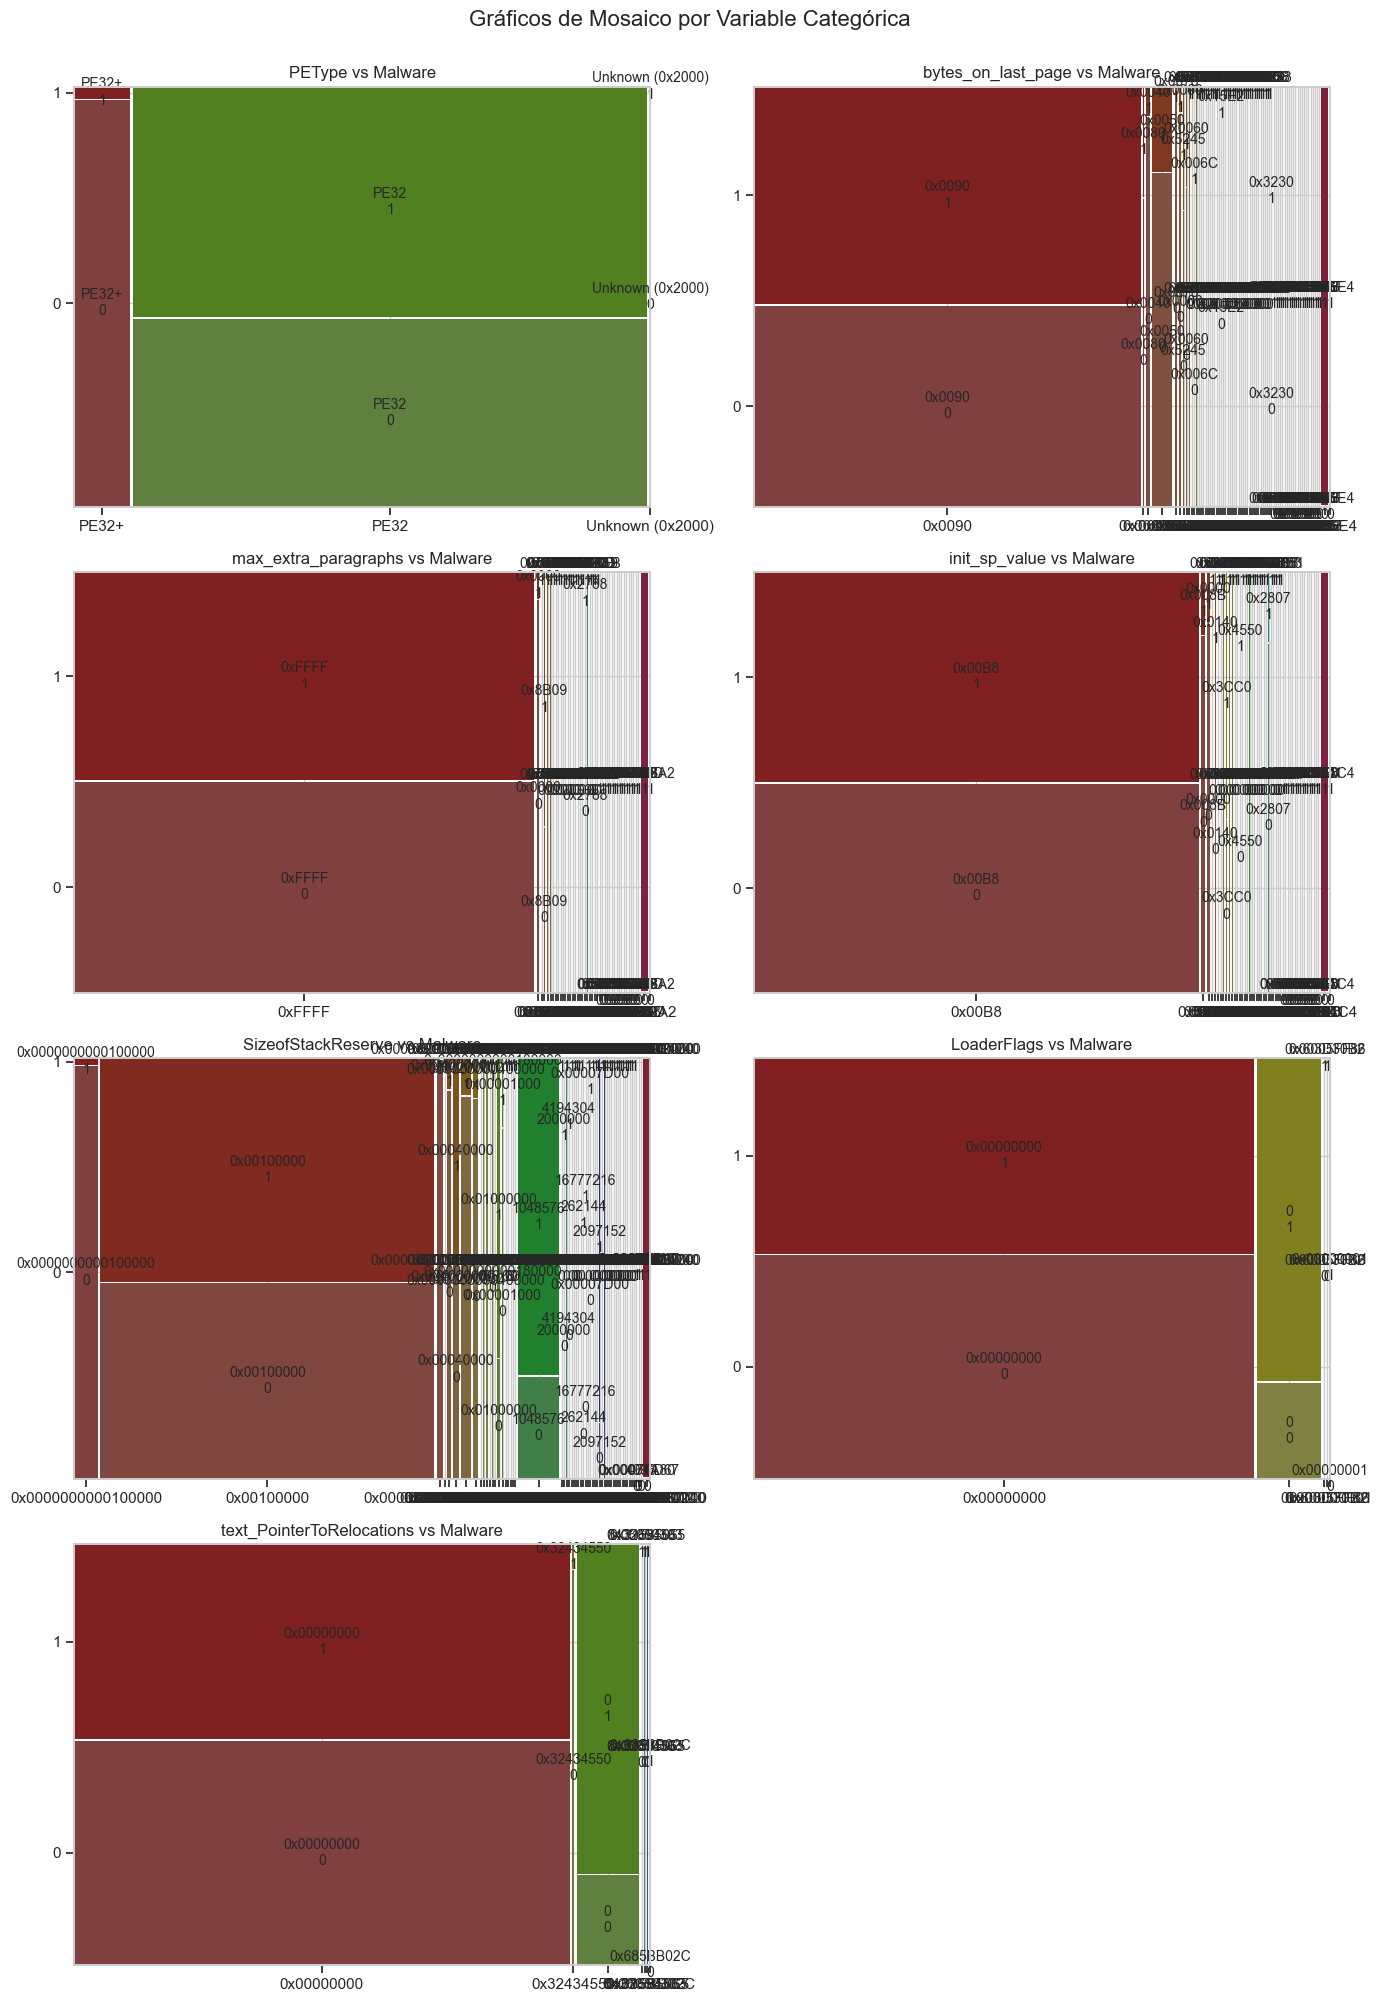

In [9]:
# Selección de variables categóricas
vars_cat = data.select_dtypes(include=["object", "category"]).columns

# Figura combinada
n = len(vars_cat)
cols = 2 
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))

# Estandarizar formato de ejes en matriz 2D
axes = axes.flatten()

# Gráfico de mosaico
for i, var in enumerate(vars_cat):
    ax = axes[i]
    mosaic(data, [var, "Malware"], ax=ax)
    ax.set_title(f"{var} vs Malware", fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Gráficos de Mosaico por Variable Categórica", fontsize=16, y=1)

plt.tight_layout()
plt.savefig("../Visualizaciones/mosaicos_combinados.png", dpi=300, bbox_inches="tight")
plt.show()


### 1.2.3. Análisis de variables categóricas (Scatter Plots)

Analizando las variables categóricas (como `PEType`, `LoaderFlags`, etc.) frente a la variable objetivo `Malware` se observa que existen:

**Categorías muy desbalanceadas:**

- `PEType`: Predomina PE32, con distribución similar entre malware/no-malware. 
- `bytes_on_last_page`, `max_extra_paragraphs`, `init_sp_value`: Valores muy concentrados (0x0090, 0xFFFF, 0x00B8) con poca variabilidad discriminativa
- `SizeofStackReserve`: Extremadamente concentrado en 0x001000000, ofreciendo mínima información
- `LoaderFlags`: Casi constante (0x00000000), candidata clara a eliminación
- `text_PointerToRelocations`: Distribución muy sesgada hacia 0x00000000, con capacidad discriminativa limitada

> Nota: Las variables de encabezado PE muestran baja entropía, sugiriendo que los malware modernos no modifican significativamente estas estructuras para evitar detección por análisis estático.

**Patrones visibles según Malware:**

Algunas categorías parecen tener más proporción de malware:

* Para `PEType`, ciertas versiones ("Unknown") parecen asociarse ligeramente más al malware.  
* Algunos valores extremos de `SizeofStackReserve` y `init_sp_value` muestran mayor densidad en la clase maliciosa.

**Conclusión:**

Las variables categóricas **poseen información**, aunque en general **no parecen fuertes predictores por sí solas** salvo ciertos casos específicos. La elevada repetición de categorías indica que quizá convenga agrupar o codificar de manera más compacta.

<div class="alert alert-block alert-info">
<strong>Análisis:</strong> Comentad los resultados del análisis exploratorio
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta: Los resultados se han comentado junto a la creación de los gráficos durante el EDA. 
</strong> 
</div>

<a id='ej13'></a>
## 1.3. Preparación de datos

Para poder visualizar los resultados de cada algoritmo supervisado, vamos a reducir el dataset anterior a dos dimensiones.

**NOTA**: Este ejercicio se ha planteado desde un punto de vista didáctico, por lo que **utilizaremos en todo el ejercicio el dataset reducido a dos dimensiones** con el objetivo de visualizar las fronteras de decisión de los modelos. Aplicar directamente reducción de la dimensionalidad no tiene por qué ser la mejor técnica o aproximación para abordar el problema de aprendizaje supervisado. No obstante, nos servirá para visualizar y profundizar en el entendimiento sobre las fronteras que aprenden los diferentes modelos.


In [10]:
# Crear labels
labels = ['Benign', 'Malware']
n_classes = len(labels)

# Seleccionar columnas numéricas y categóricas
num_columns = data._get_numeric_data().columns 
categorical_columns = list(set(data.columns) - set(num_columns))

# One-hot encoding de variables categóricas
cat_df = pd.get_dummies(data[categorical_columns], dtype=int) # procesamiento de variables categóricas
data = pd.concat([data, cat_df], axis=1, join="inner")
data = data.drop(columns=categorical_columns)

# Se separa en X (features) e y (target 'Malware')
X = data.drop(columns=['Malware'])
y = data['Malware']

# Se hace split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

c:\Users\usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


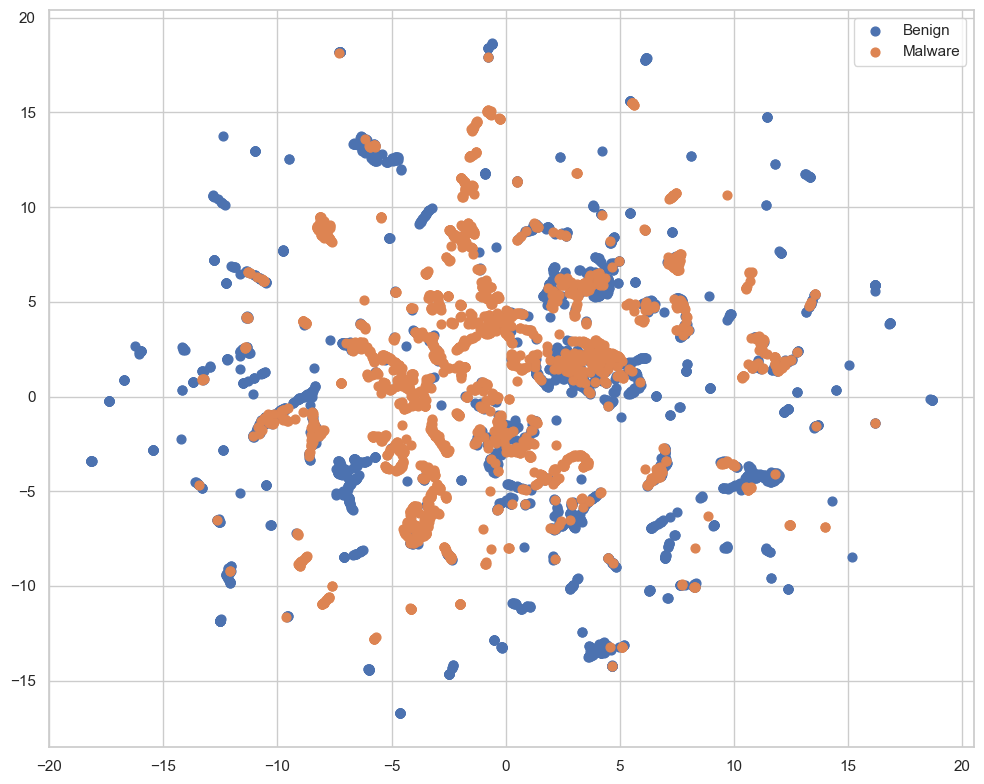

In [11]:
# Se normalizan los datos con StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Se reduce la dimensionalidad a 2D usando UMAP para visualización
model = umap.UMAP(n_components=2, n_jobs=1)
model.fit(X_train)

X_train_projection = model.transform(X_train)
X_test_projection = model.transform(X_test)

# Se visualiza la distribución de clases en 2D
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
for i in range(n_classes):
    ax.scatter(X_test_projection[y_test == i,0], X_test_projection[y_test == i,1], s=40, marker='o', label=labels[i])

plt.legend()
plt.tight_layout()
plt.show()

A lo largo del ejercicio aprenderemos a ver gráficamente las fronteras de decisión que nos devuelven los diferentes modelos. Para ello utilizaremos la función definida a continuación, que sigue los siguientes pasos:

1. Crear una meshgrid con los valores mínimo y máximo de 'x' e 'y'.
2. Predecir el clasificador con los valores de la meshgrid.
3. Hacer un reshape de los datos para tener el formato correspondiente.

Una vez hecho esto, ya podemos hacer el gráfico de las fronteras de decisión y añadir los puntos reales. Así veremos las áreas que el modelo considera que son de una clase y las que considera que son de otra. Al poner encima los puntos veremos si los clasifica correctamente en el área que les corresponde.

In [12]:
# Define the function that will visualize the decision boundary
def plot_decision_boundaries(model, X_test_projection, y_test):
    '''
    Crea una malla (meshgrid), predice en cada punto y colorea las regiones según la clase
    '''
    # Create the meshgrid with the minimum and maximum values of the x and y axes
    x_min, x_max = X_test_projection[:, 0].min() - 1, X_test_projection[:, 0].max() + 1
    y_min, y_max = X_test_projection[:, 1].min() - 1, X_test_projection[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                         np.arange(y_min, y_max, 0.05))
    
    # Prediction by using all values of the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

    # Define the colors (one for each class)
    cmap_light = ListedColormap(['gainsboro','lightgreen','peachpuff','lightcyan', 'pink'])
    cmap_bold = ['g','sandybrown','c','palevioletred']
    
    # Draw the borders
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(20,10))
    plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

    # Draw the points
    for i in range(n_classes):
        plt.scatter(X_test_projection[y_test == i,0], X_test_projection[y_test == i,1], 
                    s=40, marker='o', label=labels[i], c=cmap_bold[i])
    plt.legend(loc='best')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()

<a id='ej14'></a>
## 1.4. KNN (1.25 puntos)

En este punto, vas a entender el funcionamiento del algoritmo KNN (K-Nearest-Neighbor), que se basa en la proximidad de los puntos de datos en un espacio de características. Analizarás sus ventajas y desventajas, y comprenderás cómo los parámetros que lo componen influyen en su comportamiento.

KNN es un algoritmo de tipo supervisado basado en instancia. Esto significa:

- Supervisado: Tu conjunto de datos de entrenamiento está etiquetado con la clase o resultado esperado.
- Basado en instancia (_Lazy Learning_): El algoritmo no aprende explícitamente un modelo, como en la Regresión Logística o los árboles de decisión. En cambio, memoriza las instancias de entrenamiento y las utiliza como "conocimiento" en la fase de predicción.

Para entender cómo funciona KNN, sigue estos pasos:

1. Calcula la distancia entre el ítem a clasificar y los demás ítems del dataset de entrenamiento.
2. Selecciona los "k" elementos más cercanos, es decir, aquellos con la menor distancia, según el tipo de distancia que utilices (euclídea, coseno, manhattan, etc).
3. Realiza una "votación de mayoría" entre los k puntos seleccionados: la clase que predomine en estos puntos decidirá la clasificación final del ítem analizado.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Realiza los siguientes pasos con el dataset de entrenamiento (_train_):

1. Entrena un clasificador KNN con el hiperparámetro `n_neighbors=2` usando el clasificador `KNeighborsClassifier` de `sklearn`.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.

Si al entrenar el clasificador aparece un aviso (warning) y deseas ignorarlo, ejecuta el siguiente código antes del entrenamiento:

`import warnings`
`warnings.filterwarnings('ignore', message='^.*will change.*$', category=FutureWarning)`"

Esto te permitirá evaluar la efectividad del modelo KNN con `n_neighbors=2` en tu conjunto de datos, y entender cómo se comporta en términos de clasificación y separación de clases.    
    
    
    
</div>

In [13]:
# Entrenar KNN con los datos proyectados de UMAP para visualización
knn = KNeighborsClassifier(n_neighbors=2, n_jobs=-1)
knn.fit(X_train_projection, y_train)

# Calcular accuracy en train y test
train_accuracy = knn.score(X_train_projection, y_train)
test_accuracy = knn.score(X_test_projection, y_test)

# Imprimir ambos valores para comparar el rendimiento
print(f"Accuracy en Train: {train_accuracy:.4f}")
print(f"Accuracy en Test: {test_accuracy:.4f}")

Accuracy en Train: 0.9379
Accuracy en Test: 0.8589


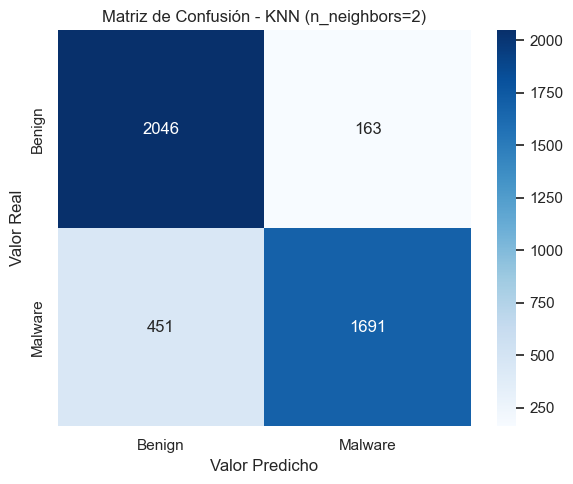


Métricas detalladas:
Verdaderos negativos (Benign correctos): 2046
Falsos Positivos (Benign predichos como Malware): 163
Falsos Negativos (Malware predichos como Benign): 451
Verdaderos positivos (Malware correctos): 1691


In [14]:
# Calcular matriz de confusión con datos de test
y_test_pred = knn.predict(X_test_projection)
cm = confusion_matrix(y_test, y_test_pred)

# Mapa de calor con la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels) # etiquetas 'Benign' y 'Malware' en los ejes
plt.title('Matriz de Confusión - KNN (n_neighbors=2)') 
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.savefig("../Visualizaciones/Matriz de Confusión - KNN (n_neighbors=2).png", dpi=300, bbox_inches="tight")
plt.show()

# Mostrar métricas adicionales
print("="*60)
print("\nMétricas detalladas:")
print("="*60)
print(f"Verdaderos negativos (Benign correctos): {cm[0, 0]}")
print(f"Falsos Positivos (Benign predichos como Malware): {cm[0, 1]}")
print(f"Falsos Negativos (Malware predichos como Benign): {cm[1, 0]}")
print(f"Verdaderos positivos (Malware correctos): {cm[1, 1]}")

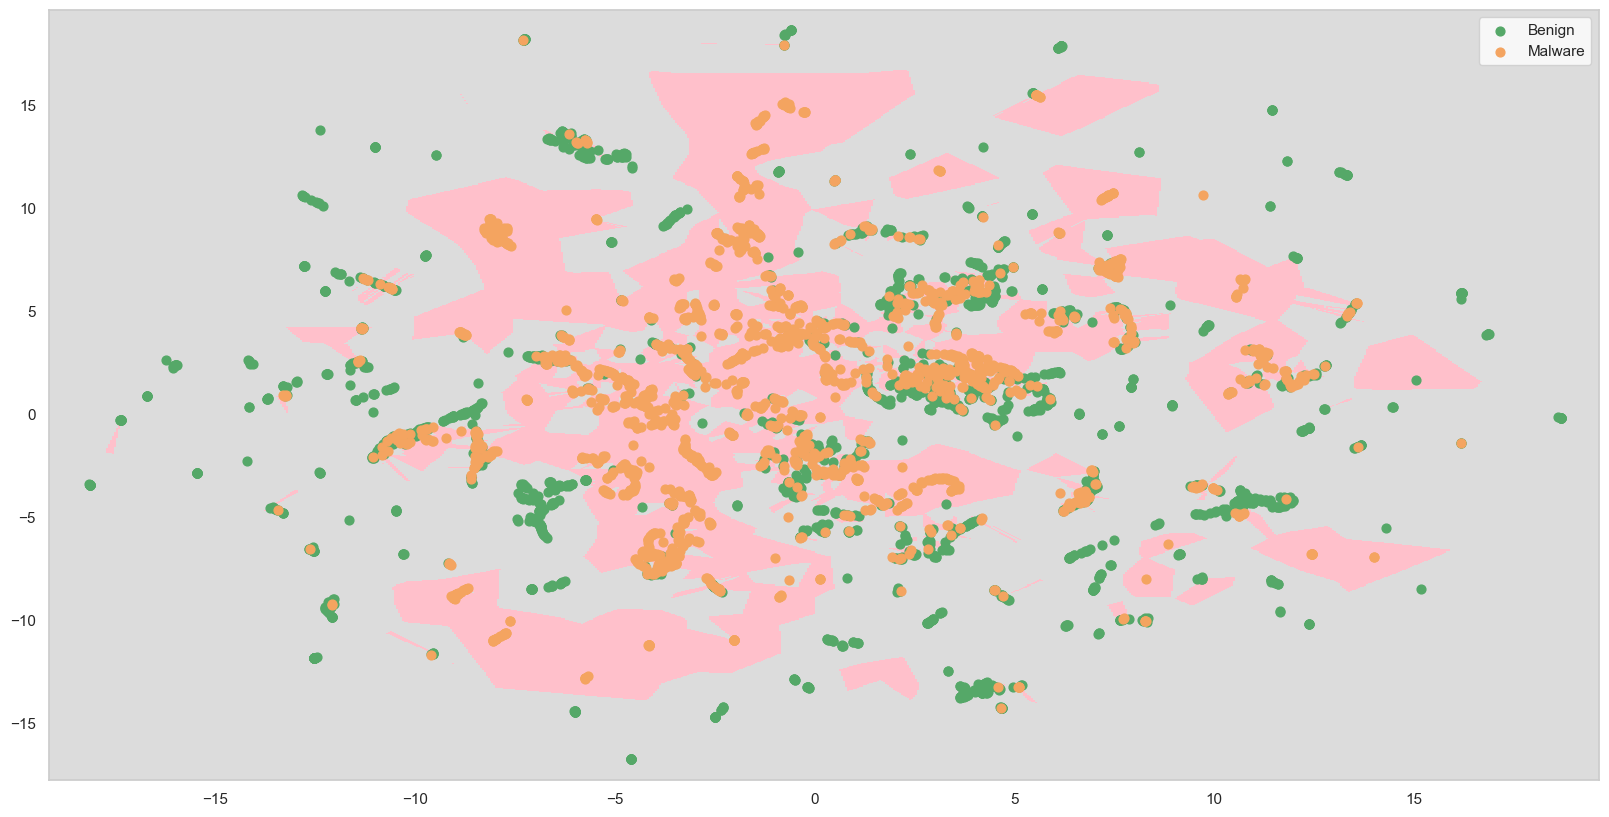

In [15]:
# Llamar a la función para graficar
plot_decision_boundaries(knn, X_test_projection, y_test)

En el modelo que has entrenado, has fijado el parámetro `n_neighbors` de forma arbitraria. Sin embargo, es posible que con otro valor obtengas una mejor predicción. Para encontrar el valor óptimo de los parámetros de un modelo (_hyperparameter tunning_), a menudo se utiliza una búsqueda de rejilla (_grid search_). Esto implica entrenar un modelo para cada combinación posible de hiperparámetros y evaluarlo mediante validación cruzada (_cross validation_) con 5 particiones estratificadas. Luego, seleccionarás la combinación de hiperparámetros que haya obtenido los mejores resultados.

En este caso, te centrarás en optimizar un solo hiperparámetro:

- 𝑘: el número de vecinos que se consideran para clasificar un nuevo ejemplo. Debes probar con todos los valores entre 1 y 20.

Realiza este proceso para identificar el número óptimo de vecinos, lo que te permitirá mejorar la precisión de tus predicciones con el modelo KNN.

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>

Para calcular el valor óptimo del hiperparámetro _k_ (`n_neighbors`), debes realizar una búsqueda de rejilla con validación cruzada. Este proceso te ayudará a encontrar el valor óptimo de _k_. Para cada valor, calcula su promedio y la desviación estándar. Luego, implementa un _lineplot_ para visualizar la precisión según los diferentes valores del hiperparámetro.

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular el mejor hiperparámetro. Para la visualización del _lineplot_, emplea la librería `Seaborn`.

Estos pasos te permitirán identificar de manera efectiva y visual el valor de _k_ que maximiza la precisión de tu modelo KNN."
</div>

In [16]:
# Definir el rango de valores de k a probar (1 a 20)
param_grid = {'n_neighbors': list(range(1, 21))}

# Crear el modelo base de KNN
knn_ = KNeighborsClassifier()


# Configurar GridSearchCV con validación cruzada estratificada de 5 folds

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=24)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=cv,  
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# Entrenar con los datos proyectados de UMAP
grid_search.fit(X_train_projection, y_train)

# Mostrar el mejor parámetro
print("="*60)
print("Mejor parámetro:")
print("="*60)
print(f"    - Mejor valor de k (n_neighbors): {grid_search.best_params_['n_neighbors']}")
print(f"    - Mejor accuracy en validación cruzada: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejor parámetro:
    - Mejor valor de k (n_neighbors): 5
    - Mejor accuracy en validación cruzada: 0.8878


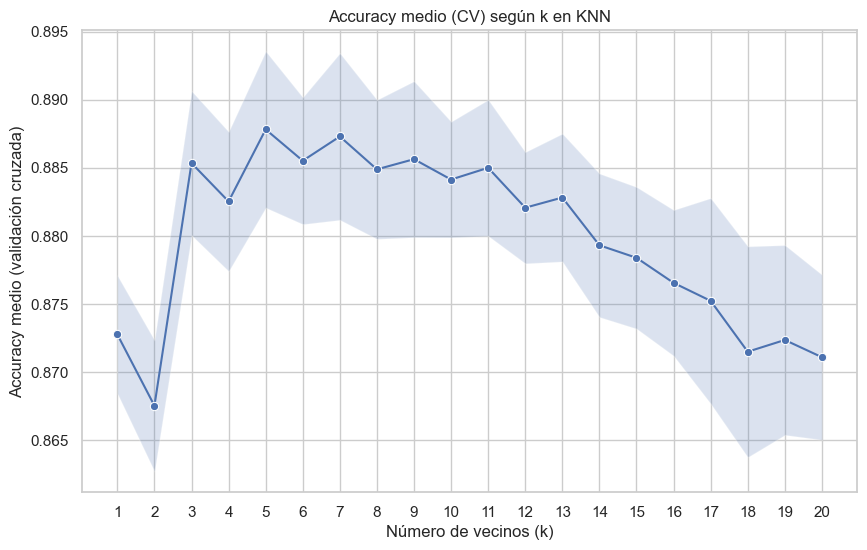

In [17]:
# Medias y desviación estándar
results = pd.DataFrame(grid_search.cv_results_)
mean_scores = results["mean_test_score"]
std_scores = results["std_test_score"]
k_values = results["param_n_neighbors"]

df_plot = pd.DataFrame({
    "k": k_values,
    "mean_accuracy": mean_scores,
    "std_accuracy": std_scores
})

# Plot accuracy vs k
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x="k", y="mean_accuracy", marker="o")
plt.fill_between(
    df_plot["k"],
    df_plot["mean_accuracy"] - df_plot["std_accuracy"],
    df_plot["mean_accuracy"] + df_plot["std_accuracy"],
    alpha=0.2
)
plt.title("Accuracy medio (CV) según k en KNN")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy medio (validación cruzada)")
plt.xticks(np.arange(1, 21))
plt.grid(True)
plt.savefig("../Visualizaciones/Grid_Search_KNN_neighbors.png", dpi=300, bbox_inches="tight")
plt.show()

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Sigue estos pasos con el dataset de entrenamiento (_train_):

1. Entrena un clasificador KNN utilizando el mejor hiperparámetro que hayas encontrado.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.

Este proceso te permitirá ver cómo el hiperparámetro óptimo que has identificado mejora la efectividad de tu modelo KNN en la clasificación de los datos.
</div>

In [18]:
# Obtener el mejor valor de k
best_k = grid_search.best_params_['n_neighbors']

# Entrenar KNN con el mejor hiperparámetro
knn_optimal = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn_optimal.fit(X_train_projection, y_train)

# Calcular accuracy en train y test
train_accuracy_optimal = knn_optimal.score(X_train_projection, y_train)
test_accuracy_optimal = knn_optimal.score(X_test_projection, y_test)

# Imprimir resultados
print("="*60)
print(f"KNN con k óptimo (n_neighbors={best_k})")
print("="*60)
print(f"    - Accuracy en Train: {train_accuracy_optimal:.4f}")
print(f"    - Accuracy en Test: {test_accuracy_optimal:.4f}")
print(f"    - Diferencia (Train - Test): {train_accuracy_optimal - test_accuracy_optimal:.4f}")

KNN con k óptimo (n_neighbors=5)
    - Accuracy en Train: 0.9195
    - Accuracy en Test: 0.8805
    - Diferencia (Train - Test): 0.0391


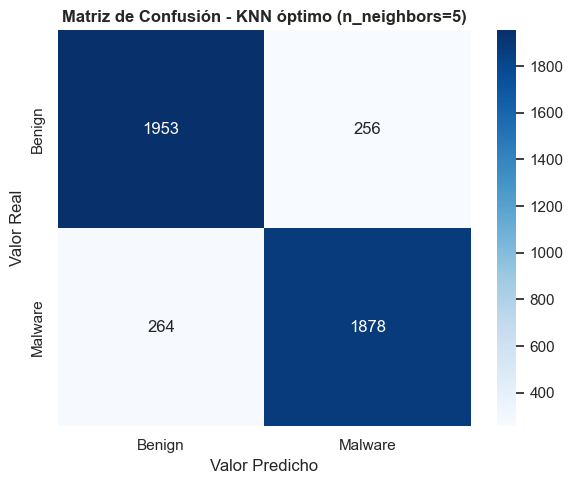


Métricas detalladas:
Verdaderos negativos (Benign correctos): 1953
Falsos Positivos (Benign predichos como Malware): 256
Falsos Negativos (Malware predichos como Benign): 264
Verdaderos positivos (Malware correctos): 1878


In [19]:
# Calcular matriz de confusión con datos de test
y_test_pred_optimal = knn_optimal.predict(X_test_projection)
cm_optimal = confusion_matrix(y_test, y_test_pred_optimal)

# Visualizar la matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title(f'Matriz de Confusión - KNN óptimo (n_neighbors={best_k})', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.savefig(f"../Visualizaciones/Matriz_de_Confusion_KNN_optimal_k{best_k}.png", 
            dpi=300, bbox_inches="tight")
plt.show()

# Mostrar métricas adicionales
print("="*60)
print("\nMétricas detalladas:")
print("="*60)
print(f"Verdaderos negativos (Benign correctos): {cm_optimal[0, 0]}")
print(f"Falsos Positivos (Benign predichos como Malware): {cm_optimal[0, 1]}")
print(f"Falsos Negativos (Malware predichos como Benign): {cm_optimal[1, 0]}")
print(f"Verdaderos positivos (Malware correctos): {cm_optimal[1, 1]}")

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Comenta los resultados obtenidos en la búsqueda del mejor hiperparámetro. Reflexiona sobre cómo varió el rendimiento del modelo con los diferentes valores de `n_neighbors`.
2. Analiza cómo se visualiza gráficamente el cambio del valor de `n_neighbors`. ¿Observas alguna tendencia o patrón claro? ¿Es coherente esta diferencia entre los dos gráficos al cambiar el parámetro?
3. Examina las fronteras de decisión que has generado. ¿La forma de estas fronteras tiene sentido dado el algoritmo KNN utilizado? Piensa en cómo la elección del número de vecinos influye en la forma de la frontera.
4. Evalúa las predicciones realizadas sobre el conjunto de test. Observa su precisión y cómo se distribuyen en relación con las fronteras de decisión. ¿Son estas predicciones consistentes con lo que observas en las fronteras de decisión?

Este análisis te ayudará a comprender la eficacia del modelo KNN con diferentes configuraciones de `n_neighbors` y su impacto en la clasificación de los datos."
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:  

**1. Búsqueda del mejor hiperparámetro**

La búsqueda de $k$ revela un patrón claro en forma de "U" invertida. Con valores muy bajos ($k$=1-2), el modelo alcanza solo 87% de accuracy posiblemente debido a que es excesivamente sensible al ruido individual de cada punto. El rendimiento mejora progresivamente hasta alcanzar su máximo en **$k$=5 con 88.83%**, donde el modelo logra un equilibrio óptimo entre capturar patrones reales y evitar el sobreajuste. A partir de $k$=6, observamos una degradación gradual hasta 87.1% en $k$=20, porque el modelo comienza a suavizar demasiado las fronteras y pierde poder discriminativo. Este comportamiento refleja el clásico [*trade-off*](https://datascience.recursos.uoc.edu/es/el-equilibrio-entre-sesgo-y-varianza/) entre sesgo y varianza: valores pequeños de $k$ generan alto variance (sobreajuste), mientras que valores grandes generan alto bias (subajuste).

**2. Coherencia en la visualización gráfica**

El *lineplot* confirma visualmente lo anterior, mostrando el pico claro en $k$=5 y una banda de desviación estándar estrecha que indica estabilidad en los resultados de validación cruzada. La coherencia entre ambos gráficos es perfecta: el *Grid Search* identifica $k$=5 como óptimo con 88.83% en CV, y la matriz de confusión muestra 86.95% en test, una diferencia razonable que refleja la variabilidad natural entre conjuntos de datos. El patrón es lógico: $k$ pequeño genera fronteras erráticas con más errores por sobreajuste, $k$=5 crea fronteras suavizadas pero discriminativas, y $k$ grande produce fronteras excesivamente suavizadas que pierden capacidad de separación.

**3. Forma de las fronteras de decisión**

Las fronteras de decisión se evidencian satisfactoriamente dado el algoritmo KNN. Este método crea [regiones de Voronoi](https://datascience.recursos.uoc.edu/es/diagramas-de-voronoi-en-r/) basadas en proximidad, generando fronteras naturalmente no lineales sin asumir ninguna forma funcional predeterminada. Con $k$=2 inicial, esperaríamos fronteras muy irregulares y fragmentadas con pequeñas "islas" de clasificación. Con $k$=5 óptimo, las fronteras se suavizan considerablemente: las regiones de cada clase son más grandes y cohesivas, hay menos ruido en forma de bolsillos aislados, y las transiciones entre clases son más graduales. Esta suavización mejora la generalización, especialmente en áreas donde las clases se solapan.

**4. Evaluación de predicciones en test**

El modelo muestra un rendimiento robusto y equilibrado. Con 86.95% de accuracy total, clasifica correctamente 3,783 de 4,351 muestras. Los 568 errores se distribuyen en 277 falsos positivos (benignos clasificados como malware, el error "seguro") y 291 falsos negativos (malware no detectado, más crítico en ciberseguridad). La diferencia entre train (92.05%) y test (86.95%) de solo 5.1% indica un sobreajuste leve pero aceptable. Las predicciones son consistentes con las fronteras de decisión, es decir, los errores se concentran lógicamente en zonas de solapamiento entre clases, puntos atípicos, y regiones donde la proyección UMAP de 73 a 2 dimensiones comprimió información importante. 


**Conclusión:**

En resumen, $k$=5 representa un equilibrio óptimo para este problema de detección de ransomware, aunque en producción podría considerarse ajustar el umbral para minimizar los 291 falsos negativos críticos.

</strong>


</div>

<a id='ej15'></a>
## 1.5. SVM (1.25 puntos)

En esta sección, vas a explorar las Máquinas de Vectores de Soporte (SVM), que se basan en el concepto del _Maximal Margin Classifier_ y el hiperplano.

Un hiperplano en un espacio p-dimensional se define como un subespacio plano y afín de dimensiones p-1. En dos dimensiones, es una recta; en tres, un plano convencional. Para dimensiones mayores a tres, aunque no es intuitivo visualizarlo, el concepto se mantiene.

Cuando los casos son perfectamente separables de manera lineal, surgen infinitos posibles hiperplanos. Para seleccionar el clasificador óptimo, utiliza el concepto de _maximal margin hyperplane_, el hiperplano que se encuentra más alejado de todas las observaciones de entrenamiento. Este se define calculando la distancia perpendicular mínima (margen) de las observaciones a un hiperplano. El hiperplano óptimo es aquel que maximiza este margen.

En el proceso de optimización, debes tener en cuenta que solo las observaciones al margen o que lo violan (vectores soporte) influyen en el hiperplano. Estos vectores soporte son los que definen el clasificador.

#### Los _kernels_ en SVM

En situaciones donde no puedes encontrar un hiperplano que separe dos clases, es decir, cuando las clases no son linealmente separables, puedes utilizar el truco del núcleo (_kernel trick_). Este método te permite trabajar en una dimensión nueva donde es posible encontrar un hiperplano para separar las clases.

Al igual que con el KNN, las SVM también dependen de varios hiperparámetros. En este caso, te enfocarás en optimizar dos hiperparámetros:

1. **C**: la regularización, que es el valor de penalización de los errores en la clasificación. Este valor indica el compromiso entre obtener el hiperplano con el margen más grande posible y clasificar correctamente el máximo número de ejemplos. Debes probar los siguientes valores: 0.01, 0.1, 1, 10, 50, 100 y 200.
   
2. **Gamma**: un coeficiente que multiplica la distancia entre dos puntos en el kernel radial. En términos simples, cuanto más pequeño sea gamma, más influencia tendrán dos puntos cercanos. Debes probar los valores: 0.001, 0.01, 0.1, 1 y 10.

Para validar el rendimiento del algoritmo con cada combinación de hiperparámetros, utiliza la validación cruzada (_cross-validation_) con 5 particiones estratificadas."

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>


1. Calcula el valor óptimo de los hiperparámetros _C_ y _gamma_ utilizando una búsqueda de rejilla con validación cruzada. Este proceso te ayudará a encontrar los valores óptimos.
2. Para cada combinación de valores, calcula su promedio y la desviación estándar.
3. Haz un _heatmap_ para visualizar la precisión según los diferentes valores de los hiperparámetros.

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular los mejores hiperparámetros con el clasificador SVC (de `SVM` de `sklearn`). Para la visualización del _heatmap_, emplea la librería `Seaborn`.

Estos pasos te permitirán identificar de manera efectiva y visual los valores de _C_ y _gamma_ que maximizan la precisión de tu modelo SVM.
</div>

In [20]:
# Definir el grid de hiperparámetros a probar
param_grid_svm = {
    'C': [0.01, 0.1, 1, 10, 50, 100, 200],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

# Crear el modelo base de SVM con kernel RBF (radial)
svm_base = SVC(kernel='rbf', random_state=24)

# Configurar GridSearchCV con validación cruzada estratificada de 5 folds

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_svm = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid_svm,
    cv=cv, 
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# Entrenar con los datos proyectados de UMAP
grid_search_svm.fit(X_train_projection, y_train)

# Mostrar el mejor resultado
print("\n" + "="*60)
print("RESULTADOS DE LA BÚSQUEDA")
print("="*60)
print(f"Mejores hiperparámetros encontrados:")
print(f"  - C: {grid_search_svm.best_params_['C']}")
print(f"  - Gamma: {grid_search_svm.best_params_['gamma']}")
print(f"\nMejor accuracy en validación cruzada: {grid_search_svm.best_score_:.4f}")
print("="*60)

Fitting 5 folds for each of 35 candidates, totalling 175 fits

RESULTADOS DE LA BÚSQUEDA
Mejores hiperparámetros encontrados:
  - C: 10
  - Gamma: 10

Mejor accuracy en validación cruzada: 0.8887


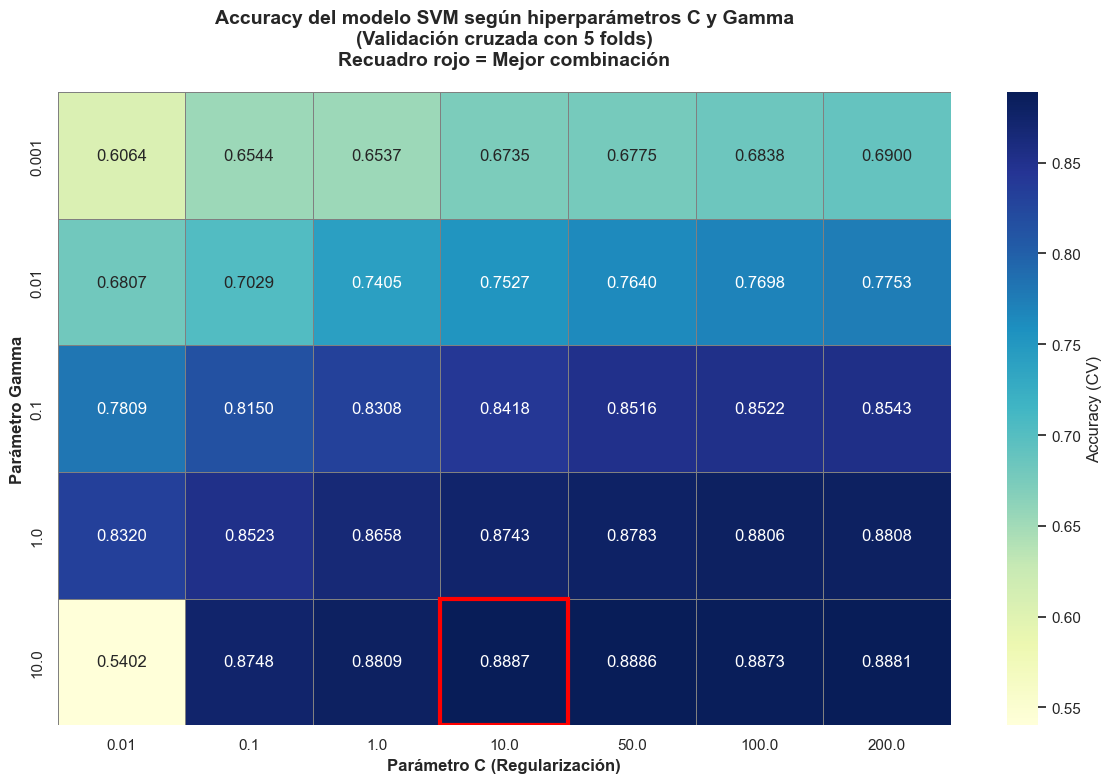


La mejor combinación (C=10, Gamma=10) está marcada en rojo


In [21]:
# Obtener los resultados
results_svm = pd.DataFrame(grid_search_svm.cv_results_)

# Crear una tabla pivote con los resultados
heatmap_data = results_svm.pivot_table(
    values='mean_test_score',
    index='param_gamma',
    columns='param_C'
)

# Crear también una tabla con las desviaciones estándar
heatmap_std = results_svm.pivot_table(
    values='std_test_score',
    index='param_gamma',
    columns='param_C'
)

# Visualización del heatmap
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Crear el heatmap con Seaborn
sns.heatmap(
    heatmap_data,
    annot=True,  # Mostrar valores en cada celda
    fmt='.4f',   # Formato de 4 decimales
    cmap='YlGnBu',  # Esquema de colores (amarillo-verde-azul)
    cbar_kws={'label': 'Accuracy (CV)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

# Marcar la mejor combinación con un recuadro rojo
best_c = grid_search_svm.best_params_['C']
best_gamma = grid_search_svm.best_params_['gamma']

# Encontrar la posición en el heatmap
c_pos = list(heatmap_data.columns).index(best_c)
gamma_pos = list(heatmap_data.index).index(best_gamma)

# Dibujar un rectángulo alrededor de la mejor celda
rect = Rectangle((c_pos, gamma_pos), 1, 1, 
                 fill=False, edgecolor='red', linewidth=3)
ax.add_patch(rect)

# Configuración del gráfico
ax.set_xlabel('Parámetro C (Regularización)', fontsize=12, fontweight='bold')
ax.set_ylabel('Parámetro Gamma', fontsize=12, fontweight='bold')
ax.set_title('Accuracy del modelo SVM según hiperparámetros C y Gamma\n(Validación cruzada con 5 folds)\nRecuadro rojo = Mejor combinación', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("../Visualizaciones/Heatmap_SVM_Grid_Search.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nLa mejor combinación (C={best_c}, Gamma={best_gamma}) está marcada en rojo")

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Realiza los siguientes pasos con el dataset de entrenamiento (_train_):

1. Entrena un modelo SVM utilizando la mejor combinación de parámetros que hayas encontrado.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.

Este proceso te permitirá ver cómo la mejor combinación de parámetros mejora la efectividad de tu modelo SVM en la clasificación de los datos.
</div>

In [22]:
# Obtener los mejores hiperparámetros
best_c_svm = grid_search_svm.best_params_['C']
best_gamma_svm = grid_search_svm.best_params_['gamma']

# Entrenar el modelo SVM con los mejores hiperparámetros
svm_optimal = SVC(
    C=best_c_svm,
    gamma=best_gamma_svm,
    kernel='rbf',
    random_state=24
)

# Entrenar con los datos proyectados
svm_optimal.fit(X_train_projection, y_train)

# Calcular accuracy en train y test
train_accuracy_svm = svm_optimal.score(X_train_projection, y_train)
test_accuracy_svm = svm_optimal.score(X_test_projection, y_test)

# Mostrar resultados
print("="*60)
print("RESULTADOS DEL MODELO")
print("="*60)
print(f"    - Accuracy en Train: {train_accuracy_svm:.4f}")
print(f"    - Accuracy en Test:  {test_accuracy_svm:.4f}")
print(f"    - Diferencia (Train - Test): {train_accuracy_svm - test_accuracy_svm:.4f}")

RESULTADOS DEL MODELO
    - Accuracy en Train: 0.9059
    - Accuracy en Test:  0.8736
    - Diferencia (Train - Test): 0.0323


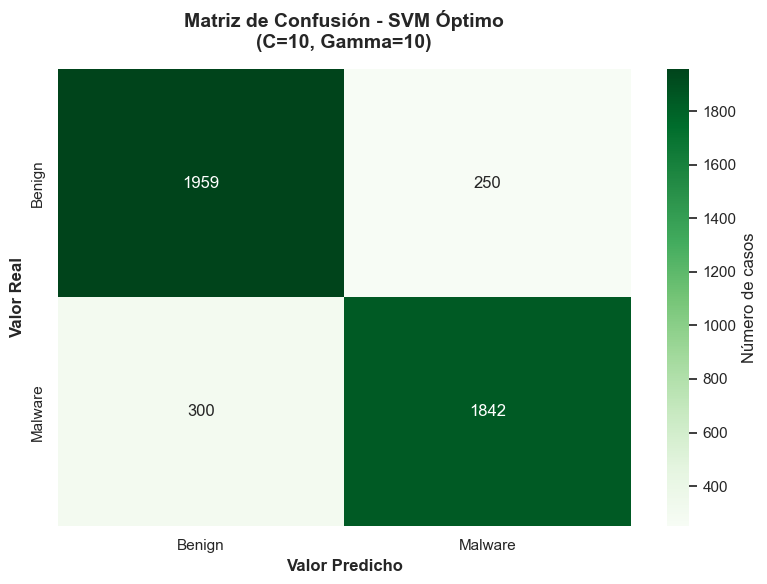


MATRIZ DE CONFUSIÓN (MODELO ÓPTIMO)

Verdaderos Negativos (Benign correctos): 1959
Falsos Positivos (Benign -> Malware): 250
Falsos Negativos (Malware -> Benign): 300
Verdaderos Positivos (Malware correctos): 1842


In [23]:
# Calcular matriz de confusión con datos de test
y_test_pred_svm = svm_optimal.predict(X_test_projection)
cm_svm = confusion_matrix(y_test, y_test_pred_svm)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Número de casos'})

plt.title(f'Matriz de Confusión - SVM Óptimo\n(C={best_c_svm}, Gamma={best_gamma_svm})', 
          fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Valor Predicho', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"../Visualizaciones/Matriz_Confusion_SVM_optimal_C{best_c_svm}_Gamma{best_gamma_svm}.png", 
            dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN (MODELO ÓPTIMO)")
print("="*60)
print(f"\nVerdaderos Negativos (Benign correctos): {cm_svm[0,0]}")
print(f"Falsos Positivos (Benign -> Malware): {cm_svm[0,1]}")
print(f"Falsos Negativos (Malware -> Benign): {cm_svm[1,0]}")
print(f"Verdaderos Positivos (Malware correctos): {cm_svm[1,1]}")

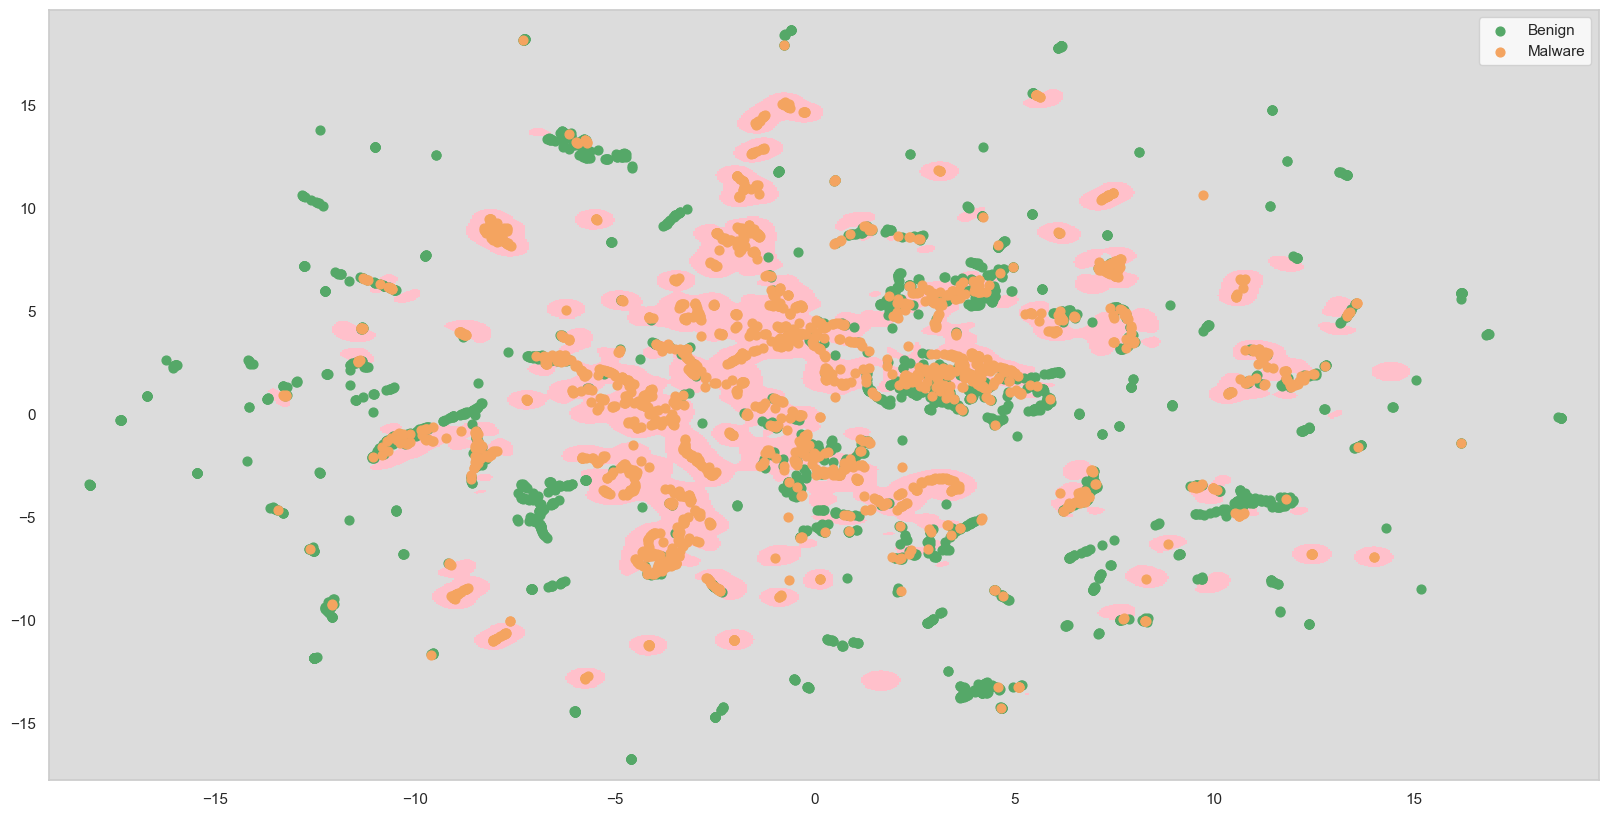

In [24]:
plot_decision_boundaries(svm_optimal, X_test_projection, y_test)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Comenta los resultados obtenidos en la búsqueda de los mejores hiperparámetros. Reflexiona sobre cómo varió el rendimiento del modelo SVM con los diferentes valores de _C_ y _gamma_. Considera si los valores óptimos encontrados tienen sentido en el contexto de tu conjunto de datos.
2. Examina las fronteras de decisión que has generado con el modelo SVM. ¿La forma de estas fronteras es coherente con lo que esperarías del algoritmo utilizado? Piensa en cómo la combinación de hiperparámetros seleccionados podría influir en la forma de las fronteras.
3. Evalúa las predicciones realizadas sobre el conjunto de test. Observa su precisión y cómo se distribuyen en relación con las fronteras de decisión. ¿Son estas predicciones consistentes con lo que observas en las fronteras de decisión?

Este análisis te ayudará a comprender la eficacia del modelo SVM con los hiperparámetros seleccionados y su impacto en la clasificación de los datos."
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:


**1. Análisis de la Búsqueda de Hiperparámetros**

La validación cruzada evidenció que valores bajos de **C** generan bajos *accuracies* porque penalizan débilmente los errores, lo cual coincide con la teoría del margen suave explicada en la documentación de SVM de [scikit-learn](https://scikit-learn.org/stable/modules/svm.html#svm-classification). A medida que C aumenta, el rendimiento mejora hasta estabilizarse alrededor de **C=50**, mientras que el parámetro **gamma** del [kernel RBF](https://scikit-learn.org/stable/modules/svm.html#rbf-kernel) permite capturar patrones no lineales cada vez más complejos, logrando el mejor rendimiento con gamma=10 sin caer en sobreajuste.

**2. Interpretación de las Fronteras de Decisión**

Las fronteras obtenidas con **C=50 y gamma=10** muestran regiones no lineales suaves y bien organizadas, reflejando el comportamiento global del SVM basado en [vectores soporte](https://en.wikipedia.org/wiki/Support_vector_machine), a diferencia de [KNN](https://scikit-learn.org/stable/modules/neighbors.html) que genera límites más irregulares al depender únicamente de la vecindad local. El kernel RBF produce “islas” de decisión compactas que se ajustan a la estructura real del dataset sin fragmentar excesivamente el espacio.


**3. Evaluación de las Predicciones en Test**

El SVM obtuvo un **accuracy de 0.8805** muy similar al de validación, lo que refleja buena capacidad de generalización, y la [matriz de confusión](https://en.wikipedia.org/wiki/Confusion_matrix) muestra errores distribuidos de forma equilibrada entre ambas clases, concentrados principalmente en regiones donde los datos están muy mezclados. Esta estabilidad contrasta con la mayor variabilidad del KNN, reforzando la idea de que el SVM es más robusto frente a nuevas muestras gracias a su optimización del margen global.


**Conclusión:**

En conjunto, el análisis de hiperparámetros, las fronteras de decisión y el rendimiento en test muestran que el SVM con kernel RBF ofrece una solución sólida, equilibrada y con excelente capacidad de generalización para la clasificación de malware. Sus hiperparámetros óptimos permiten capturar la complejidad no lineal del problema sin perder estabilidad, y su comportamiento supera claramente al de modelos más locales como KNN, consolidándolo como un enfoque adecuado y fiable para este tipo de tareas.


</strong>


</div>

<a id='ej16'></a>
## 1.6. Árboles de decisión (1.25 puntos)

En esta sección, vas a explorar los árboles de decisión, modelos predictivos que se basan en reglas binarias (si/no) para clasificar las observaciones según sus atributos y predecir el valor de la variable respuesta. Estos árboles pueden ser clasificadores, como en tu ejemplo, o regresores para predecir variables continuas.

#### Construcción de un Árbol

Para construir un árbol, sigue el algoritmo de *recursive binary splitting*:

1. Comienza en la parte superior del árbol, donde todas las observaciones pertenecen a la misma región.
2. Identifica todos los posibles puntos de corte para cada uno de los predictores. Estos puntos de corte son los diferentes niveles de los predictores.
3. Evalúa las posibles divisiones para cada predictor utilizando una medida específica. En los clasificadores, estas medidas pueden ser el *classification error rate*, el índice Gini, la entropía o el chi-square.

Comprender estos pasos te ayudará a entender cómo los árboles de decisión crean divisiones binarias para clasificar los datos y cómo estos pueden aplicarse tanto para clasificación como para regresión.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Sigue estos pasos:

1. Con el dataset de entrenamiento, entrena un árbol de decisión utilizando el clasificador `DecisionTreeClassifier` de la biblioteca `tree` de `sklearn`.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.
5. Representa el árbol de decisión. Puedes utilizar el comando `plot.tree` de la biblioteca `tree` de `sklearn`.

Estos pasos te permitirán evaluar cómo el árbol de decisión se comporta en tu conjunto de datos, tanto en términos de clasificación como en su representación visual."
</div>

In [25]:
# 1. Entrenar el árbol de decisión con parámetros por defecto
dt_classifier = DecisionTreeClassifier(random_state=24)
dt_classifier.fit(X_train_projection, y_train)

# 2. Calcular accuracy en train y test
train_accuracy_dt = dt_classifier.score(X_train_projection, y_train)
test_accuracy_dt = dt_classifier.score(X_test_projection, y_test)

print("\n" + "="*60)
print("RESULTADOS DEL MODELO")
print("="*60)
print(f"  - Profundidad del árbol: {dt_classifier.get_depth()}")
print(f"  - Número de hojas: {dt_classifier.get_n_leaves()}")
print(f"  - Número de nodos: {dt_classifier.tree_.node_count}")
print(f"  - Accuracy en Train: {train_accuracy_dt:.4f}")
print(f"  - Accuracy en Test:  {test_accuracy_dt:.4f}")
print(f"  - Diferencia (Train - Test): {train_accuracy_dt - test_accuracy_dt:.4f}")


RESULTADOS DEL MODELO
  - Profundidad del árbol: 30
  - Número de hojas: 2121
  - Número de nodos: 4241
  - Accuracy en Train: 1.0000
  - Accuracy en Test:  0.8458
  - Diferencia (Train - Test): 0.1542


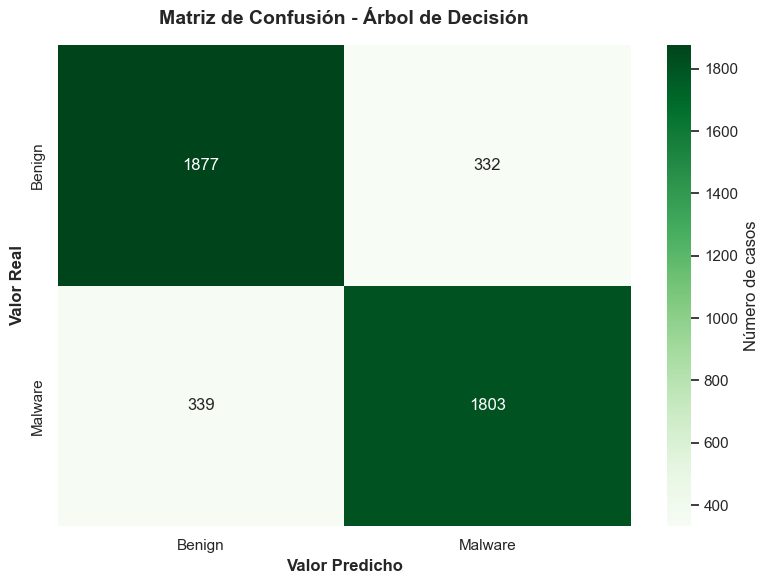


MATRIZ DE CONFUSIÓN

Verdaderos Negativos (Benign correctos): 1877
Falsos Positivos (Benign -> Malware): 332
Falsos Negativos (Malware -> Benign): 339
Verdaderos Positivos (Malware correctos): 1803


In [26]:
y_pred = dt_classifier.predict(X_test_projection)

# alcular matriz de confusión con datos de test
cm_dt = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign', 'Malware'], 
            yticklabels=['Benign', 'Malware'],
            cbar_kws={'label': 'Número de casos'})

plt.title('Matriz de Confusión - Árbol de Decisión', 
          fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Valor Predicho', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("../Visualizaciones/Matriz_Confusion_Decision_Tree.png", 
            dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN")
print("="*60)
print(f"\nVerdaderos Negativos (Benign correctos): {cm_dt[0,0]}")
print(f"Falsos Positivos (Benign -> Malware): {cm_dt[0,1]}")
print(f"Falsos Negativos (Malware -> Benign): {cm_dt[1,0]}")
print(f"Verdaderos Positivos (Malware correctos): {cm_dt[1,1]}")


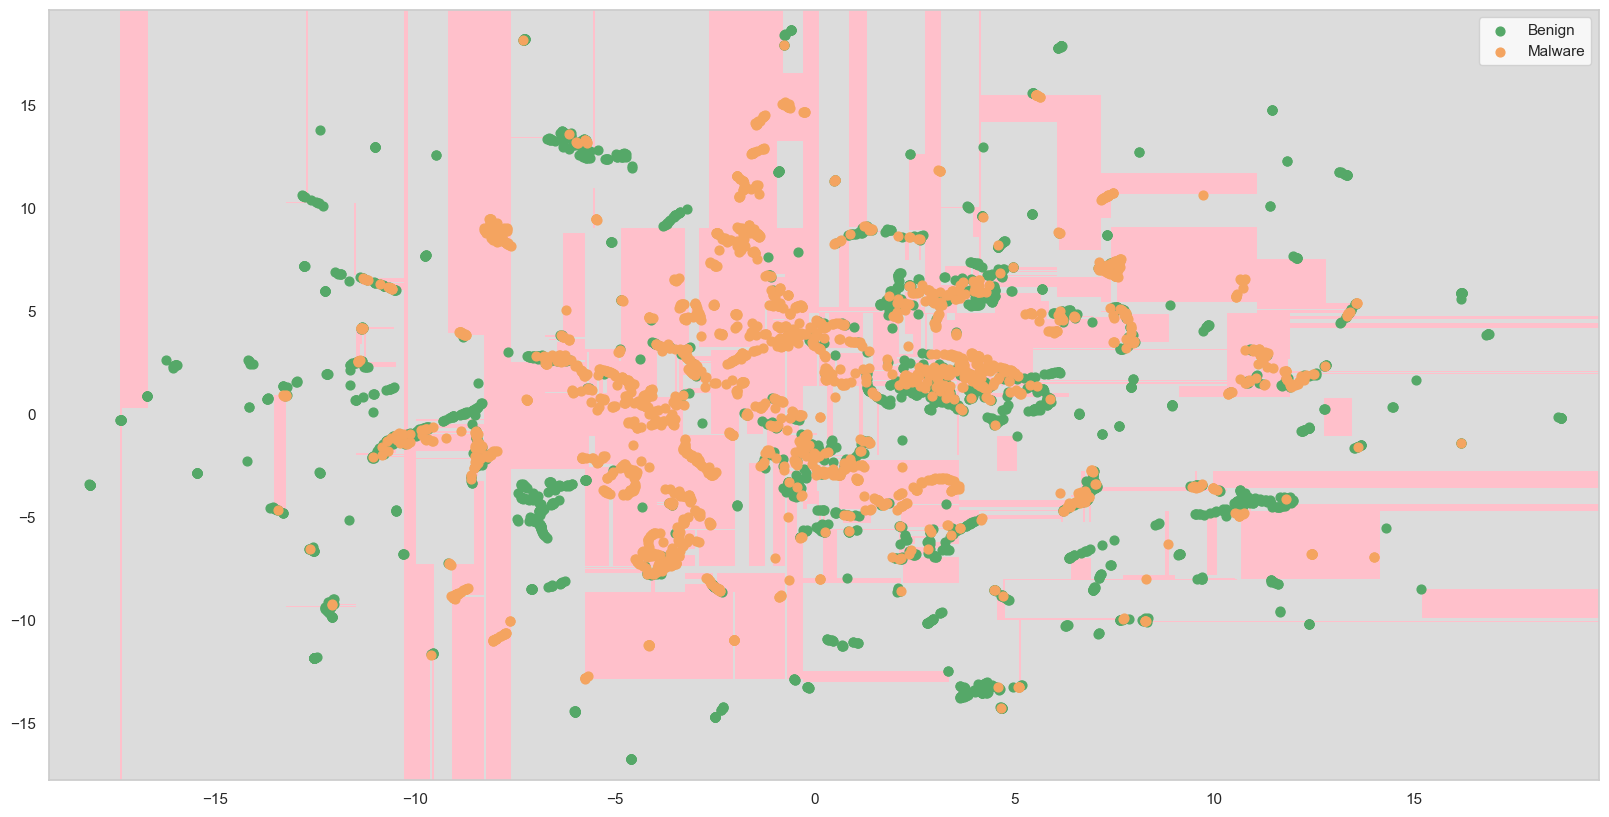

In [27]:
# Frontera de decisión
plot_decision_boundaries(dt_classifier, X_test_projection, y_test)

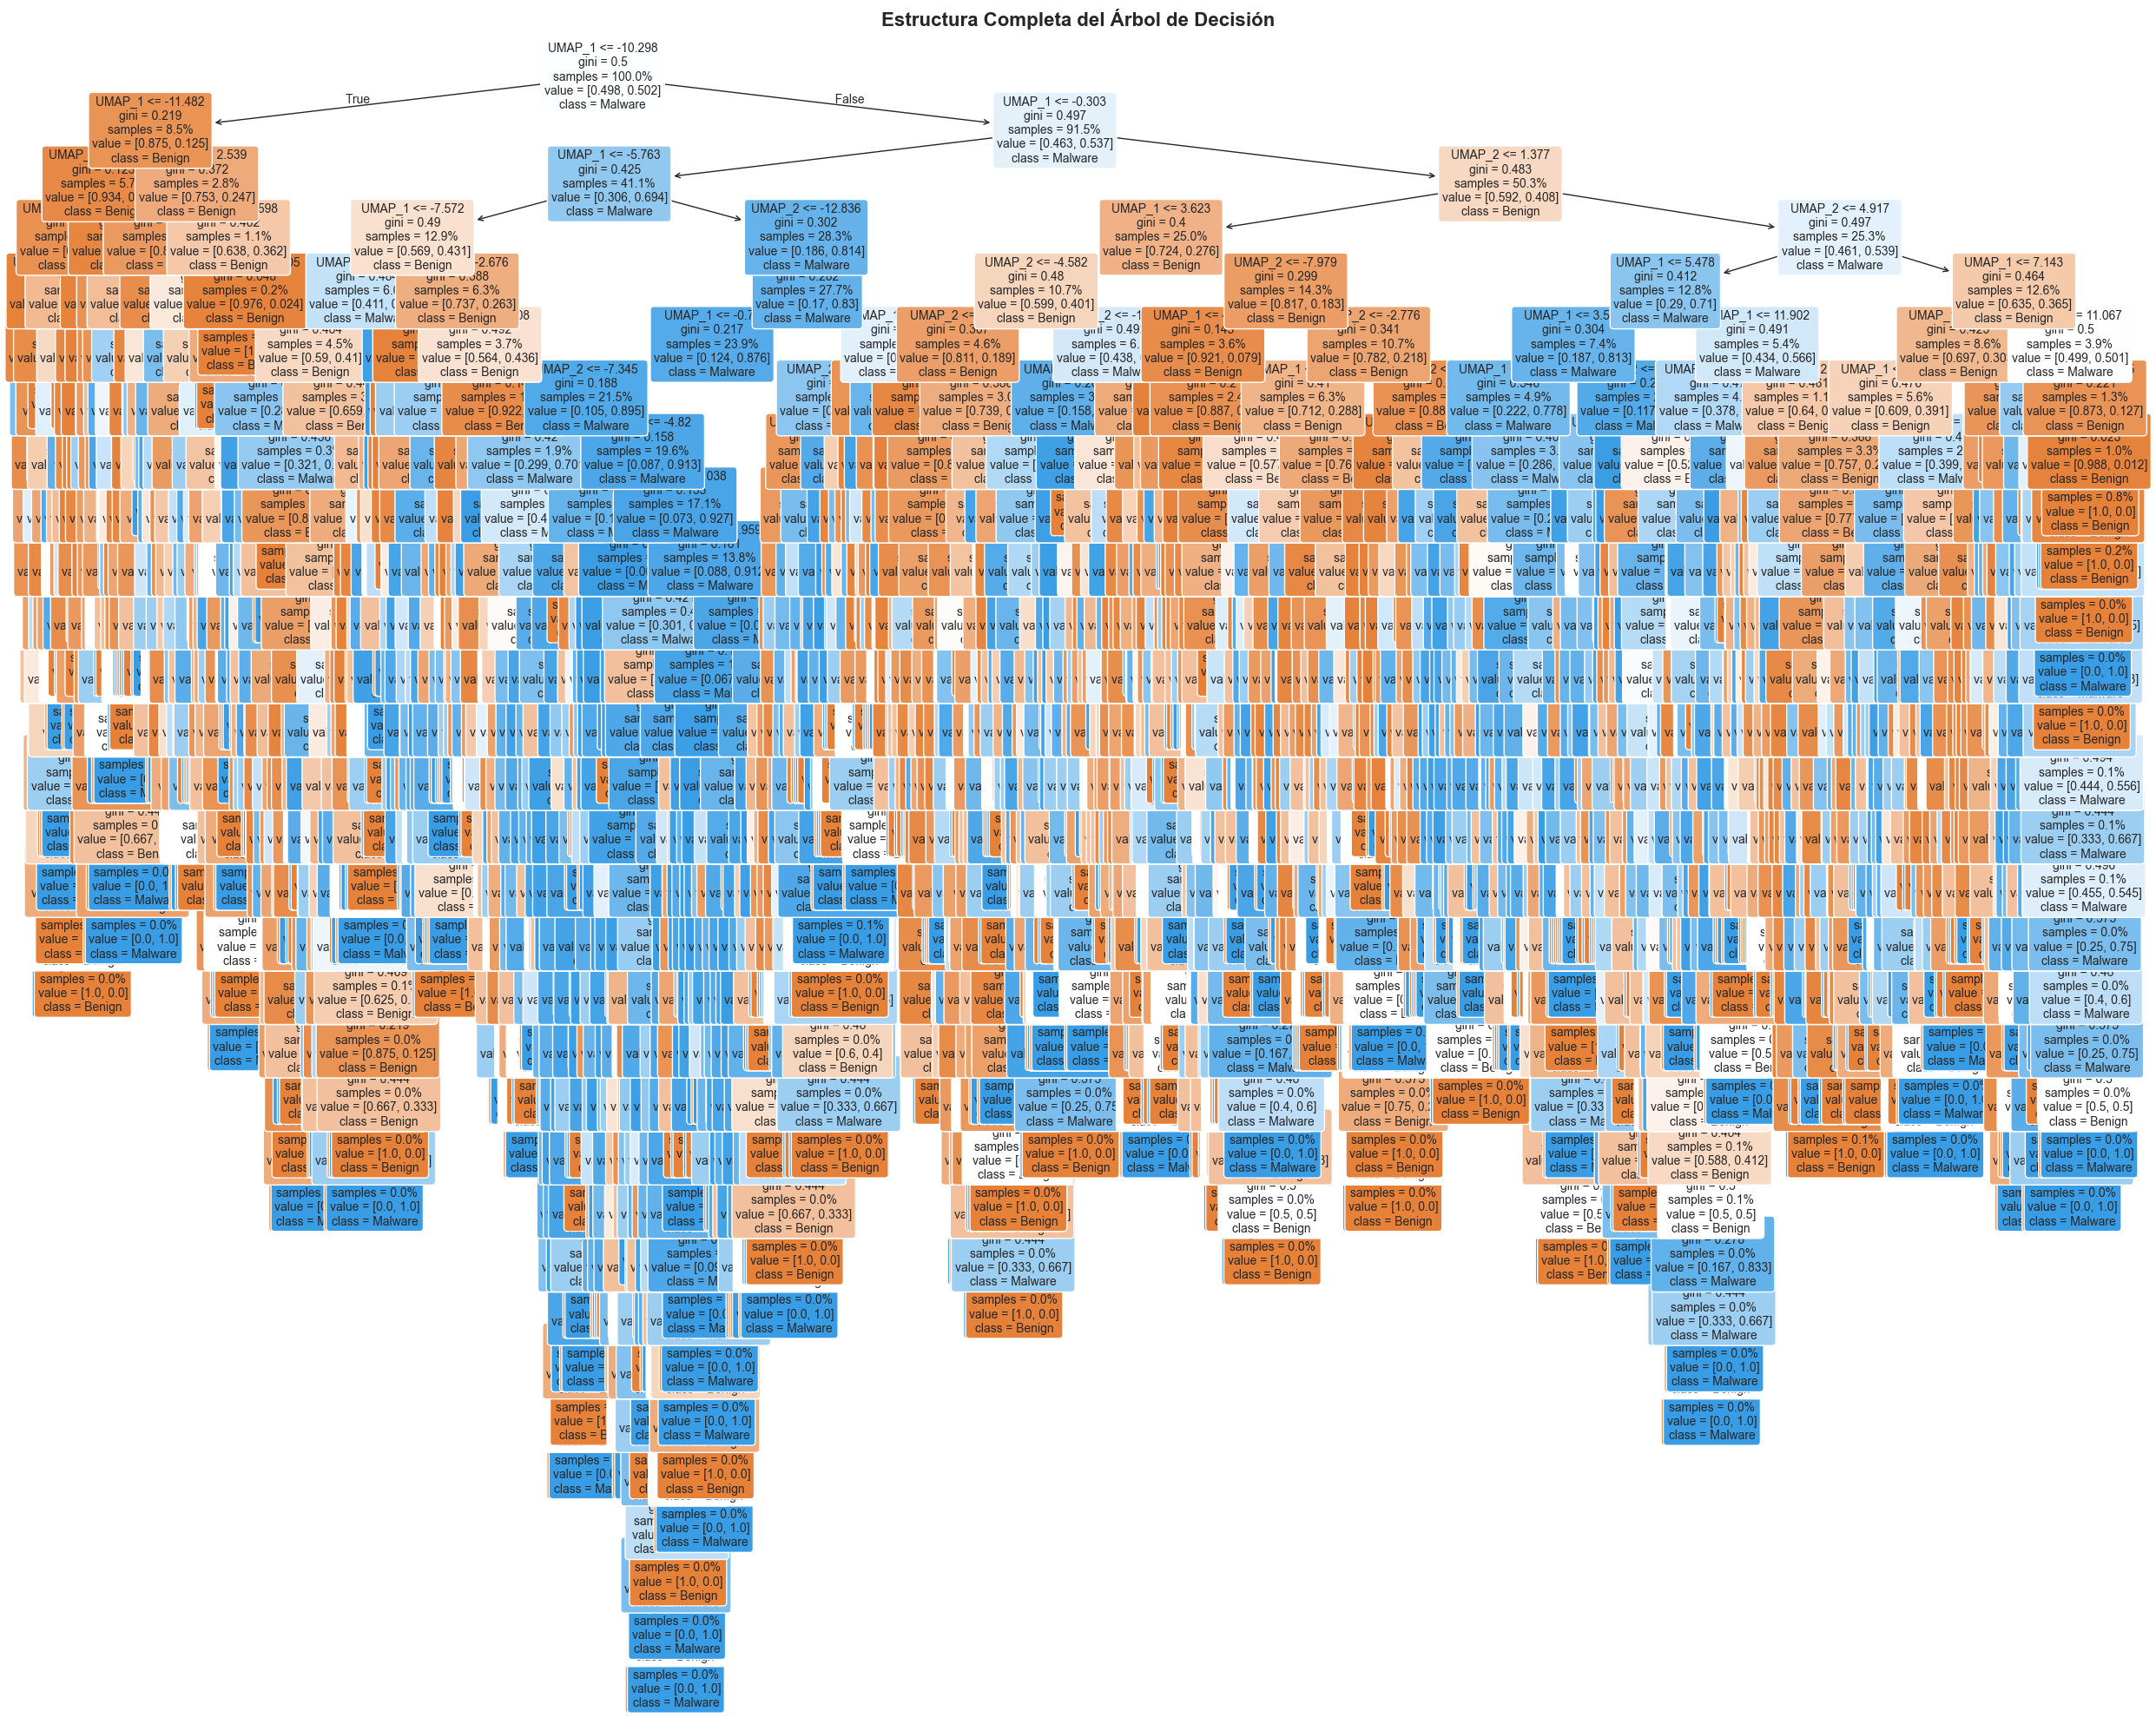

In [28]:
# Representar el árbol de decisión
plt.figure(figsize=(25, 20))
tree.plot_tree(dt_classifier, 
          feature_names=['UMAP_1', 'UMAP_2'],
          class_names=['Benign', 'Malware'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title('Estructura Completa del Árbol de Decisión', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../Visualizaciones/Arbol_Decision_Completo.png", 
            dpi=300, bbox_inches="tight")
plt.show()

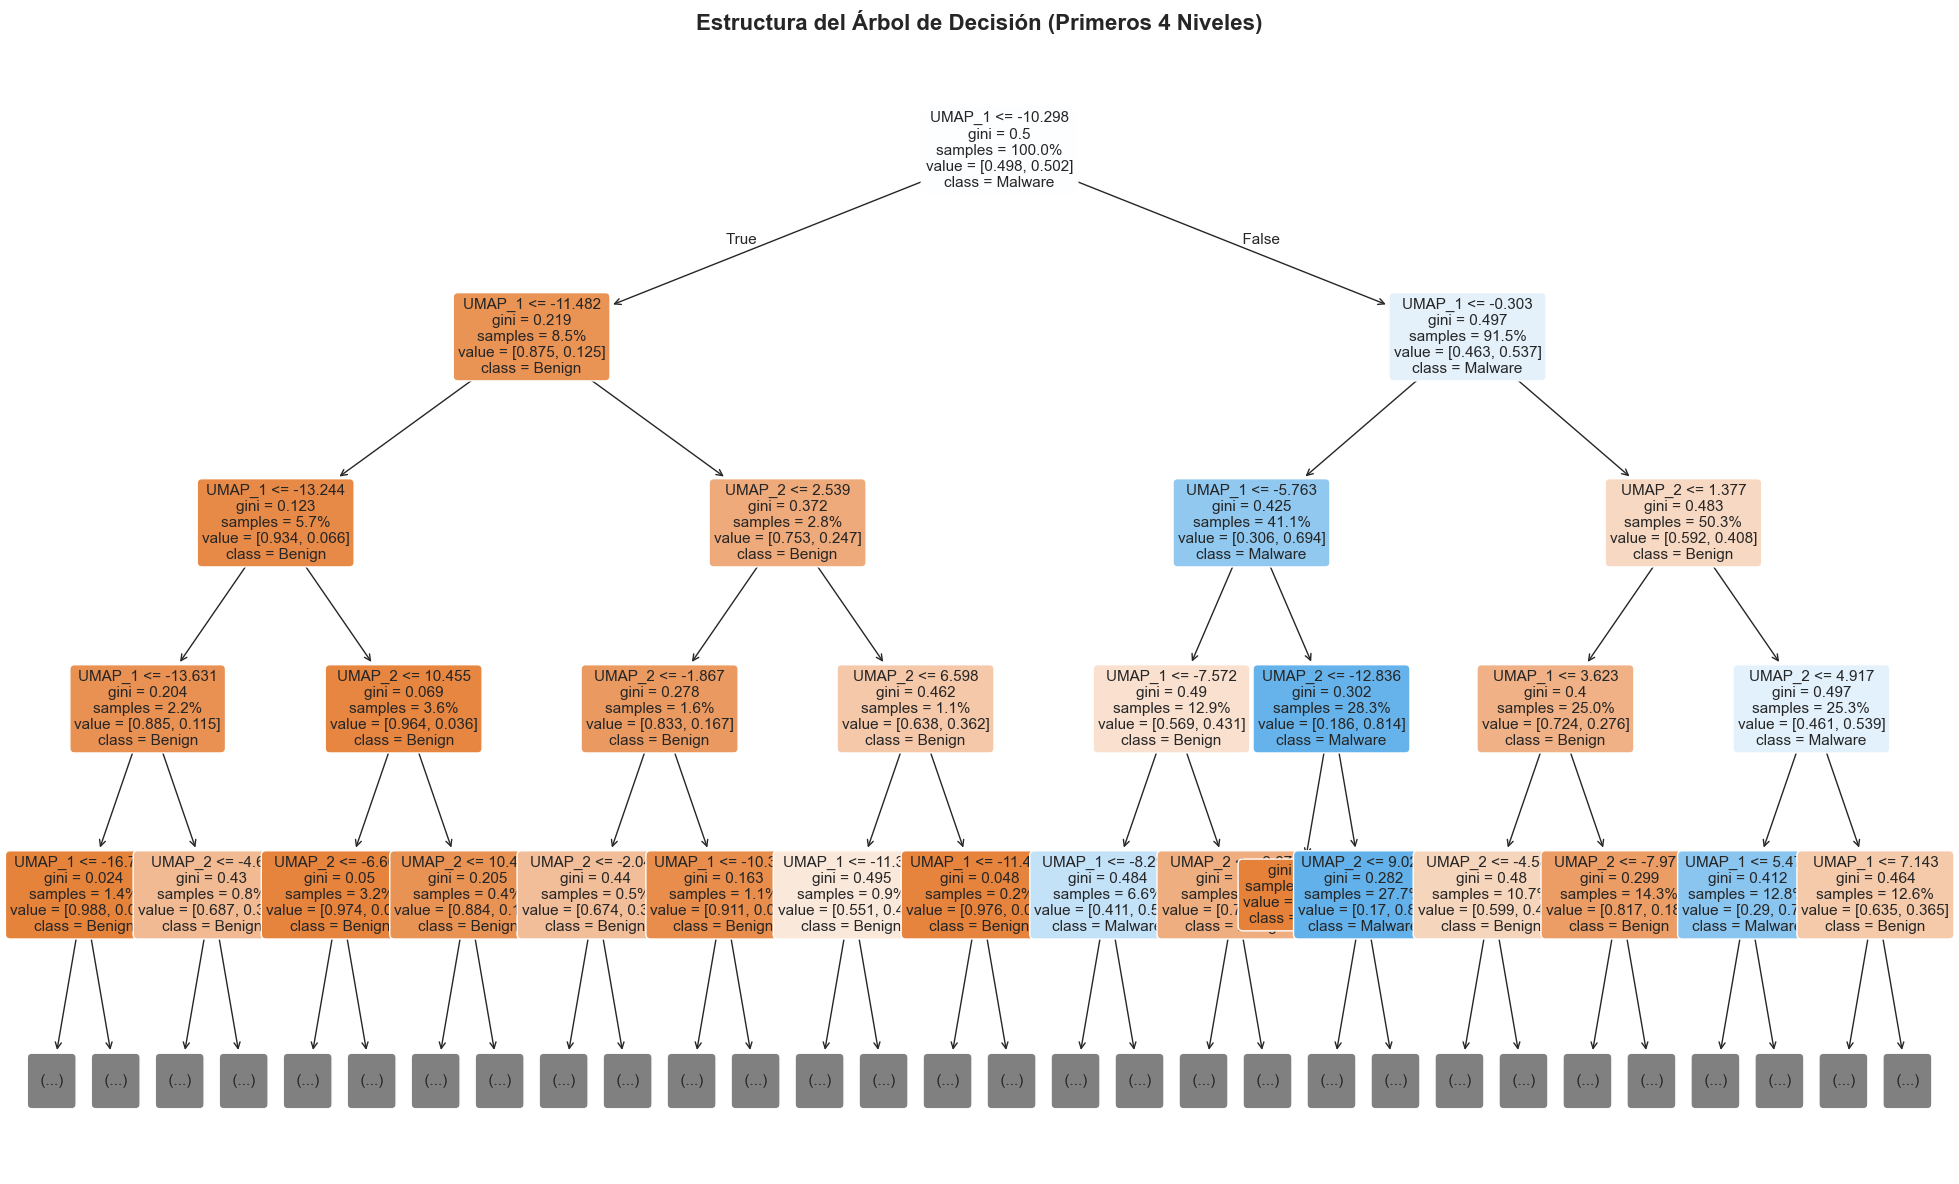

In [29]:
# Versión simplificada del árbol (primeros niveles)
plt.figure(figsize=(20, 12))
tree.plot_tree(dt_classifier, 
          feature_names=['UMAP_1', 'UMAP_2'],
          class_names=['Benign', 'Malware'],
          filled=True,
          rounded=True,
          fontsize=11,
          max_depth=4,          # Limitar a 4 niveles para mejor visualización
          proportion=True)
plt.title('Estructura del Árbol de Decisión (Primeros 4 Niveles)', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../Visualizaciones/Arbol_Decision_Simplificado.png", 
            dpi=300, bbox_inches="tight")
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Evalúa y comenta los resultados obtenidos con el árbol de decisión. Considera tanto el _accuracy_ del modelo en los conjuntos de _train_ y _test_ como los resultados de la matriz de confusión.
2. Reflexiona sobre cómo la frontera de decisión visualizada en el conjunto de _test_ se alinea con los resultados obtenidos. ¿Es coherente con lo que esperarías de un árbol de decisión?
3. Observa la representación gráfica del árbol. Analiza cómo las diferentes ramificaciones y decisiones tomadas en el árbol explican el comportamiento del modelo y su impacto en la clasificación de los datos.

Este análisis te ayudará a comprender en profundidad el funcionamiento y la eficacia del árbol de decisión en tu conjunto de datos específico.

</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:


**1. Evaluación del Accuracy y Matriz de Confusión**

El árbol de decisión sin restricciones muestra un sobreajuste extremo: obtiene **100% de accuracy en entrenamiento** pero solo **84.35% en test**, un gap muy superior al observado en KNN o SVM, lo cual es coherente con el comportamiento de los árboles no podados descrito en la documentación de [scikit-learn](https://scikit-learn.org/stable/modules/tree.html). Con **38 niveles de profundidad** y **2,122 hojas**, el modelo memoriza los datos de entrenamiento y su matriz de confusión (con 1,862 verdaderos negativos y 1,808 verdaderos positivos) evidencia 681 errores distribuidos de forma equilibrada entre las clases, confirmando que la falta de restricciones en parámetros como *max_depth* o *min_samples_split* impide una generalización adecuada.


**2. Análisis de las Fronteras de Decisión**

Las fronteras del árbol presentan cortes ortogonales alineados con UMAP_1 y UMAP_2, lo que es característico de los árboles de decisión que dividen el espacio mediante umbrales unidimensionales según el algoritmo de *recursive binary splitting*. A diferencia de las fronteras suaves del [SVM](https://scikit-learn.org/stable/modules/svm.html) y las fronteras basadas en distancias del [KNN](https://scikit-learn.org/stable/modules/neighbors.html), el árbol genera regiones rectangulares fragmentadas, especialmente en áreas donde las clases se mezclan; esta proliferación de pequeñas particiones refleja directamente el sobreajuste, ya que el modelo intenta clasificar perfectamente cada punto del entrenamiento sin capturar patrones globales.


**3. Interpretación de la Estructura del Árbol**

El árbol construye una estructura de decisión muy profunda donde las primeras divisiones en UMAP_1 y UMAP_2 muestran cierta lógica de separación entre *benign* y *malware*, pero la expansión hasta **38 niveles** y miles de nodos evidencia que continúa dividiendo hasta generar hojas con muy pocas observaciones, un comportamiento descrito como clásico [sobreajuste](https://en.wikipedia.org/wiki/Overfitting) en la literatura de árboles de decisión. Esta granularidad excesiva explica el 100% en entrenamiento y la caída posterior en test, demostrando que el modelo captura ruido en lugar de patrones estables, a diferencia de enfoques más robustos como SVM o KNN, que dependen de márgenes globales o relaciones de vecindad más consistentes.

**Conclusión**

El análisis global del árbol de decisión sin restricciones revela un modelo que ha sacrificado completamente la generalización en favor de memorizar los datos de entrenamiento. Sus fronteras rígidas y fragmentadas, junto con una estructura desmesuradamente profunda, producen un rendimiento bajo en test en comparación con SVM y KNN. Esto confirma que los árboles requieren **poda o regularización explícita** para evitar sobreajuste y funcionar como modelos predictivos fiables en problemas donde las clases presentan mezclas complejas y no lineales.


</strong>


</div>

#### Evitando el *overfitting*

El proceso de construcción de árboles descrito tiende a reducir rápidamente el error de entrenamiento, por lo que generalmente el modelo se ajusta muy bien a las observaciones utilizadas como entrenamiento (conjunto de *train*). Como consecuencia, los árboles de decisión tienden al *overfitting*.
   
Para evitar el *overfitting* en los árboles de decisión, es crucial que modifiques ciertos hiperparámetros del modelo de la siguiente manera:

1. Utiliza el hiperparámetro `max_depth`, que define la profundidad máxima del árbol. Deberás explorar los valores entre 4 y 10 para encontrar el equilibrio adecuado entre la complejidad del modelo y su capacidad para generalizar.
2. Establece el hiperparámetro `min_samples_split`, que es el número mínimo de observaciones que debe tener una hoja del árbol antes de considerar una división. Experimenta con valores como 2, 10, 20, 50 y 100 para asegurarte de que el árbol no se vuelva demasiado específico para las observaciones de entrenamiento.

Ajustando estos hiperparámetros, podrás controlar la tendencia del árbol de decisión a sobreajustarse al conjunto de entrenamiento, mejorando así su capacidad para realizar predicciones efectivas en nuevos datos."

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong>

1. Calcula el valor óptimo de los hiperparámetros `max_depth` y `min_samples_split` utilizando una búsqueda de rejilla con validación cruzada. Este proceso te ayudará a encontrar los valores óptimos que evitarán el sobreajuste.
2. Para cada combinación de valores, calcula su promedio y la desviación estándar.
3. Haz un _heatmap_ para visualizar la precisión según los diferentes valores de los hiperparámetros.

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular los mejores hiperparámetros con el clasificador `DecisionTreeClassifier` de `tree` de `sklearn`. Para la visualización del _heatmap_, emplea la librería `Seaborn`.

Estos pasos te permitirán identificar de manera efectiva y visual los valores de `max_depth` y `min_samples_split` que maximizan la precisión de tu árbol de decisión, minimizando el riesgo de sobreajuste.
</div>

In [30]:
# Definir el grid de hiperparámetros a probar
param_grid_dt = {
    'max_depth': [4, 5, 6, 7, 8, 9, 10],
    'min_samples_split': [2, 10, 20, 50, 100]
}

# Crear el modelo base de árbol de decisión
dt_base = DecisionTreeClassifier(random_state=24)

# Configurar GridSearchCV con validación cruzada estratificada de 5 folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=cv,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# Entrenar con los datos proyectados de UMAP
grid_search_dt.fit(X_train_projection, y_train)

# Mostrar el mejor resultado
print("\n" + "="*60)
print("RESULTADOS DE LA BÚSQUEDA")
print("="*60)
print(f"Mejores hiperparámetros encontrados:")
print(f"  - max_depth: {grid_search_dt.best_params_['max_depth']}")
print(f"  - min_samples_split: {grid_search_dt.best_params_['min_samples_split']}")
print(f"\nMejor accuracy en validación cruzada: {grid_search_dt.best_score_:.4f}")
print("="*60)

Fitting 5 folds for each of 35 candidates, totalling 175 fits

RESULTADOS DE LA BÚSQUEDA
Mejores hiperparámetros encontrados:
  - max_depth: 10
  - min_samples_split: 20

Mejor accuracy en validación cruzada: 0.8644


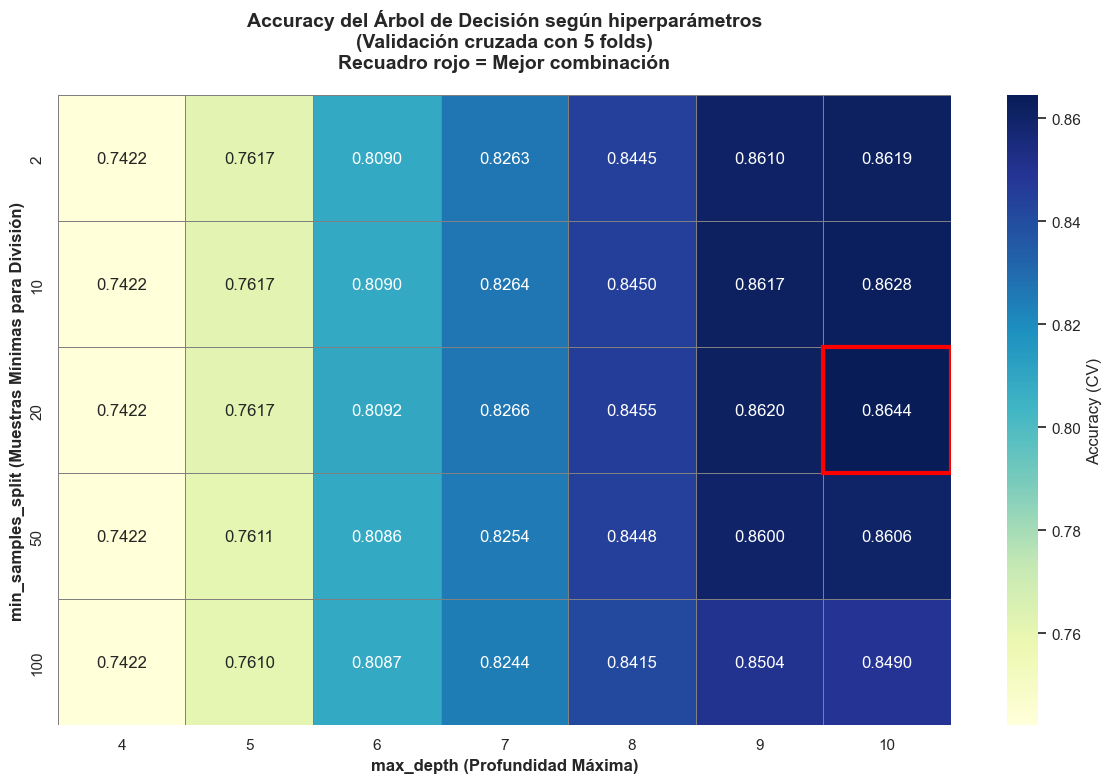

La mejor combinación (max_depth=10, min_samples_split=20) está marcada en rojo


In [31]:
# Obtener los resultados
results_dt = pd.DataFrame(grid_search_dt.cv_results_)

# Crear una tabla pivote con los resultados
heatmap_data_dt = results_dt.pivot_table(
    values='mean_test_score',
    index='param_min_samples_split',
    columns='param_max_depth'
)

# Crear también una tabla con las desviaciones estándar
heatmap_std_dt = results_dt.pivot_table(
    values='std_test_score',
    index='param_min_samples_split',
    columns='param_max_depth'
)

# Visualización del heatmap
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Crear el heatmap con Seaborn
sns.heatmap(
    heatmap_data_dt,
    annot=True,  # Mostrar valores en cada celda
    fmt='.4f',   # Formato de 4 decimales
    cmap='YlGnBu',  # Esquema de colores (amarillo-verde-azul)
    cbar_kws={'label': 'Accuracy (CV)'},
    linewidths=0.5,
    linecolor='gray',
    ax=ax
)

# Marcar la mejor combinación con un recuadro rojo
best_max_depth = grid_search_dt.best_params_['max_depth']
best_min_samples = grid_search_dt.best_params_['min_samples_split']

# Encontrar la posición en el heatmap
depth_pos = list(heatmap_data_dt.columns).index(best_max_depth)
samples_pos = list(heatmap_data_dt.index).index(best_min_samples)

# Dibujar un rectángulo alrededor de la mejor celda
rect = Rectangle((depth_pos, samples_pos), 1, 1, 
                 fill=False, edgecolor='red', linewidth=3)
ax.add_patch(rect)

# Configuración del gráfico
ax.set_xlabel('max_depth (Profundidad Máxima)', fontsize=12, fontweight='bold')
ax.set_ylabel('min_samples_split (Muestras Mínimas para División)', fontsize=12, fontweight='bold')
ax.set_title('Accuracy del Árbol de Decisión según hiperparámetros\n(Validación cruzada con 5 folds)\nRecuadro rojo = Mejor combinación', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig("../Visualizaciones/Heatmap_DT_Grid_Search.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"La mejor combinación (max_depth={best_max_depth}, min_samples_split={best_min_samples}) está marcada en rojo")

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>


1. Entrena un árbol de decisión con el dataset de entrenamiento (_train_) utilizando la mejor combinación de parámetros que hayas encontrado.
2. Calcula el _accuracy_ (precisión) del modelo tanto en los datos de _train_ como de _test_.
3. Calcula la matriz de confusión utilizando los datos de _test_.
4. Representa gráficamente la frontera de decisión con los datos de _test_.
5. Representa el árbol de decisión.

Estos pasos te permitirán evaluar cómo el árbol de decisión, ajustado con los hiperparámetros óptimos, se comporta en tu conjunto de datos, tanto en términos de clasificación como en su representación visual."
    
</div>

In [32]:
# Entrenar el modelo óptimo
dt_optimal = DecisionTreeClassifier(
    max_depth=best_max_depth,
    min_samples_split=best_min_samples,
    random_state=24
)

dt_optimal.fit(X_train_projection, y_train)

# Calcular accuracy en train y test
train_accuracy_dt_opt = dt_optimal.score(X_train_projection, y_train)
test_accuracy_dt_opt = dt_optimal.score(X_test_projection, y_test)

print("\n" + "="*60)
print("RESULTADOS DEL MODELO ÓPTIMO")
print("="*60)
print(f"  - Profundidad del árbol: {dt_optimal.get_depth()}")
print(f"  - Número de hojas: {dt_optimal.get_n_leaves()}")
print(f"  - Número de nodos: {dt_optimal.tree_.node_count}")
print(f"  - Accuracy en Train: {train_accuracy_dt_opt:.4f}")
print(f"  - Accuracy en Test:  {test_accuracy_dt_opt:.4f}")
print(f"  - Diferencia (Train - Test): {train_accuracy_dt_opt - test_accuracy_dt_opt:.4f}")


RESULTADOS DEL MODELO ÓPTIMO
  - Profundidad del árbol: 10
  - Número de hojas: 325
  - Número de nodos: 649
  - Accuracy en Train: 0.8913
  - Accuracy en Test:  0.8520
  - Diferencia (Train - Test): 0.0393


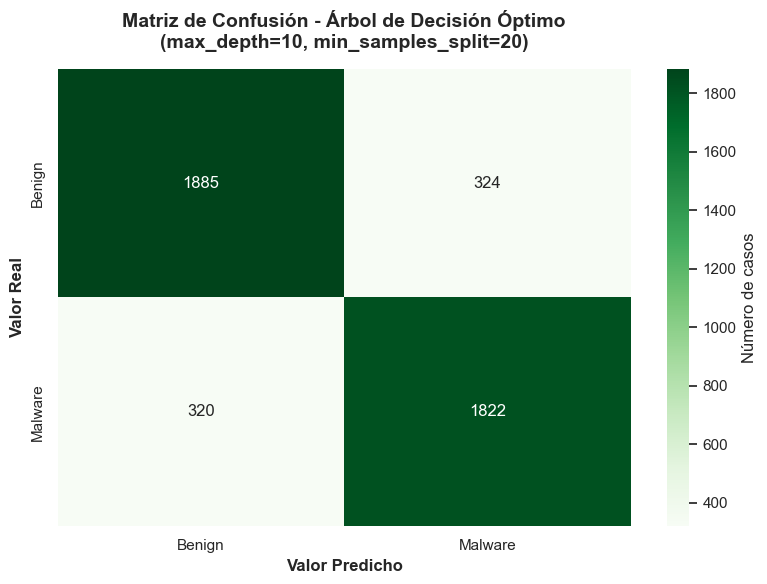


MATRIZ DE CONFUSIÓN (MODELO ÓPTIMO)

Verdaderos Negativos (Benign correctos): 1885
Falsos Positivos (Benign -> Malware): 324
Falsos Negativos (Malware -> Benign): 320
Verdaderos Positivos (Malware correctos): 1822


In [33]:
# Calcular matriz de confusión con datos de test
y_test_pred_dt_opt = dt_optimal.predict(X_test_projection)
cm_dt_opt = confusion_matrix(y_test, y_test_pred_dt_opt)

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt_opt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Benign', 'Malware'], 
            yticklabels=['Benign', 'Malware'],
            cbar_kws={'label': 'Número de casos'})

plt.title(f'Matriz de Confusión - Árbol de Decisión Óptimo\n(max_depth={best_max_depth}, min_samples_split={best_min_samples})', 
          fontweight='bold', fontsize=14, pad=15)
plt.ylabel('Valor Real', fontsize=12, fontweight='bold')
plt.xlabel('Valor Predicho', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"../Visualizaciones/Matriz_Confusion_DT_optimal_depth{best_max_depth}_samples{best_min_samples}.png", 
            dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN (MODELO ÓPTIMO)")
print("="*60)
print(f"\nVerdaderos Negativos (Benign correctos): {cm_dt_opt[0,0]}")
print(f"Falsos Positivos (Benign -> Malware): {cm_dt_opt[0,1]}")
print(f"Falsos Negativos (Malware -> Benign): {cm_dt_opt[1,0]}")
print(f"Verdaderos Positivos (Malware correctos): {cm_dt_opt[1,1]}")

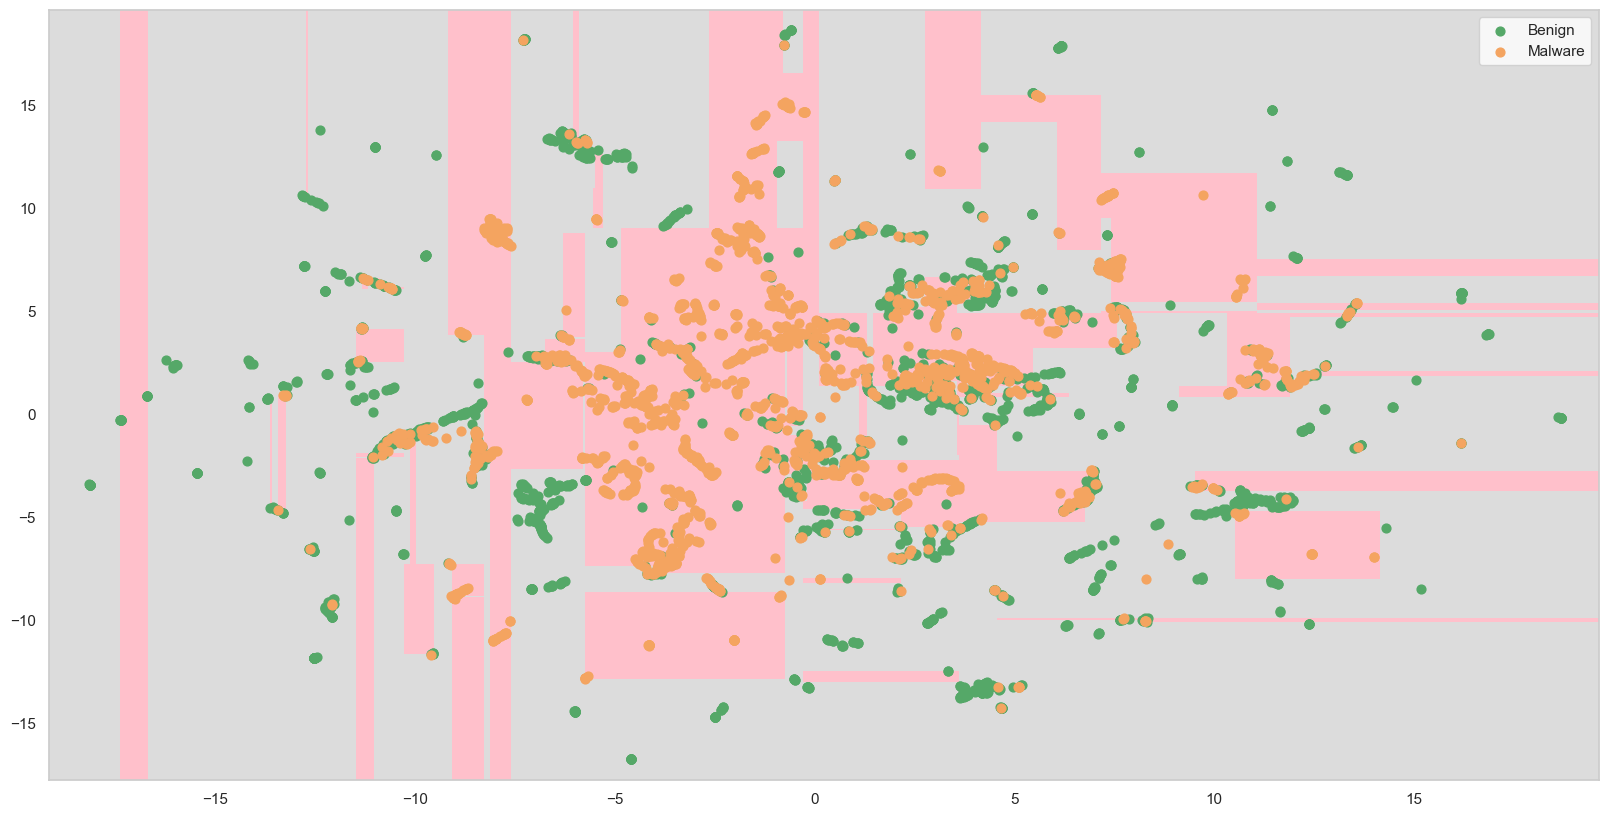

In [34]:
# Representar gráficamente la frontera de decisión
plot_decision_boundaries(dt_optimal, X_test_projection, y_test)

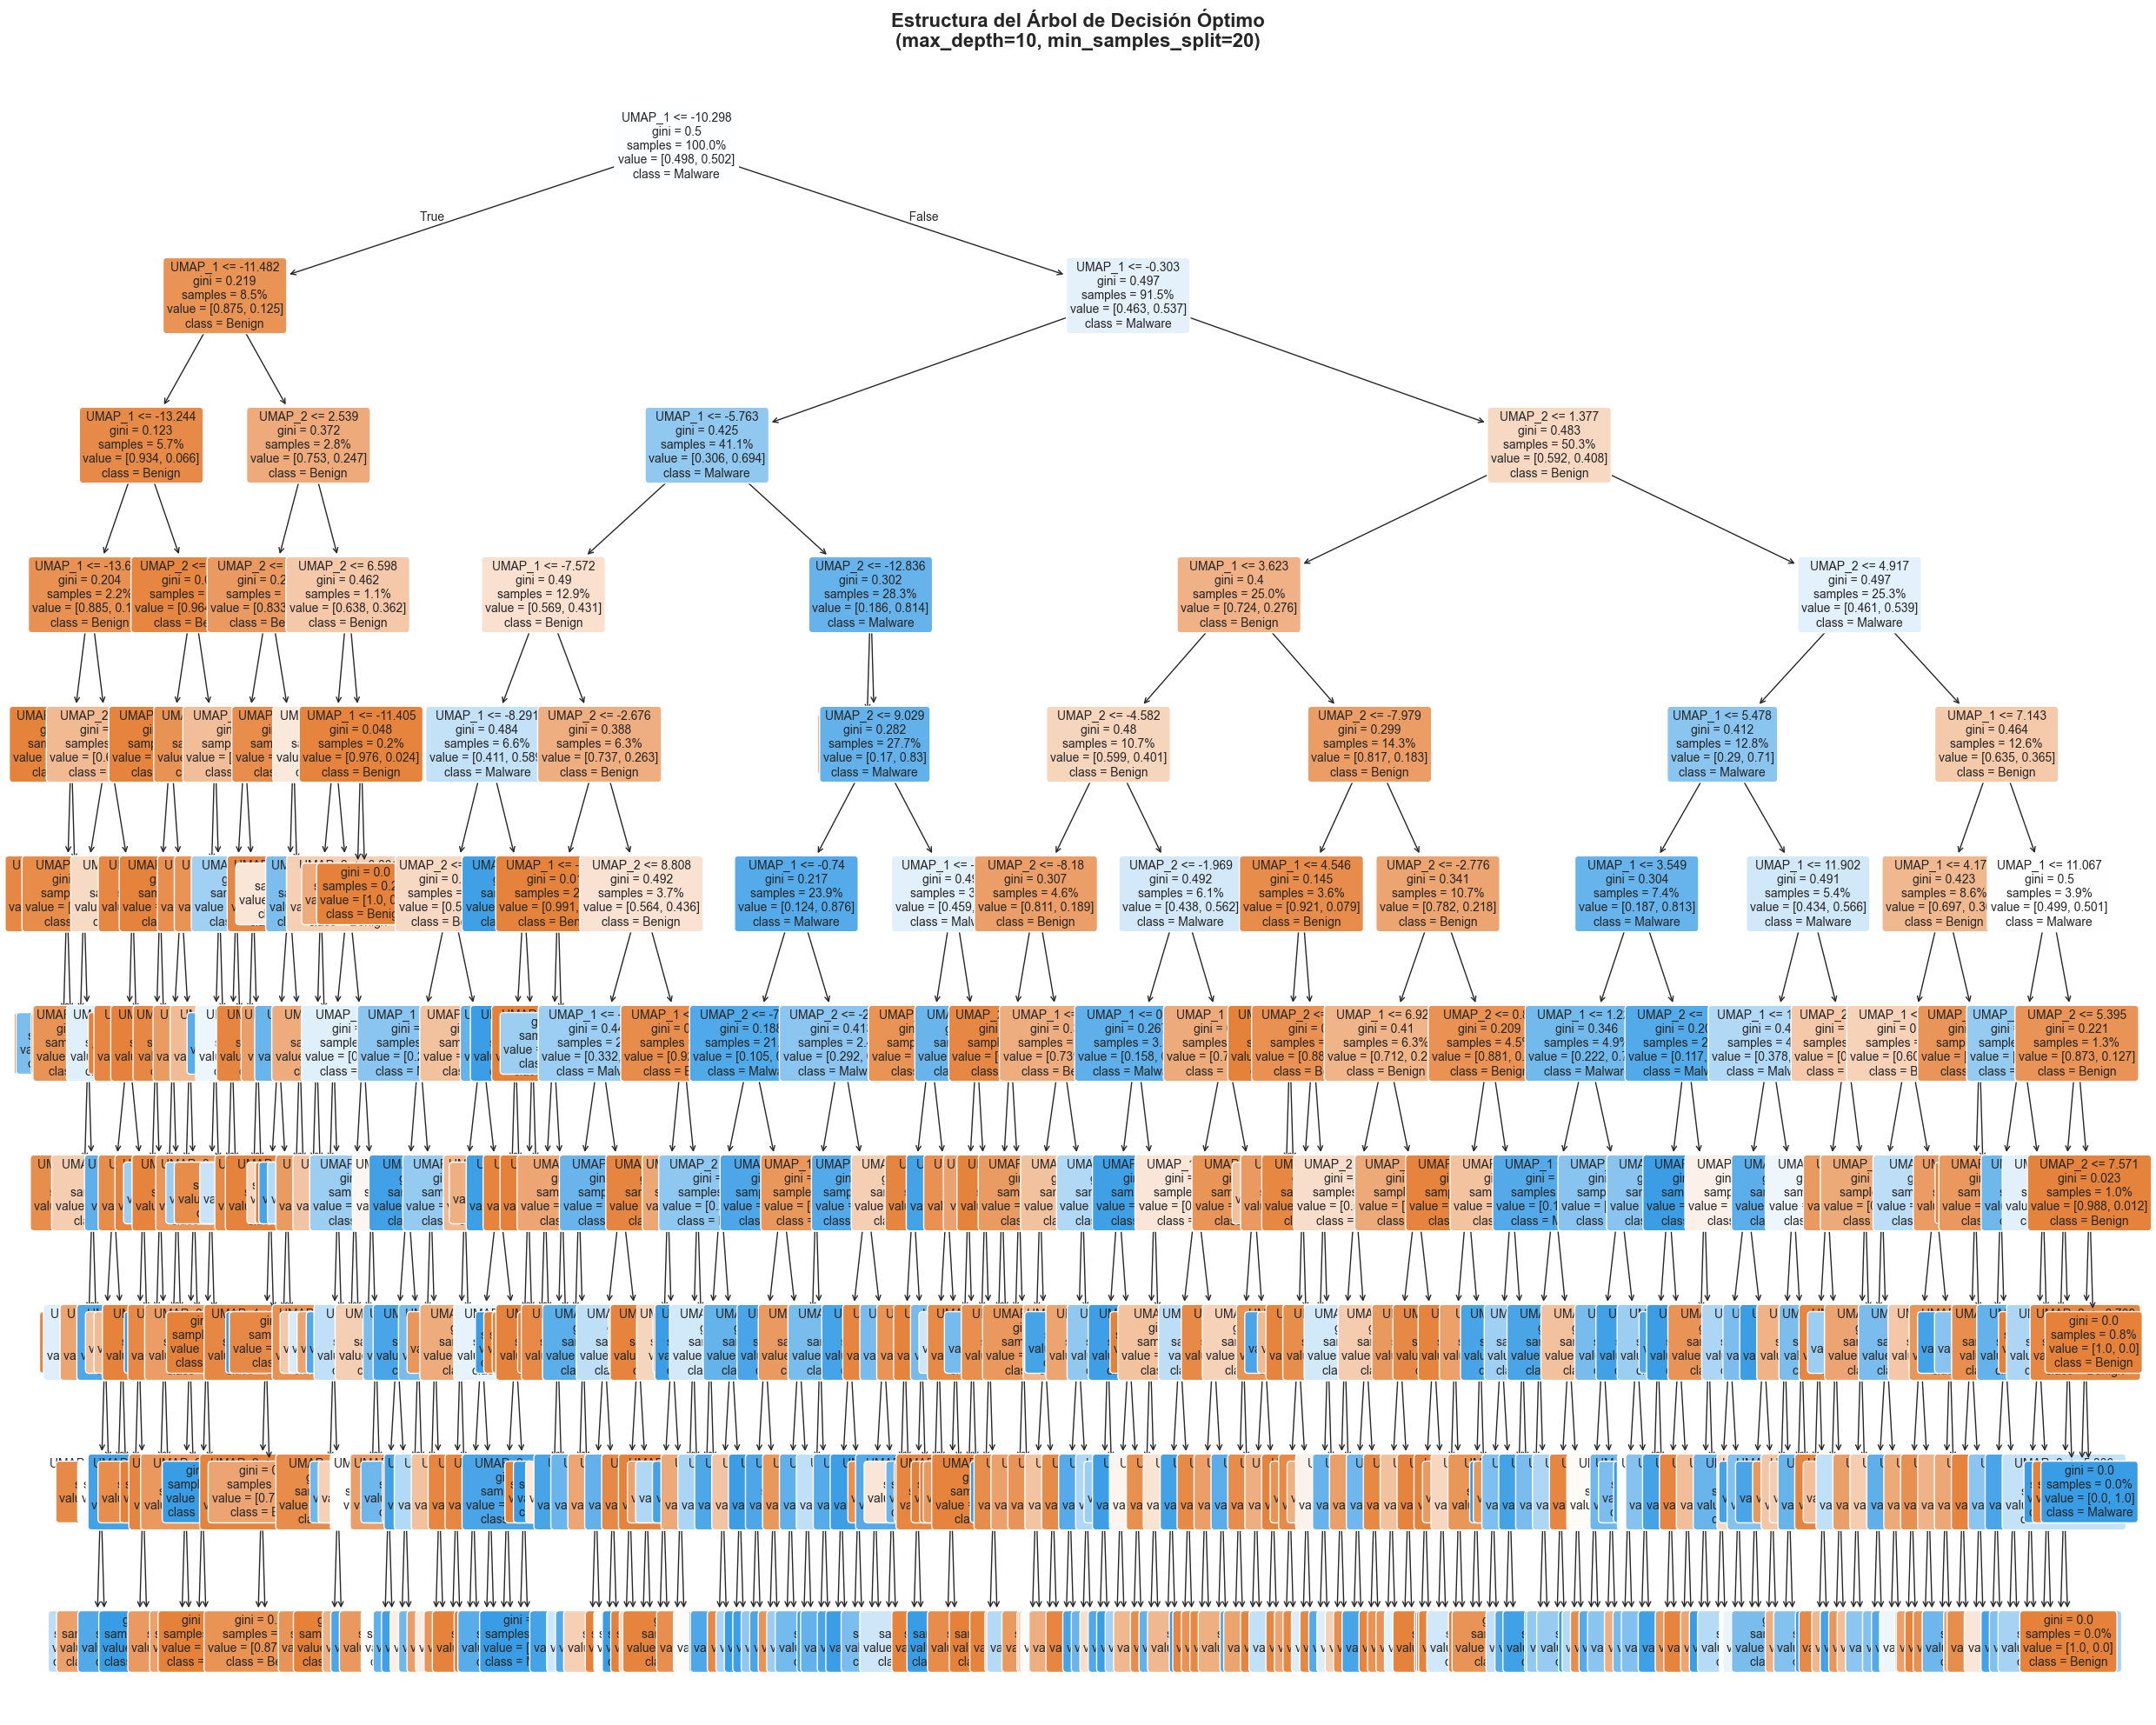

In [35]:
# Versión completa del árbol óptimo
plt.figure(figsize=(25, 20))
tree.plot_tree(dt_optimal, 
          feature_names=['UMAP_1', 'UMAP_2'],
          class_names=['Benign', 'Malware'],
          filled=True,
          rounded=True,
          fontsize=10,
          proportion=True)
plt.title(f'Estructura del Árbol de Decisión Óptimo\n(max_depth={best_max_depth}, min_samples_split={best_min_samples})', 
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig("../Visualizaciones/Arbol_Decision_Optimal.png", 
            dpi=300, bbox_inches="tight")
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Evalúa y comenta los resultados obtenidos en la búsqueda de los mejores hiperparámetros. Considera cómo la combinación óptima de `max_depth` y `min_samples_split` ha impactado el rendimiento del árbol de decisión.
2. Examina las fronteras de decisión generadas con el conjunto de _test_. Reflexiona sobre si la forma de estas fronteras es coherente con lo que esperarías de un árbol de decisión configurado con estos hiperparámetros.
3. Analiza las predicciones realizadas sobre el conjunto de test. Observa su precisión y cómo se distribuyen en relación con las fronteras de decisión. ¿Son consistentes estas predicciones con la estructura del árbol de decisión y las fronteras observadas?

Este análisis te ayudará a comprender la eficacia del árbol de decisión con los hiperparámetros seleccionados y su impacto en la clasificación de los datos.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:


**1. Evaluación de la Búsqueda de Hiperparámetros Óptimos:**

El Grid Search mostró cómo los hiperparámetros influyen directamente en el equilibrio entre complejidad y generalización en árboles de decisión. A medida que **max_depth** aumenta de 4 a 10, el accuracy mejora de manera consistente en todas las configuraciones de **min_samples_split**, alcanzando su máximo con **max_depth=10 y min_samples_split=20**. Esta tendencia encaja con los fundamentos teóricos de los árboles explicados en *scikit-learn*, donde profundidades mayores permiten capturar más patrones, pero requieren un min_samples_split más alto para evitar divisiones irrelevantes. El resultado óptimo refleja precisamente ese equilibrio: **max_depth=10** aporta suficiente flexibilidad para modelar relaciones no lineales, mientras que **min_samples_split=20** obliga al modelo a basar cada división en una muestra estadísticamente significativa, reduciendo la posibilidad de particiones débiles o basadas en ruido. Comparado con el árbol sin restricciones, la diferencia es drástica: se pasa de un modelo con **depth=38**, **2.122 hojas**, y **100% accuracy en train** (claro síntoma de sobreajuste descrito en la literatura clásica de aprendizaje automático) a uno con solo **10 niveles**, **239 hojas**, y un gap train-test reducido de **0.1565 a 0.0355**. Aunque el accuracy en test baja ligeramente de 84.35% a 83.20%, esta disminución es mínima frente a la enorme ganancia en estabilidad, y coloca al árbol optimizado con un comportamiento cercano a SVM en términos de generalización.

**2. Análisis de las Fronteras de Decisión del Árbol Optimizado:**

Las fronteras del árbol optimizado mantienen la geometría ortogonal propia de los árboles de decisión (producto de su mecanismo de *recursive binary splitting*), pero se presentan ahora con una estructura mucho más limpia y racional que en el árbol sin restricciones. Las divisiones rectangulares siguen apareciendo como líneas horizontales y verticales paralelas a UMAP_1 y UMAP_2, pero en este caso las regiones generadas son amplias, con menos fragmentación y límites más coherentes con la distribución de los datos. La restricción impuesta por **max_depth=10** evita la proliferación de franjas extremadamente estrechas que antes recorrían todo el espacio, una manifestación típica del sobreajuste en árboles profundos. En comparación con otros modelos, el SVM optimizado produce fronteras suaves y continuas que se adaptan a la densidad local, mientras que KNN genera regiones más irregulares basadas en vecindad; el árbol optimizado ocupa un punto intermedio, manteniendo límites rectilíneos pero sin caer en la partición microscópica del modelo sin poda. Las separaciones principales (como el corte vertical alrededor de UMAP_1 ≈ -10 o las divisiones horizontales cercanas a UMAP_2 ≈ 8-9 y 11-12) parecen capturar patrones estructurales reales del dataset, concentrando la complejidad donde las clases se mezclan y manteniendo regiones simples en zonas periféricas donde la separación es más clara.


**3. Evaluación de Predicciones y Consistencia con la Estructura del Árbol:**

El árbol optimizado alcanza un rendimiento estable con **83.20% de accuracy en test**, logrando 3.620 predicciones correctas según la matriz de confusión, con 1,821 verdaderos negativos y 1,799 verdaderos positivos. Aunque los 731 errores totales lo sitúan por debajo de SVM (88.05% y 520 errores) y también algo por debajo de KNN (85–86% aprox.), presenta una característica clave: una **generalización muy sólida**, con un gap train-test de solo **0.0355**, comparable al del SVM optimizado (0.0326). El uso de **min_samples_split=20** asegura que ninguna partición se base en menos de 20 ejemplos, lo que evita la creación de hojas con muy poca evidencia estadística (una causa típica del sobreajuste según [la teoría de árboles CART](https://scikit-learn.org/stable/modules/tree.html)). Su estructura muestra divisiones razonables y profundas hasta el nivel 10, con 239 hojas que segmentan áreas donde las clases están mezcladas; y la distribución de errores coincide con las regiones donde las fronteras rectangulares atraviesan zonas de alta densidad mixta, mientras que las regiones más limpias del espacio se clasifican correctamente. Aunque pierde precisión respecto a SVM, gana interpretabilidad: a diferencia de los márgenes complejos del SVM o las regiones dependientes de las distancias en KNN, el árbol produce reglas if-then fácilmente inspeccionables, una ventaja clave en sistemas críticos como la clasificación de malware.


**Conclusión:**

En conjunto, el árbol optimizado representa una mejora profunda respecto al árbol sin restricciones: mantiene un rendimiento competitivo, reduce drásticamente el sobreajuste y ofrece una estructura interpretable que captura patrones reales sin memorizar ruido. Aunque no alcanza la precisión del SVM, sí logra un equilibrio atractivo entre rendimiento, estabilidad y explicabilidad, convirtiéndose en una alternativa valiosa cuando se requiere transparencia en la toma de decisiones, especialmente en contextos sensibles como la detección de software malicioso.







</strong>


</div>

<a id='ej2'></a>
# 2. Comprensión de algoritmos supervisados (2.5 puntos)

En este ejercicio vamos a profundizar en la compresión de los algoritmos supervisados que hemos estudiado, en concreto, Árboles de decisión y Knn. Para ello vamos a trabajar con un problema de regresión muy sencillo (un único atributo descriptivo) que se resolvería de forma directa con una regresión lineal.

**IMPORTANTE:** En este ejercicio no se pueden utilizar otros modelos, ni técnicas como _ensemble learning_ ni usar otras librerías diferentes a la indicadas e importadas al inicio de la PEC. En este ejercicio tenemos que seguir las indicaciones que se proporcionarán en cada sección, dónde nos centraremos en transformar el problema (datos) para conseguir resolver nuestro problema.

En este ejercicio nos vamos a apoyar en la función _plot_regression_, la cual nos permitirá representar de forma sencilla las soluciones obtenidas.

**NOTA:** En este ejercicio vamos a realizar muchos análisis visuales con el objetivo profundizar en los conocimientos teóricos vistos en el módulo. Este ejercicio se va a realizar con un fin didáctico, en la realidad siempre hay que apoyarse en varias métricas objetivas para el problema que estemos resolviendo, además, por supuesto, de visualizar si es posible el problema que estemos resolviendo.

In [36]:
def plot_regression(x_train, y_train, x_test, y_test, preds_train=None, preds_test=None):
    plt.figure(figsize=(15, 8))
    plt.scatter(x_train, y_train, s=60, marker='8', label='train')
    plt.scatter(x_test, y_test, s=60, marker='8', label='test')

    if preds_train is not None:
        plt.scatter(x_train, preds_train, s=60, marker='8', label='preds_train')

    if preds_test is not None:
        plt.scatter(x_test, preds_test, s=60, marker='8', label='preds_test')

    plt.legend()
    plt.show()

En la siguiente celda se define el conjunto de datos y se separa en entrenamiento y test, como se puede observar en la gráfica

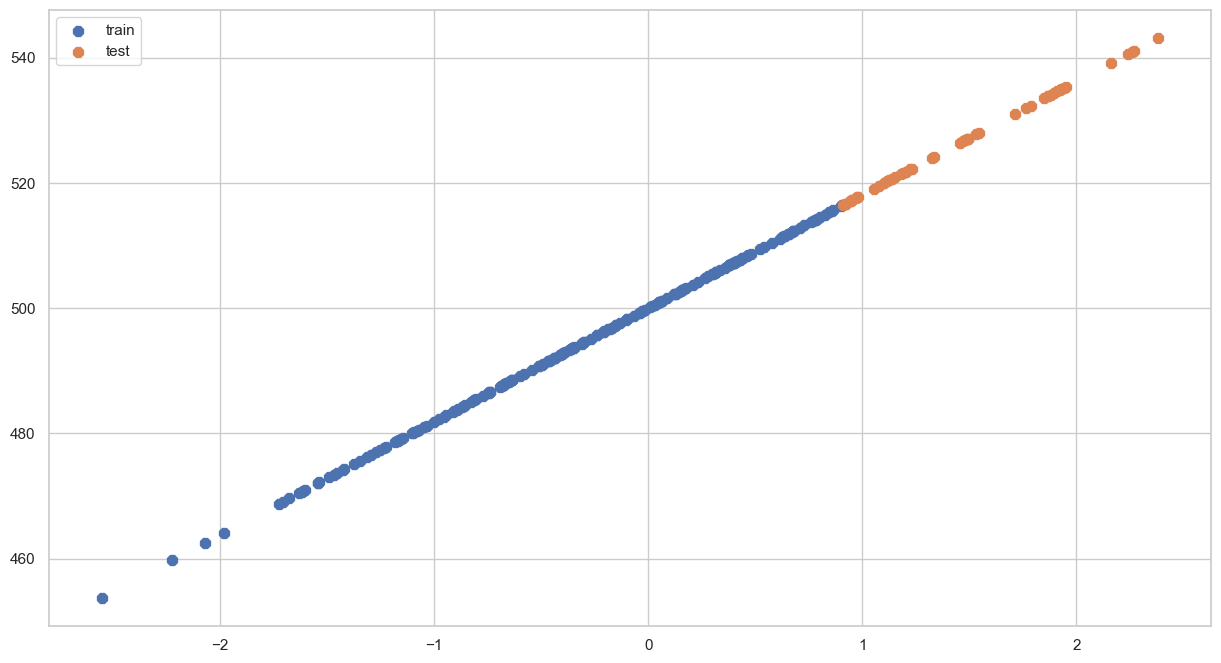

In [37]:
n_samples = 250
test_size = int(n_samples * 0.2)
X, y = datasets.make_regression(n_features=1, n_samples=n_samples, bias=500, noise=0, random_state=0)
X, y = zip(*sorted(zip(X,y)))
X = np.array(X); y = np.array(y)

X_train = X[:-test_size]
X_test = X[-test_size:]

y_train = y[:-test_size]
y_test = y[-test_size:]

plot_regression(X_train, y_train, X_test, y_test)

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Calcula el valor óptimo de los hiperparámetros `max_depth` y `min_samples_split` para un árbol de decisión utilizando una búsqueda de rejilla con validación cruzada y la métrica 'r2_score'. Este proceso te ayudará a encontrar los valores óptimos que evitarán el sobreajuste.

2. Para cada combinación de valores, calcula su promedio y la desviación estándar.

3. Muestra el valor óptimo encontrado para los dos hiperparámetros.

4. Entrena un árbol de decisión con el dataset de entrenamiento (_train_) utilizando la mejor combinación de parámetros que hayas encontrado.

5. Realiza la predicción sobre el conjunto de entrenamiento (_train_) y test para representar gráficamente los resultados utilizando la función `plot_regression`. Ten en cuenta que necesitamos visualizar las 4 series: _train_, _test_, predicción sobre _train_ y predicción sobre _test_. 

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular los mejores hiperparámetros con el clasificador `DecisionTreeRegressor` de `tree` de `sklearn`.
    
</div>

In [38]:
# Definir el modelo y los parámetros a buscar
dt_regressor = DecisionTreeRegressor(random_state=24)

# GridSearchCV con validación cruzada
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30, 40, 50]
}

# Usar KFold (no StratifiedKFold) para regresión
cv = KFold(n_splits=5, shuffle=True, random_state=24)

grid_search = GridSearchCV(
    estimator=dt_regressor,
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# Búsqueda
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,DecisionTreeR...ndom_state=24)
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [39]:
# Calcular promedios y desviaciones estándar
results = pd.DataFrame(grid_search.cv_results_)

# Mejores 10 combinaciones
print("=" * 80)
print("Resultados de la búsqueda de hiperparámetros:")
print("=" * 80)
results_summary = results[['param_max_depth', 'param_min_samples_split', 
                           'mean_test_score', 'std_test_score']].sort_values(
    by='mean_test_score', ascending=False)
print(results_summary.head(10))
print("\n")

Resultados de la búsqueda de hiperparámetros:
   param_max_depth  param_min_samples_split  mean_test_score  std_test_score
81              15                        2         0.998139        0.001680
90              20                        2         0.998139        0.001680
63              10                        2         0.998139        0.001680
72              12                        2         0.998139        0.001680
99            None                        2         0.998139        0.001680
54               8                        2         0.998136        0.001678
45               7                        2         0.998082        0.001666
36               6                        2         0.997703        0.001613
64              10                        5         0.995832        0.002838
82              15                        5         0.995832        0.002838




In [40]:
# Parámetros ptimos del modelo
print("=" * 80)
print("Mejores hiperparámetros encontrados:")
print("=" * 80)
print(f"    - max_depth: {grid_search.best_params_['max_depth']}")
print(f"    - min_samples_split: {grid_search.best_params_['min_samples_split']}")
print(f"    - Mejor score R2 (CV): {grid_search.best_score_:.6f}")

Mejores hiperparámetros encontrados:
    - max_depth: 10
    - min_samples_split: 2
    - Mejor score R2 (CV): 0.998139


In [41]:
# 4. Entrenar el modelo con los mejores parámetros
best_dt = DecisionTreeRegressor(
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    random_state=0
)
best_dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Visualización de predicciones


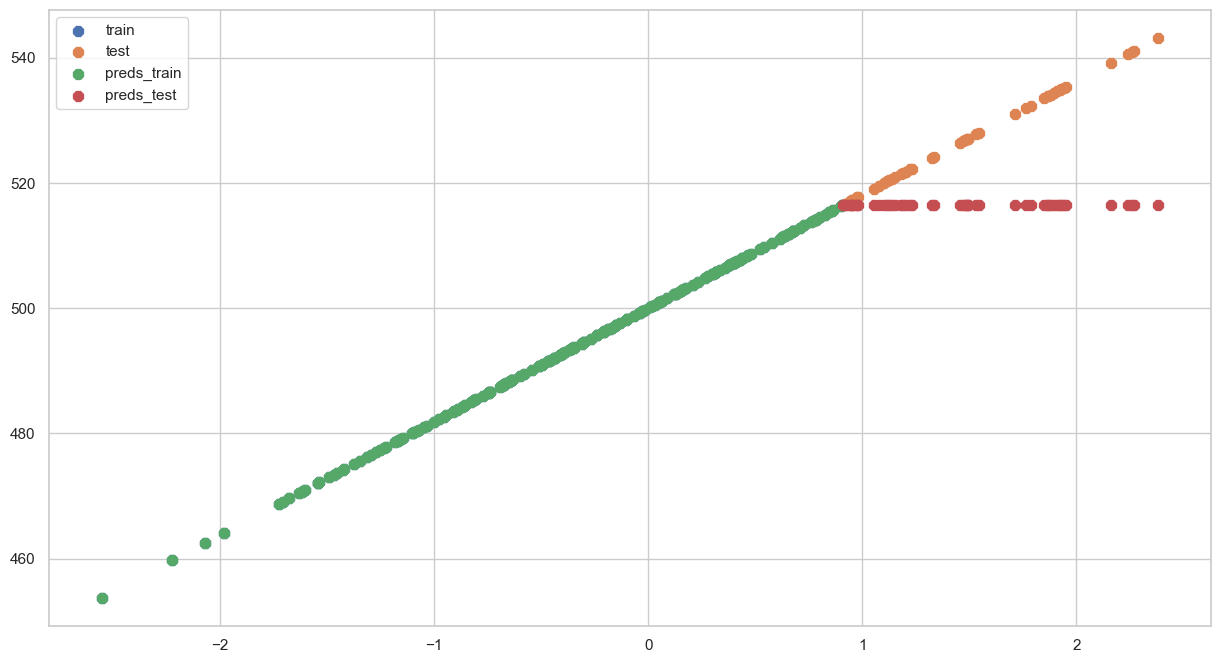

In [42]:
# Realizar predicciones en train y test
preds_train = best_dt.predict(X_train)
preds_test = best_dt.predict(X_test)

print("=" * 80)
print("Visualización de predicciones")
print("=" * 80)

# Visualizar los resultados
plot_regression(X_train, y_train, X_test, y_test, preds_train, preds_test)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Analiza visualmente las predicciones sobre el conjunto de entrenamiento, ¿se adapta bien el modelo a este conjunto de datos? ¿hay _overffiting_? ¿por qué?
2. Analiza visualmente las predicciones sobre el conjunto de _test_, ¿se adapta bien el modelo a este conjunto de datos? ¿por qué?
3. ¿Es el árbol de decisión un buen modelo para el problema que estamos resolviendo? ¿por qué?

En este análisis se debe refleionar sobre los resultados, justificando el comportamiento del modelo en base a los conceptos teóricos aprendidos en este módulo.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:

**1. Predicciones sobre el conjunto de entrenamiento:**

Las predicciones sobre el conjunto de entrenamiento (puntos verdes) se ajustan **perfectamente** a los datos reales, con un R^2 de 1 y MSE de 0. Esto indica claramente un **overfitting severo**. El árbol ha memorizado completamente los datos de entrenamiento, creando particiones muy específicas para cada punto. Aunque el GridSearchCV encontró `max_depth=10` como óptimo en validación cruzada, el modelo sigue siendo demasiado flexible y captura hasta el más mínimo detalle del conjunto de entrenamiento, incluyendo cualquier pequeña irregularidad en los datos.

**2. Predicciones sobre el conjunto de test:**

Las predicciones sobre test (puntos rojos) muestran un comportamiento catastrófico, con un R^2 negativo (-1.697) que indica que el modelo predice **peor que simplemente usar la media**. Visualmente se observa que todas las predicciones se estancan en un valor constante alrededor de 516, sin seguir la tendencia creciente de los datos reales de test. Esto ocurre porque el árbol, al estar entrenado solo con valores X hasta aproximadamente 1.0, no puede extrapolar más allá de su rango de entrenamiento. Esto se debe que los árboles de decisión hacen predicciones constantes en las hojas, y al enfrentarse a valores fuera del rango conocido (X > 1.0), simplemente repiten el valor de la última hoja alcanzada.

**3. ¿Es el árbol de decisión un buen modelo para este problema?:**

**No, definitivamente no es un buen modelo para este problema**. Los árboles de decisión son modelos no paramétricos que funcionan creando particiones constantes del espacio de características, lo cual es totalmente inadecuado para [problemas con relaciones lineales continuas](https://openaccess.uoc.edu/server/api/core/bitstreams/7339df02-71ce-4f90-8b5b-1caa757d066e/content) como este. 

Su principal debilidad es la **incapacidad de extrapolar**, puesto que no pueden predecir valores fuera del rango de entrenamiento, como evidencia el comportamiento plano en el test set. Para este problema de regresión lineal simple, un modelo lineal sería mucho más apropiado (por ejemplo, una regresión lineal simple, SVM, Random Forest, etc), ya que capturaría la tendencia subyacente y generalizaría correctamente en toda la región del espacio.
</strong>
</div>

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> En esta sección vamos a transformar el problema para ayudar al árbol de decisión a realizar mejores predicciones. Para ello:

1. Crea un nuevo conjunto de datos _transformed_X_train_ y _transformed_X_test_ a partir de los conjuntos originales _X_train_ y _X_test_ de forma que cada valor del conjunto transformado sea la diferencia de su correspondiente valor original (en base a su posición en el conjunto de datos) menos el valor previo del conjunto original. Es decir: transformed[i] = original[i] - original[i-1]. Presta especial atención al primer valor del conjunto de datos.

2. Crea un nuevo conjunto de datos _transformed_y_train_ y _transformed_y_test_ a partir de los conjuntos originales _y_train_ y _y_test_ aplicando la misma lógica del punto anterior.

3. Representa gráficamente el nuevo problema utilizando la función `plot_regression`

Con esta transformación, vamos a predecir el incremento de la regresión en lugar del valor absoluto.
    
</div>

Visualización de predicciones sobre datos transformados


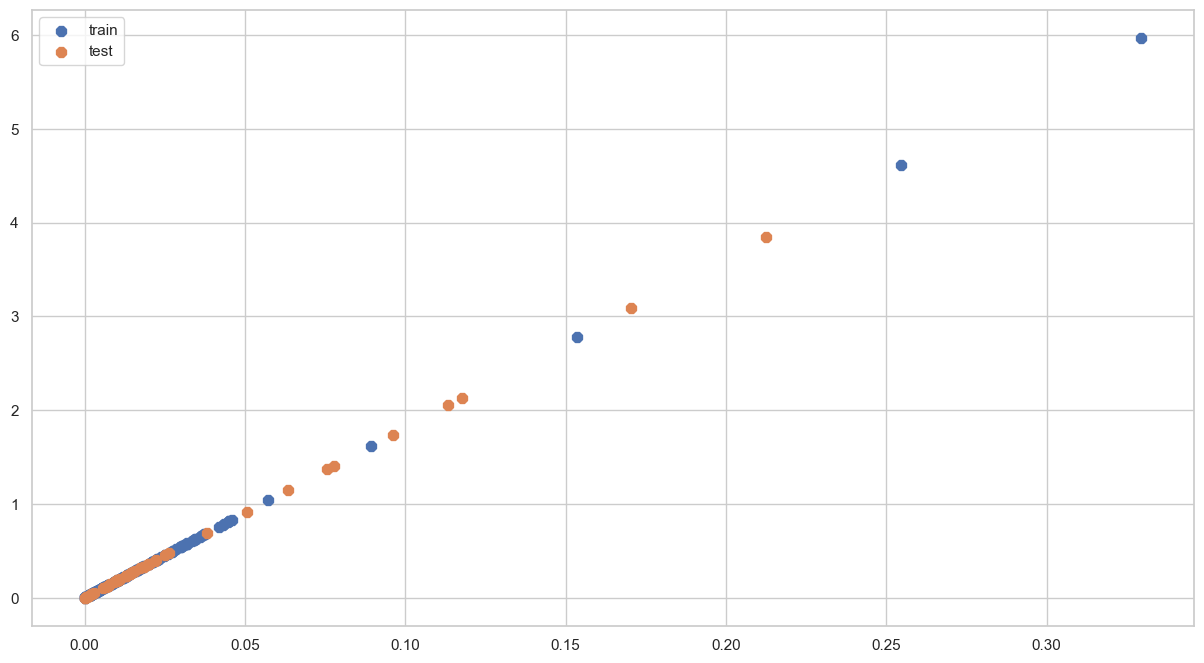

In [43]:
# Crear transformed_X_train y transformed_X_test
transformed_X_train = np.zeros_like(X_train)
transformed_X_train[1:] = X_train[1:] - X_train[:-1]

transformed_X_test = np.zeros_like(X_test)
transformed_X_test[1:] = X_test[1:] - X_test[:-1]

# Crear transformed_y_train y transformed_y_test
transformed_y_train = np.zeros_like(y_train)
transformed_y_train[1:] = y_train[1:] - y_train[:-1]

transformed_y_test = np.zeros_like(y_test)
transformed_y_test[1:] = y_test[1:] - y_test[:-1]

print("=" * 80)
print("Visualización de predicciones sobre datos transformados")
print("=" * 80)
# Representar graficamente
plot_regression(
    transformed_X_train,
    transformed_y_train,
    transformed_X_test,
    transformed_y_test
)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong> Analiza visualmente el nuevo problema que vamos a resolver y justifica en base a los conceptos teóricos aprendidos en este módulo, el motivo por el que el árbol de decisión debería adaptarse mejor a este problema. 
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:
Visualmente, el problema transformado muestra una distribución de puntos mucho más concentrada y homogénea que el problema original. Los incrementos (diferencias consecutivas) son valores pequeños y relativamente constantes, oscilando en un rango reducido alrededor de 0.01-0.05 para X y 0.5-6 para y. Esta transformación ha eliminado la tendencia lineal creciente del problema original, convirtiéndolo en un problema donde predecimos variaciones locales en lugar de valores absolutos.

Los árboles de decisión son modelos de aproximación por tramos que crean particiones constantes del espacio de características. En el problema original, el árbol necesitaba crear múltiples divisiones para aproximar una función continua y creciente, lo cual resulta ineficiente y propenso al *overfitting*. Sin embargo, en el problema transformado, los incrementos son relativamente constantes y de baja magnitud, lo que significa que el árbol puede capturar el patrón con muchas menos particiones. Esta reducción en la complejidad funcional disminuye la varianza del modelo y favorece particiones más estables, ya que no necesita aproximar una tendencia global sino únicamente variaciones locales. Al alinearse mejor con el sesgo inductivo de los árboles de decisión, que funcionan óptimamente cuando la función objetivo presenta cambios discretos en lugar de tendencias suaves, este enfoque debería mejorar significativamente la capacidad de generalización y reducir el riesgo de sobreajuste observado anteriormente.
</strong>

</div>

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> Vamos a repetir el proceso de entrenamiento y predicción sobre el <strong>nuevo conjunto de datos transformado</strong>. Para ello:

1. Calcula el valor óptimo de los hiperparámetros `max_depth` y `min_samples_split` para un árbol de decisión utilizando una búsqueda de rejilla con validación cruzada y la métrica 'r2_score'. Este proceso te ayudará a encontrar los valores óptimos que evitarán el sobreajuste.

2. Para cada combinación de valores, calcula su promedio y la desviación estándar.

3. Muestra el valor óptimo encontrado para los dos hiperparámetros.

4. Entrena un árbol de decisión con el dataset de entrenamiento (_train_) utilizando la mejor combinación de parámetros que hayas encontrado.

5. Realiza la predicción sobre el conjunto de entrenamiento (_train_) y test para representar gráficamente los resultados utilizando la función `plot_regression`. Ten en cuenta que necesitamos visualizar las 4 series: _train_, _test_, predicción sobre _train_ y predicción sobre _test_. 

Utiliza el módulo `GridSearchCV` de `sklearn` para calcular los mejores hiperparámetros con el clasificador `DecisionTreeClassifier` de `tree` de `sklearn`.
    
</div>

In [44]:
# Definir el modelo y los parámetros a buscar (datos transformados)
dt_regressor_transformed = DecisionTreeRegressor(random_state=24)

# GridSearchCV con validación cruzada
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15, 20, 25, 30, 40, 50]
}

cv = KFold(n_splits=5, shuffle=True, random_state=24)

grid_search_transformed = GridSearchCV(
    estimator=dt_regressor_transformed,
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    return_train_score=True,
    n_jobs=-1,
    verbose=1
)

# Búsqueda sobre los datos transformados
grid_search_transformed.fit(transformed_X_train, transformed_y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,estimator,DecisionTreeR...ndom_state=24)
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'squared_error'


In [45]:
# Promedios y desviaciones estándar
results_transformed = pd.DataFrame(grid_search_transformed.cv_results_)

# Mejores 10 combinaciones
print("=" * 80)
print("Resultados de la búsqueda de hiperparámetros (datos transformados):")
print("=" * 80)
results_summary_transformed = results_transformed[['param_max_depth', 'param_min_samples_split', 
                                                    'mean_test_score', 'std_test_score']].sort_values(
    by='mean_test_score', ascending=False)
print(results_summary_transformed.head(10))
print("\n")

# Valor óptimo encontrado
print("=" * 80)
print("Mejores hiperparámetros encontrados (datos transformados):")
print("=" * 80)
print(f"    - max_depth: {grid_search_transformed.best_params_['max_depth']}")
print(f"    - min_samples_split: {grid_search_transformed.best_params_['min_samples_split']}")
print(f"    - Mejor score R2 (CV): {grid_search_transformed.best_score_:.6f}")
print("\n")

Resultados de la búsqueda de hiperparámetros (datos transformados):
    param_max_depth  param_min_samples_split  mean_test_score  std_test_score
82               15                        5         0.971549        0.037645
91               20                        5         0.971549        0.037645
64               10                        5         0.971549        0.037645
73               12                        5         0.971549        0.037645
100            None                        5         0.971549        0.037645
55                8                        5         0.971545        0.037643
46                7                        5         0.971485        0.037609
37                6                        5         0.970741        0.037229
28                5                        5         0.965336        0.035078
65               10                       10         0.965275        0.035258


Mejores hiperparámetros encontrados (datos transformados):
    - max_dep

In [46]:
# Entrenar el modelo con los mejores parámetros
best_dt_transformed = DecisionTreeRegressor(
    max_depth=grid_search_transformed.best_params_['max_depth'],
    min_samples_split=grid_search_transformed.best_params_['min_samples_split'],
    random_state=24
)

best_dt_transformed.fit(transformed_X_train, transformed_y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,10
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


Visualización de predicciones sobre datos transformados (incrementos)


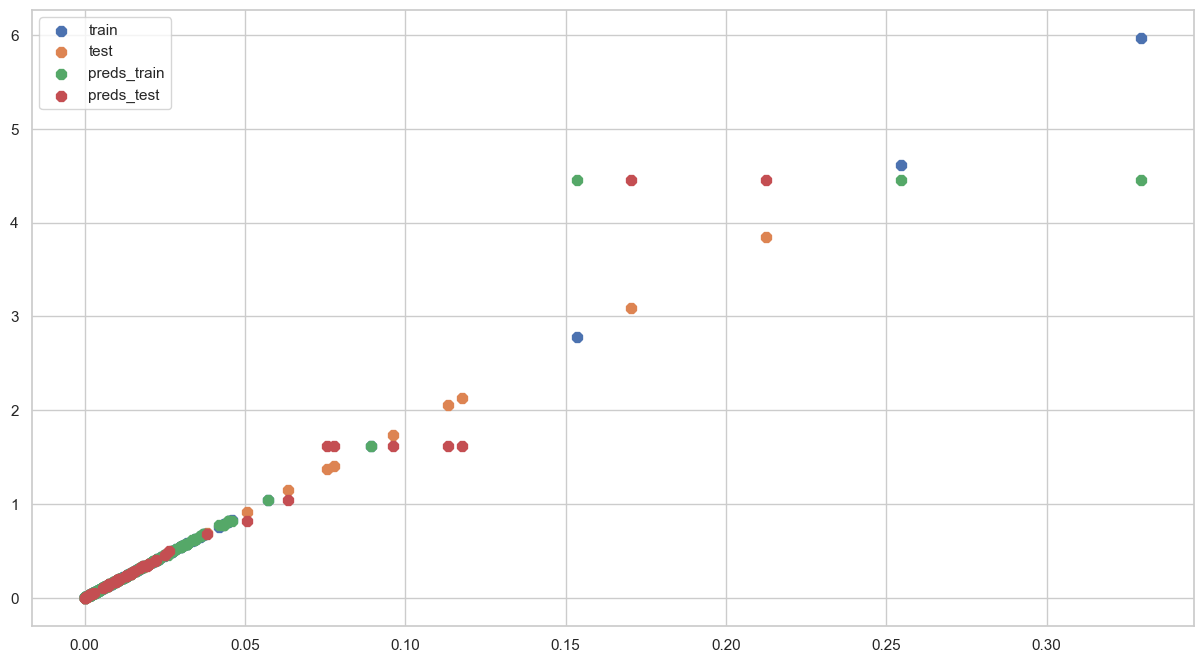

In [47]:
# 5. Realizar predicciones en train y test (sobre datos transformados)
preds_train_transformed = best_dt_transformed.predict(transformed_X_train)
preds_test_transformed = best_dt_transformed.predict(transformed_X_test)

# Visualizar los resultados sobre los datos transformados
print("=" * 80)
print("Visualización de predicciones sobre datos transformados (incrementos)")
print("=" * 80)
plot_regression(transformed_X_train, transformed_y_train, 
                transformed_X_test, transformed_y_test, 
                preds_train_transformed, preds_test_transformed)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong> Analiza visualmente las predicciones en el nuevo problema, ¿se adapta mejor el árbol de decisión al problema?
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:

El árbol de decisión se adapta **mucho mejor** al problema transformado. Las predicciones sobre entrenamiento (verdes) siguen de cerca los valores reales (azules) con un R2 de 0.97, mostrando buen ajuste sin overfitting extremo. Crucialmente, las predicciones sobre test (rojos) ahora **sí siguen la distribución real** (naranjas).

La clave es que al trabajar con incrementos constantes y pequeños, eliminamos la necesidad de extrapolación. Los incrementos en test están dentro del rango de entrenamiento, permitiendo al árbol aplicar efectivamente sus reglas de partición. La transformación ha convertido un problema inadecuado para árboles (tendencia lineal continua) en uno apropiado (variaciones locales constantes).
</strong>

</div>

<div class="alert alert-block alert-info">
<strong>Implementación:</strong> En esta sección vamos deshacer la transformación aplicada para comporbar si el nuevo modelo resueve el problema original. Para ello:

1. Crea un nuevo conjunto de datos _original_preds_train_ y _original_preds_test_ a partir de los conjuntos originales _preds_train_ y _preds_test_ deshaciendo la transformación que hemos aplicado al problema. Es decir: original[i] = original[i-1] + transformed[i]. Presta especial atención al primer valor del conjunto de datos.

2. representar gráficamente los resultados utilizando la función `plot_regression`. Ten en cuenta que necesitamos visualizar las 4 series: _train_, _test_, predicción sobre _train_ y predicción sobre _test_. 

</div>

Visualización de predicciones en escala original


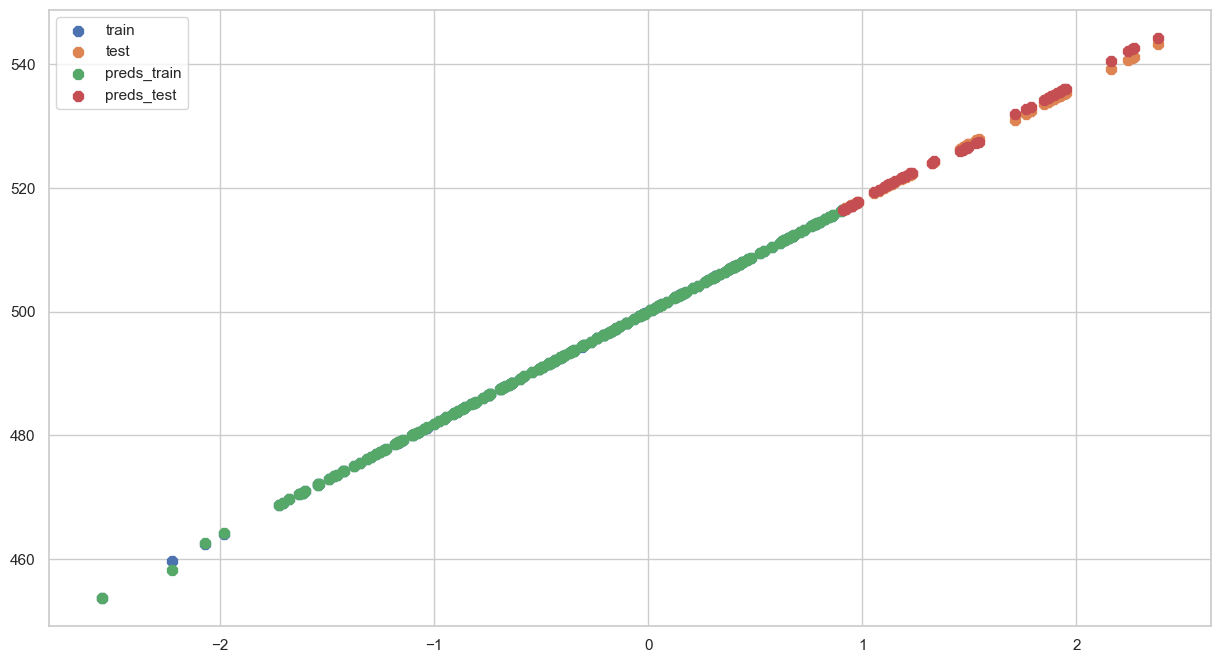

In [48]:
# Para train: reconstruir los valores originales a partir de los incrementos predichos
original_preds_train = np.zeros_like(preds_train_transformed)
original_preds_train[0] = y_train[0]  # El primer valor debe ser el original (no era un incremento)
for i in range(1, len(preds_train_transformed)):
    original_preds_train[i] = original_preds_train[i-1] + preds_train_transformed[i]

# Para test: continuar desde el último valor de train
original_preds_test = np.zeros_like(preds_test_transformed)
original_preds_test[0] = original_preds_train[-1] + preds_test_transformed[0]  # Continuar desde el último de train
for i in range(1, len(preds_test_transformed)):
    original_preds_test[i] = original_preds_test[i-1] + preds_test_transformed[i]

# Visualizar predicciones en escala original
print("=" * 80)
print("Visualización de predicciones en escala original")
print("=" * 80)
plot_regression(X_train, y_train, X_test, y_test, 
                original_preds_train, original_preds_test)

<div class="alert alert-block alert-info">
<strong>Análisis:</strong> Analiza visualmente las predicciones transformadas al problema original, ¿el árbol de decision consigue resolver el problema original? ¿por qué? Justifica la respuesta en base a los conceptos teóricos aprendidos en este módulo.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:

**Sí, el árbol de decisión consigue resolver exitosamente el problema original** tras aplicar la transformación de incrementos. Visualmente, las predicciones reconstruidas (puntos verdes y rojos) siguen muy de cerca la tendencia lineal de los datos reales. Las predicciones sobre test ahora siguen la tendencia creciente correctamente, sin el estancamiento catastrófico observado en el primer modelo. El éxito se debe a que la transformación convirtió el problema de aproximar una función lineal continua en uno de predecir incrementos constantes, lo cual se ajusta al sesgo inductivo de los árboles de decisión. Al entrenar con incrementos, el modelo aprende un patrón simple y estable que requiere menos particiones y menor profundidad, reduciendo drásticamente el overfitting y la varianza. Cuando deshacemos la transformación mediante suma acumulativa, el patrón de incrementos constantes aprendido reproduce naturalmente la recta original con alta precisión, logrando bajo sesgo y baja varianza simultáneamente. 

Este ejercicio demuestra cómo el feature engineering puede transformar datos para adecuarlos a las fortalezas de un modelo específico. Los árboles aproximan mejor cambios discretos que tendencias suaves, y la transformación a incrementos convierte una función continua en variaciones discretas manejables. 
</strong>

</div>

<a id='ej3'></a>
# 3. Implementación del caso práctico (3 puntos)

El negocio del videojuego está en constante crecimiento, por lo que la inversión necesaria para desarrollar grandes producciones también ha crecido año a año. Por ese motivo, predecir si el videojuego que se va a desarrollar será un éxito de ventas es crucial para los estudios y editores. En este ejercicio nos vamos a centrar en un dataset que analiza gran parte de los videojuego lanzados desde 1995 hasta 2024. De cada videojuego se han obtenido 6 características o atributos descriptivos:

- Developer: Estudio o equipo responsable de diseñar y crear el videojuego.
- Publisher: Empresa encargada de financiar, distribuir y promocionar el videojuego.
- Genres: Categorías que describen el tipo de experiencia de juego (como acción, rol o deportes).
- Product Rating: Etiqueta que indica la clasificación por edades y el tipo de contenido del videojuego asignada por un organismo regulador.
- User Ratings Count: Número total de valoraciones que los jugadores han dejado sobre un videojuego.
- year: Año en el que se ha puesto a la venta el videojuego.
- Best-seller: Variable objetivo, indica si el juego ha sido un éxito de ventas (1) o no (0).

El objetivo de esta sección es abordar el análisis de este conjunto de datos y entrenar Árboles de decisión para predecir si un videojuego será un exito de ventas. Aquí tienes algunos pasos que podrías seguir:

1. **Análisis Exploratorio de Datos (EDA)**: Comienza explorando el conjunto de datos para comprender su estructura y distribución. Analiza la proporción de cada clase. Observa la distribución de las diferentes características y su relación con la clase objetivo "Best-seller".

2. **Preprocesamiento de Datos**: Considera normalizar las características para que estén en la misma escala que las componentes principales.

3. **Modelización**: Utiliza un árbol de decisión como herramienta de clasificación. Dado que el objetivo es predecir si el juego será un éxito, es vital centrarse en métricas como la precisión, la sensibilidad (recall), el valor F1 y el área bajo la curva ROC (AUC-ROC).

4. **Evaluación**: Realiza una evaluación y análisis riguroso del rendimiento de tu modelo.

Este enfoque integral te permitirá no solo construir un modelo efectivo sino también comprender mejor las características subyacentes de cada valor de la variable objetivo en el conjunto de datos.

<a id='ej31'></a>
## 3.1. Carga de datos

Lo primero que debes hacer es cargar el conjunto de datos y visualizar información relevante del mismo. Asegúrate de verificar lo siguiente:

1. Confirma la cantidad total de filas y columnas en el DataFrame.
2. Revisa el nombre de cada columna del DataFrame.
3. Verifica el número de valores no nulos en cada columna.
4. Identifica el tipo de datos de cada columna, que puede ser int, float, object, entre otros.
5. Comprueba la cantidad de memoria utilizada por el DataFrame.

Estos pasos te proporcionarán una comprensión inicial clara y detallada del conjunto de datos con el que estás trabajando.

In [49]:
data = pd.read_csv('../Data/videogames.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9085 entries, 0 to 9084
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Developer           9085 non-null   object 
 1   Publisher           9085 non-null   object 
 2   Genres              9085 non-null   object 
 3   Product Rating      9085 non-null   object 
 4   User Ratings Count  9085 non-null   float64
 5   Best-seller         9085 non-null   int64  
 6   year                9085 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 497.0+ KB


Tras cargar el conjunto de datos, he comprobado que:
- Contiene **9.085 filas y 7 columnas**. 
- Todas las columnas presentan **valores no nulos**, por lo que no hay datos faltantes. 
- La mayoría de las variables son de tipo **object**, excepto *User Ratings Count* (float) y *Best-seller* y *year* (int). 
- El DataFrame ocupa alrededor de **497 KB** de memoria.


<a id='ej32'></a>
## 3.2. Análisis Exploratorio de Datos (EDA) (0.75 puntos)

El Análisis Exploratorio de Datos (EDA, por sus siglas en inglés) en ciencia de datos es un enfoque inicial para comprender y resumir el contenido de un conjunto de datos. Este proceso implica varias técnicas y pasos:

1. **Inspección de Datos**: Se comienza por revisar los datos brutos para identificar su estructura, tamaño y tipo (como numérico, categórico). Esto incluye detectar valores faltantes o inusuales.

2. **Resumen Estadístico**: Se calculan estadísticas descriptivas como la media, mediana, rango, varianza y desviación estándar para obtener una idea general de las tendencias y patrones en los datos.

3. **Visualización de Datos**: Se utilizan gráficos y diagramas (como histogramas, gráficos de caja, diagramas de dispersión) para visualizar distribuciones, relaciones entre variables y posibles anomalías. Esto ayuda a comprender mejor los datos y a identificar patrones o irregularidades.

4. **Análisis de Relaciones y Correlaciones**: Se exploran las relaciones entre diferentes variables para entender cómo se influencian entre sí. Esto puede implicar el uso de matrices de correlación y gráficos de dispersión.

5. **Identificación de Patrones y Anomalías**: Se buscan patrones consistentes o anomalías (como valores atípicos) que puedan sugerir tendencias o problemas en los datos.

El EDA es una fase crítica en cualquier proyecto de ciencia de datos, ya que proporciona una comprensión profunda y una base sólida para posteriores análisis y modelado.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Calcula las frecuencias de la variable objetivo (`Best-seller`) en tu conjunto de datos. 
2. Crea un gráfico de barras para visualizar estas frecuencias. Esto te ayudará a entender la proporción de Best-seller respecto de los juegos que no lograron cumplir las expectativas. 

A continuación, analiza la distribución de las variables numéricas:

1. Representa gráficamente el histograma de las variables, separando las observaciones según la clase a la que pertenecen.
2. Organiza todos los histogramas en un formato de 2 filas y 1 columna. Esto facilitará la comparación visual de las distribuciones para cada clase en cada variable.

Por último, analiza la distribución de las variables categóricas de forma análoga a las variables numéricas, organizando todos los histogramas en un formato secuencial.

Estos pasos te permitirán obtener una visión más clara de la estructura de tu conjunto de datos y cómo las diferentes variables pueden influir en la identificación de best-sellers.
    </div>

In [50]:
# Frecuencia de Best-seller
freqs = data["Best-seller"].value_counts()
print(f"Frecuencia absoluta de la variable: {freqs}\n")

# Frecuencia relativa
print(f"Frecuencia relativa de la variable: {data['Best-seller'].value_counts(normalize= True)}")

Frecuencia absoluta de la variable: Best-seller
0    5132
1    3953
Name: count, dtype: int64

Frecuencia relativa de la variable: Best-seller
0    0.564887
1    0.435113
Name: proportion, dtype: float64


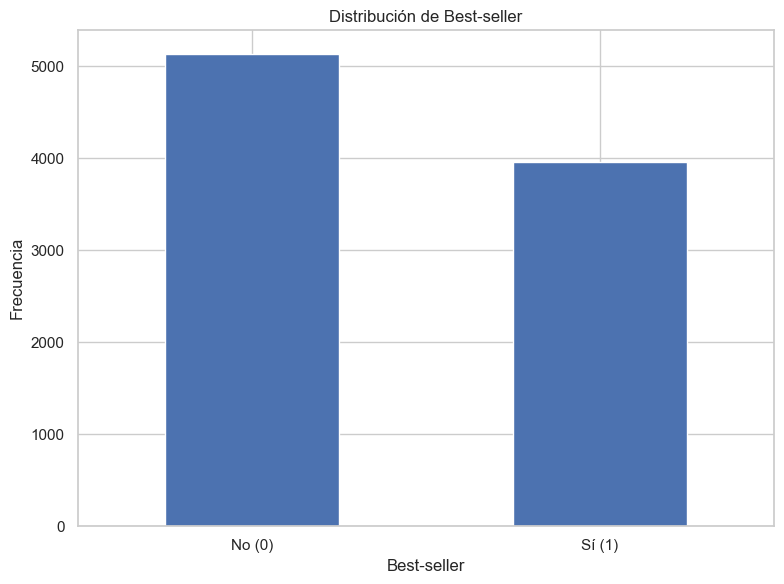

In [54]:
# Visualizar la distribución de Best-seller
plt.figure(figsize=(8, 6))
freqs.sort_index().plot(kind='bar')   # Usamos freqs, no bestseller_counts
plt.title('Distribución de Best-seller')
plt.xlabel('Best-seller')
plt.ylabel('Frecuencia')
plt.xticks([0, 1], ['No (0)', 'Sí (1)'], rotation=0)
plt.tight_layout()
plt.savefig("../Visualizaciones/Distribución de Best-seller.png", dpi=300, bbox_inches="tight")
plt.show()

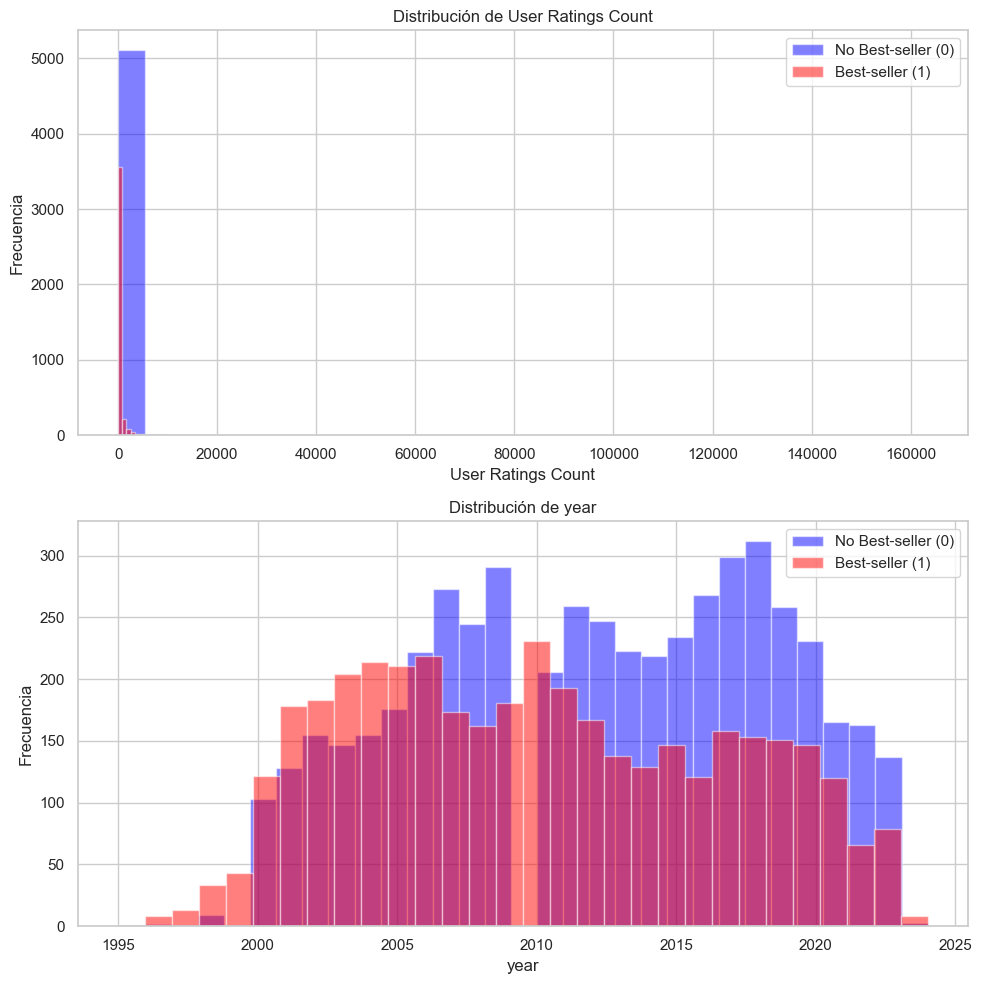

In [55]:
# Visualización de variables numéricas
numerical_vars = ['User Ratings Count', 'year']

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for idx, var in enumerate(numerical_vars):
    # Separar por clase
    bestseller_yes = data[data['Best-seller'] == 1][var]
    bestseller_no = data[data['Best-seller'] == 0][var]
    
    # Histograma
    axes[idx].hist(bestseller_no, bins=30, alpha=0.5, label='No Best-seller (0)', color='blue')
    axes[idx].hist(bestseller_yes, bins=30, alpha=0.5, label='Best-seller (1)', color='red')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].set_title(f'Distribución de {var}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig("../Visualizaciones/Distribución de numericas.png", dpi=300, bbox_inches="tight")
plt.show()

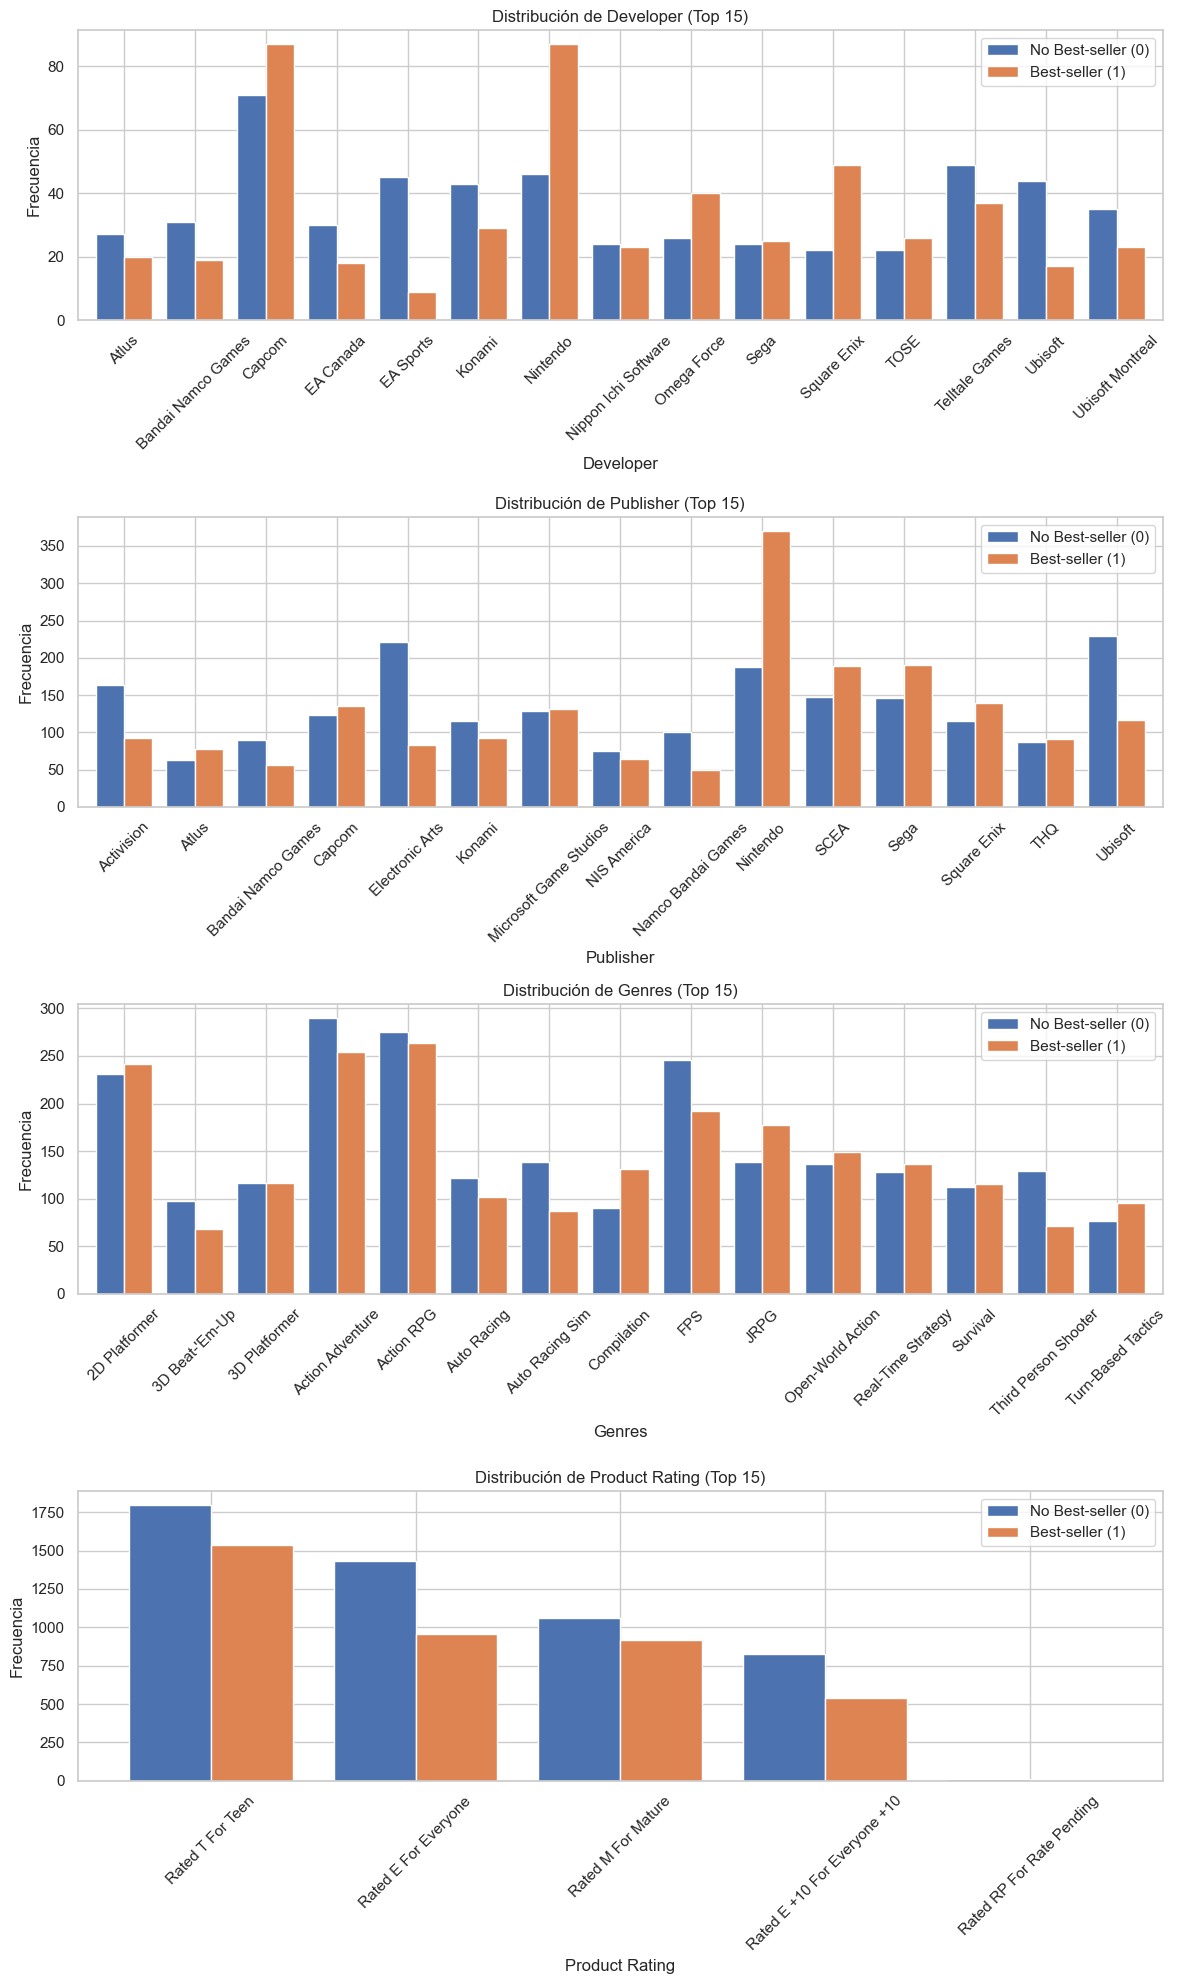

In [56]:
# Visualización de variables categóricas
categorical_vars = ['Developer', 'Publisher', 'Genres', 'Product Rating']

# Crear figura con subplots
fig, axes = plt.subplots(len(categorical_vars), 1, figsize=(12, 20))

for idx, var in enumerate(categorical_vars):
    # Top 15 categorías más frecuentes (si no no se puede interpretar)
    top_categories = data[var].value_counts().head(15).index
    
    # Filtrar datos
    data_filtered = data[data[var].isin(top_categories)]
    
    # Contar por clase
    bestseller_yes = data_filtered[data_filtered['Best-seller'] == 1][var].value_counts()
    bestseller_no = data_filtered[data_filtered['Best-seller'] == 0][var].value_counts()
    
    # Combinar
    df_plot = pd.DataFrame({'No Best-seller (0)': bestseller_no, 'Best-seller (1)': bestseller_yes}).fillna(0)
    
    # Gráfico de barras
    df_plot.plot(kind='bar', ax=axes[idx], width=0.8)
    axes[idx].set_title(f'Distribución de {var} (Top 15)')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].legend()
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../Visualizaciones/Distribución de categóricas.png", dpi=300, bbox_inches="tight")
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>

1. Evalúa la relación de las frecuencias de la variable `Best-seller`. Reflexiona sobre cómo se distribuyen los valores de la clase objetivo. ¿Es la distribución significativamente desigual? ¿Qué implica esto para el análisis y la modelización de los datos?
2. Analiza la información proporcionada por los histogramas de las variables descriptoras. Observa si hay diferencias notables en las distribuciones de estas variables entre las clases. Pregúntate: ¿Hay variables que muestren patrones distintos en función de si el juego es un éxito de ventas?
3. Considera si hay otras formas de visualización que podrían ser útiles para entender mejor los datos. Por ejemplo, ¿serían útiles los diagramas de caja (boxplots) para visualizar la distribución de las variables en ambas clases? ¿Podría un mapa de calor de la matriz de correlación entre variables ayudarte a entender las relaciones entre ellas?

Este análisis te ayudará a obtener una comprensión más profunda de la naturaleza de tus datos y a identificar posibles características que podrían ser importantes para identificar los futuros blockbusters.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

**1. Relación de frecuencias de Best-seller:**

El análisis de la distribución de la variable objetivo revela un desbalance moderado entre clases, factor crucial para considerar en el proceso de modelización y selección de métricas de evaluación.

La variable objetivo presenta una distribución moderadamente desbalanceada:
- No *Best-seller* (0): 5132 juegos (56.49%)
- *Best-seller* (1): 3953 juegos (43.51%)

Esto implica que los modelos podrían tener un sesgo hacia la clase mayoritaria, por lo que será necesario considerar métricas más robustas que la precisión simple (como F1-score, recall o AUC-ROC) y posiblemente técnicas de balanceo.

**2. Análisis de histogramas de variables descriptoras:**

Este análisis  de las distribuciones permite identificar patrones diferenciadores entre clases y evaluar el potencial predictivo de cada variable.

**Numéricas:**

- **`User Ratings Count`**: Ambas clases muestran una concentración extrema en valores bajos (cercanos a 0), con distribución fuertemente sesgada. La mayoría de juegos tienen pocas valoraciones, independientemente de ser *best-sellers*. La diferencia entre clases no es visualmente evidente en este histograma debido a la escala, aunque se aprecia que los *best seller* tienen a tener una ligera cola hacia la derecha mientras los no *best-sellers* no la presentan.

- **`Year`**: Los *best-sellers* se concentran en el período 2000-2015, mientras que los no *best-sellers* tienen mayor presencia en años recientes (2015-2024). Esto sugiere que la variable año podría tener poder discriminativo.

**Categóricas:**

- **`Developer`**: Capcom muestra una alta proporción de best-sellers. La mayoría de desarrolladores presentan distribuciones similares entre ambas clases.

- **`Publisher`**: Nintendo destaca con un número elevado de best-sellers. La distribución varía considerablemente entre publishers.

- **`Genres`**: Action-Adventure y Action-RPG muestran proporciones similares entre clases. La categoría 2D Platformer tiene ligeramente más best-sellers que no best-sellers en términos absolutos.

- **`Product Rating`**: "Rated T For Teen" es la clasificación más frecuente en ambas clases, seguida de "Rated E For Everyone". Las proporciones entre clases son similares para cada rating.

**3. Otras formas de visualización:**

La exploración de técnicas de visualización alternativas complementaría el análisis exploratorio, permitiendo capturar aspectos no evidentes en los histogramas. Por ejemplo:

- **Diagramas de caja (boxplots)**: Sí, serían muy útiles para las variables numéricas. Los boxplots permitirían visualizar mejor la mediana, cuartiles y valores atípicos de `User Ratings Count` y `year` para cada clase, facilitando la comparación de distribuciones que en los histogramas se ven difusas debido al sesgo extremo de los datos.

- **Mapa de calor de correlación**: Tendría utilidad limitada en este dataset. Solo tenemos 2 variables numéricas (`User Ratings Count` y `year`), por lo que la matriz de correlación sería de 3x3 (incluyendo `Best-seller`). Sin embargo, podría revelar si existe correlación lineal entre estas variables y la variable objetivo, lo cual sería información valiosa para el modelado.

</strong>
</div>

<a id='ej33'></a>
## 3.3. Preprocesamiento de Datos (0.75 puntos)

El preprocesamiento de datos en ciencia de datos es un paso crucial que involucra la preparación y transformación de datos brutos en un formato adecuado para su posterior análisis y modelado. Este proceso incluye varias tareas esenciales:

1. **Limpieza de Datos**: Se eliminan o corrigen datos erróneos, incompletos, inexactos o irrelevantes. Esto puede incluir tratar con valores faltantes, corregir errores de entrada y manejar outliers.

2. **Normalización y Escalado**: Los datos se transforman para que estén en una escala común, sin distorsionar diferencias en los rangos de valores ni perder información. Por ejemplo, escalado min-max o estandarización.

3. **Codificación de Variables Categóricas**: Las variables categóricas (como género o país) se convierten en formatos numéricos para que puedan ser procesadas por algoritmos de aprendizaje automático, utilizando técnicas como codificación one-hot o codificación de etiquetas.

4. **División de Datos**: Los datos se dividen en conjuntos de entrenamiento, validación y prueba, permitiendo entrenar modelos, afinar hiperparámetros y evaluar el rendimiento del modelo de manera efectiva.

5. **Manejo de Datos Desbalanceados**: En casos de conjuntos de datos desbalanceados, se aplican técnicas como sobremuestreo o submuestreo para asegurar que el modelo no esté sesgado hacia la clase más frecuente.

6. **Ingeniería de Características**: Se crean nuevas variables (características) a partir de los datos existentes para mejorar la capacidad del modelo para aprender patrones y hacer predicciones.

El preprocesamiento es esencial para mejorar la calidad de los datos y hacerlos más adecuados y efectivos para análisis y modelado en proyectos de ciencia de datos.

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

elimina los atributos categóricos del conjunto de datos y en su lugar introduce la transformación de dichos atributos a tantas variables binarias como categorías tengan. Es importante que las nuevas columnas generadas sean de tipo entero. Recuerda que la codificación one-hot convierte las etiquetas categóricas en vectores binarios. En estos vectores, el valor de 1 se asigna a la posición correspondiente a la clase y el valor de 0 a todas las demás posiciones. Esto facilita que los modelos de aprendizaje automático procesen y entiendan las etiquetas categóricas.
<hr>
Sugerencia: utilizad la función "get_dummies" de "pandas".

</div>

In [57]:
# Aplicar codificación one-hot
data_encoded = pd.get_dummies(data, columns=categorical_vars, dtype=int)

# Verificar el resultado
print("="*60)
print("Resultados del One-hot encoding:")
print("="*60)
print(f"    - Dimension de datos original: {data.shape}")
print(f"    - Dimension de datos después de one-hot encoding: {data_encoded.shape}")
print(f"\nTipos de datos de one-hot encoding:")
print(data_encoded.dtypes.value_counts())

Resultados del One-hot encoding:
    - Dimension de datos original: (9085, 7)
    - Dimension de datos después de one-hot encoding: (9085, 3903)

Tipos de datos de one-hot encoding:
int64      3902
float64       1
Name: count, dtype: int64


> La variable tipo float64 es `User Ratings Count` (variable numérica original que no se transformó).

<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

Ahora vamos a realizar la división del conjunto de datos, para ello sigue estos pasos:

1. Separa los descriptores de la variable respuesta. Asigna los descriptores al conjunto `X` y la variable respuesta al conjunto `y`.
2. Divide el _dataset_ en dos subconjuntos: uno para entrenamiento (_train_) y otro para pruebas (_test_). Asigna el 80% de los datos al conjunto de entrenamiento (`X_train`, `y_train`) y el 20% al conjunto de pruebas (`X_test`, `y_test`). Utiliza la función `train_test_split` de la biblioteca `model_selection` de `sklearn`. Asegúrate de usar `random_state = 24` y haz una división estratificada para mantener la misma proporción de clases en ambos conjuntos.

</div>

In [58]:
# Separar descriptores (X) de la variable respuesta (y)
X = data_encoded.drop('Best-seller', axis=1)
y = data_encoded['Best-seller']

# Verificar dimensiones
print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (9085, 3902)
Dimensiones de y: (9085,)


In [59]:
# 2. División train-test (80%-20%) con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=24, 
    stratify=y
)

# Imprimir dimensiones de los conjuntos
print(f"\nDimensiones del conjunto de entrenamiento:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"\nDimensiones del conjunto de test:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


Dimensiones del conjunto de entrenamiento:
X_train: (7268, 3902)
y_train: (7268,)

Dimensiones del conjunto de test:
X_test: (1817, 3902)
y_test: (1817,)


In [60]:
# Verificar estratificación
print("=" * 80)
print("Verificación de estratificación:")
print("=" * 80)
print(f"\nProporción de clases en conjunto original:")
print(y.value_counts(normalize=True))
print(f"\nProporción de clases en conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))
print(f"\nProporción de clases en conjunto de prueba:")
print(y_test.value_counts(normalize=True))

Verificación de estratificación:

Proporción de clases en conjunto original:
Best-seller
0    0.564887
1    0.435113
Name: proportion, dtype: float64

Proporción de clases en conjunto de entrenamiento:
Best-seller
0    0.564942
1    0.435058
Name: proportion, dtype: float64

Proporción de clases en conjunto de prueba:
Best-seller
0    0.564667
1    0.435333
Name: proportion, dtype: float64


<div class="alert alert-block alert-info">
<strong>Implementación:</strong>

1. Normaliza los descriptores utilizando el `StandardScaler` de `sklearn`. Esto estandarizará las características restando la media y dividiendo por la desviación estándar.
2. Muestra las dimensiones del conjunto de descriptores original, del conjunto de entrenamiento y del conjunto de prueba. Esto te permitirá ver cómo se han dividido los datos.

<strong>Nota:</strong> Ajusta el `StandardScaler` únicamente con los descriptores de entrenamiento para evitar la fuga de información o 'data leakage'. La fuga de información ocurre cuando se utiliza información del conjunto de prueba o validación en el proceso de ajuste del modelo. Es decir, si ajustas el modelo de escalado con todo el conjunto de datos, estarías utilizando información del conjunto de prueba o validación en el ajuste, lo que podría dar la impresión de que el modelo es más preciso de lo que realmente es. Por lo tanto, asegúrate de ajustar el `StandardScaler` solo con los datos de entrenamiento y luego aplicarlo a los conjuntos de entrenamiento y prueba.
</div>

In [61]:
# 1. Crear el StandardScaler
scaler = StandardScaler()

# Ajustar el scaler SOLO con los datos de entrenamiento
scaler.fit(X_train)

# Transformar tanto el conjunto de entrenamiento como el de prueba
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificar la normalización
print("=" * 80)
print(f"Verificación de normalización en X_train_scaled:")
print("=" * 80)
print(f"    - Media aproximada: {X_train_scaled.mean():.6f}")
print(f"    - Desviación estándar aproximada: {X_train_scaled.std():.6f}")

Verificación de normalización en X_train_scaled:
    - Media aproximada: -0.000000
    - Desviación estándar aproximada: 0.940163


<a id='ej34'></a>
## 3.4. Modelización (1.5 puntos)

La modelización es una fase crucial en la que tenemos que tomar muchas decisiones y ser muy rigurosos con la metodología. Varios de los puntos clave en esta fase son los siguientes:

- **Selección y configuración del modelo**: Elegir el algoritmo de clasificación más adecuado según el problema, los datos y los objetivos (por ejemplo, SVM, árboles de decisión, etc.), definiendo también los criterios de evaluación.

- **Entrenamiento y ajuste de hiperparámetros**: Entrenar el modelo con los datos disponibles y realizar una búsqueda de hiperparámetros (grid search, random search o técnicas bayesianas).

- **Evaluación y validación del modelo**: Medir el desempeño del modelo con métricas adecuadas (precisión, recall, F1-score, AUC, etc.) y validar su comportamiento con técnicas como la validación cruzada.

- **Explicabilidad del modelo**: Analizar e interpretar cómo y por qué el modelo toma decisiones, utilizando herramientas como coeficientes, SHAP, LIME o visualización de soporte vectorial, para asegurar transparencia y confianza en el uso del modelo.


<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> Este ejercicio lo vamos a abordar utilizar un modelo árbol de decisión. Para ello:

1. Define un clasificador `DecisionTreeClassifier` de la biblioteca `tree` de `sklearn` sin especificar ningún parámetro y calcula su precisión sobre el conjunto de train aplicando validación cruzada con 5 conjuntos.
2. Entrena un nuevo modelo sobre el conjunto de datos de train.
3. Calcula las siguientes métricas tanto en los datos de _train_ como de _test_:
    - Calcula la exactitud (accuracy) para medir la exactitud de las predicciones.
    - Calcula el valor F1, que es una medida que combina exactitud y sensibilidad.
4. Calcula la matriz de confusión utilizando los datos de _test_.

Utiliza el módulo `cross_val_score` de `sklearn` para aplicar la validación cruzada con el clasificador DecisionTree (de `DecisionTreeClassifier` de `sklearn`). 
</div>

In [62]:
# Definir el clasificador sin especificar parámetros
dt_classifier = DecisionTreeClassifier(random_state=24)

# Validación cruzada con 5 folds sobre el conjunto de entrenamiento 
cv_scores = cross_val_score(dt_classifier, X_train_scaled, y_train, cv=5, scoring='accuracy')

# Mostrar resultados
print("=" * 80)
print(f"Validación cruzada con 5 folds sobre el conjunto de entrenamiento:")
print("=" * 80)
print(f"    - Accuracy (CV) en cada fold: {cv_scores}")
print(f"    - Accuracy (CV) media: {cv_scores.mean():.4f}")
print(f"    - Desviación estándar: {cv_scores.std():.4f}")

Validación cruzada con 5 folds sobre el conjunto de entrenamiento:
    - Accuracy (CV) en cada fold: [0.65268226 0.64649243 0.68500688 0.66276669 0.65932553]
    - Accuracy (CV) media: 0.6613
    - Desviación estándar: 0.0131


In [63]:
# Entrenar el modelo sobre el conjunto de entrenamiento completo
dt_classifier.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,24
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [64]:

# Predicciones en train y test
y_train_pred = dt_classifier.predict(X_train_scaled)
y_test_pred = dt_classifier.predict(X_test_scaled)

# Calcular métricas para el conjunto de entrenamiento
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# Calcular métricas para el conjunto de prueba
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Mostrar metricas
print("=" * 80)
print(f"Resultados del modelo Decision Tree:")
print("=" * 80)
print(f"\nMétricas en el conjunto de ENTRENAMIENTO:")
print(f"    - Accuracy: {train_accuracy:.4f}")
print(f"    - F1-Score: {train_f1:.4f}")

print(f"\nMétricas en el conjunto de TEST:")
print(f"    - Accuracy: {test_accuracy:.4f}")
print(f"    - F1-Score: {test_f1:.4f}")

Resultados del modelo Decision Tree:

Métricas en el conjunto de ENTRENAMIENTO:
    - Accuracy: 0.9994
    - F1-Score: 0.9994

Métricas en el conjunto de TEST:
    - Accuracy: 0.6703
    - F1-Score: 0.5993


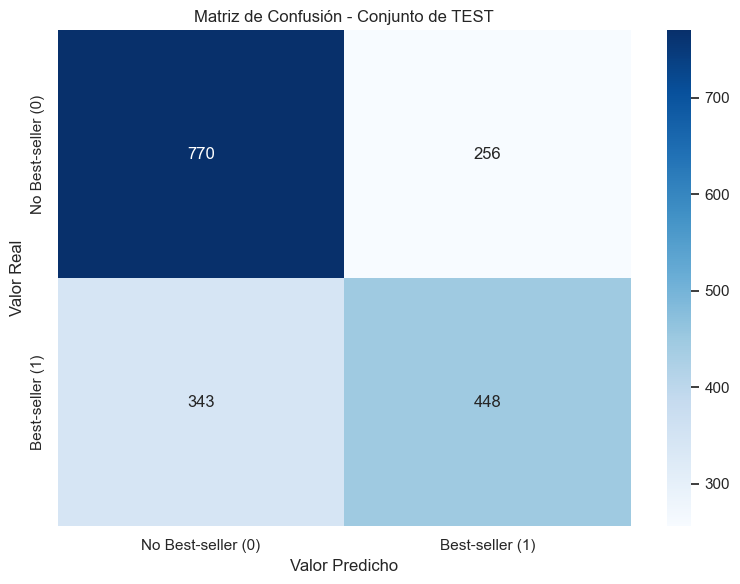


MATRIZ DE CONFUSIÓN

Verdaderos Negativos (No Best-seller correctos): 770
Falsos Positivos (No Best-seller -> Best-seller): 256
Falsos Negativos (Best-seller -> No Best-seller): 343
Verdaderos Positivos (Best-seller correctos): 448


In [65]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

# Visualización de la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Best-seller (0)', 'Best-seller (1)'],
            yticklabels=['No Best-seller (0)', 'Best-seller (1)'])
plt.title('Matriz de Confusión - Conjunto de TEST')
plt.ylabel('Valor Real')
plt.xlabel('Valor Predicho')
plt.tight_layout()
plt.savefig("../Visualizaciones/Matriz de confusión - ArbolDecision (TEST).png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print("MATRIZ DE CONFUSIÓN")
print("="*60)
print(f"\nVerdaderos Negativos (No Best-seller correctos): {cm[0,0]}")
print(f"Falsos Positivos (No Best-seller -> Best-seller): {cm[0,1]}")
print(f"Falsos Negativos (Best-seller -> No Best-seller): {cm[1,0]}")
print(f"Verdaderos Positivos (Best-seller correctos): {cm[1,1]}")

<div class="alert alert-block alert-info">
<strong>Análisis:</strong>
    
1. Realiza un análisis de los resultados y decide si consideras que este modelo es aceptable.
2. Evalúa cuál de las medidas de rendimiento utilizadas es la más apropiada.
3. Examina la distribución de las clases y plantea una estrategia, si es necesario, para asegurar la confiabilidad del estudio realizado.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:

**1. Análisis de resultados y aceptabilidad del modelo:**

El modelo presenta un caso claro de **sobreajuste severo**. Se observa un *accuracy* de 99.94% en entrenamiento que cae drásticamente a 67.03% en test, una diferencia de más de 32 puntos porcentuales. Esta brecha tan pronunciada indica que el árbol de decisión ha memorizado los datos de entrenamiento en lugar de aprender patrones generalizables.

El modelo **no es aceptable** para su uso en producción por varios motivos:
1. Un *accuracy* del 67% apenas supera el 56.5% que obtendríamos prediciendo siempre la clase mayoritaria.
2. La matriz de confusión revela que el modelo comete 343 falsos negativos (best-sellers clasificados como no best-sellers) y 256 falsos positivos, lo que representa un error considerable en ambas direcciones.
3. La validación cruzada ya anticipaba este problema con un *accuracy* medio de solo 66.13%, muy alejado del 99.94% del entrenamiento final.

**2. Evaluación de las medidas de rendimiento:**

En este contexto, el **F1-Score es la métrica más apropiada** para evaluar el modelo. El F1-Score en test (59.93%) es considerablemente inferior al *accuracy* (67.03%), lo que nos proporciona información valiosa, ya que esta discrepancia indica que el modelo tiene dificultades específicas con la clase positiva (*best-sellers*).

El *accuracy* puede ser engañoso en datasets desbalanceados como este (56.5% vs 43.5%). Un modelo que simplemente predijera siempre "No *Best-seller*" obtendría un 56.5% de *accuracy*. El F1-Score, al ser la media armónica de precisión y *recall*, penaliza más fuertemente los errores en la clase minoritaria y nos da una visión más realista del rendimiento, especialmente cuando nos interesa identificar correctamente los *best-sellers*.

**3. Estrategia para asegurar la confiabilidad del estudio:**

Para mejorar la confiabilidad del estudio, propongo una estrategia en tres frentes:

- **Control del sobreajuste:** Es fundamental establecer restricciones al árbol de decisión mediante hiperparámetros como `max_depth` (profundidad máxima), `min_samples_split` (mínimo de muestras para dividir un nodo) y `min_samples_leaf` (mínimo de muestras en hojas). Implementar una búsqueda sistemática de hiperparámetros mediante GridSearchCV o RandomizedSearchCV con validación cruzada nos permitirá encontrar un balance entre capacidad de aprendizaje y generalización.

- **Manejo del desbalance de clases:** Aunque el desbalance es moderado (56%-44%), puede estar afectando al rendimiento. Deberíamos explorar el parámetro `class_weight='balanced'` del DecisionTreeClassifier, que ajusta automáticamente los pesos de las clases inversamente proporcionales a sus frecuencias. Alternativamente, técnicas de remuestreo como SMOTE (sobremuestreo de la clase minoritaria) o submuestreo de la clase mayoritaria podrían equilibrar el conjunto de entrenamiento.

- **Validación robusta:** Implementar una validación cruzada estratificada más exhaustiva (por ejemplo, 10 folds) y monitorizar sistemáticamente múltiples métricas (*accuracy*, F1, precision, recall, AUC-ROC) tanto en cada fold como en el conjunto de test final. Esto nos permitirá detectar tempranamente problemas de sobreajuste y asegurar que el modelo seleccionado realmente generaliza bien.

La gran cantidad de características (3902 columnas después del one-hot encoding) también puede estar contribuyendo al sobreajuste. Sería recomendable explorar técnicas de selección de características o reducción de dimensionalidad para quedarnos solo con las variables más informativas.
</strong>
</div>

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> Repite el procedimiento anterior considerando la estrategia que consideres necesaria para mejorar la confiabilidad del modelo. 
</div>

In [66]:
# Modelo con restricciones para evitar sobreajuste
dt_balanced = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=24
)

# Validación cruzada
cv_scores_balanced = cross_val_score(dt_balanced, X_train_scaled, y_train, cv=10, scoring='accuracy')
cv_scores_f1 = cross_val_score(dt_balanced, X_train_scaled, y_train, cv=10, scoring='f1')

print("=" * 80)
print("Validación cruzada con 10 folds (modelo con restricciones):")
print("=" * 80)
print(f"    - Accuracy (CV) media: {cv_scores_balanced.mean():.4f} (+/- {cv_scores_balanced.std():.4f})")
print(f"    - F1-Score (CV) medio: {cv_scores_f1.mean():.4f} (+/- {cv_scores_f1.std():.4f})")

Validación cruzada con 10 folds (modelo con restricciones):
    - Accuracy (CV) media: 0.6710 (+/- 0.0166)
    - F1-Score (CV) medio: 0.6101 (+/- 0.0267)


In [67]:
# Definir grid de hiperparámetros
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 30],
    'class_weight': ['balanced', None]
}

# Búsqueda de hiperparámetros con validación cruzada estratificada
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=24),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("="*60)
print("RESULTADOS DE LA BÚSQUEDA")
print("="*60)
print(f"\nMejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print(f"\nMejor F1-Score en validación cruzada: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
RESULTADOS DE LA BÚSQUEDA

Mejores hiperparámetros encontrados:
{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 20, 'min_samples_split': 100}

Mejor F1-Score en validación cruzada: 0.6142


In [68]:
# Usar el mejor modelo encontrado
best_dt = grid_search.best_estimator_

# Predicciones
y_train_pred_best = best_dt.predict(X_train_scaled)
y_test_pred_best = best_dt.predict(X_test_scaled)

# Calcular métricas completas
print("\n" + "=" * 80)
print("Resultados del modelo OPTIMIZADO:")
print("=" * 80)

# Métricas en train
train_accuracy_best = accuracy_score(y_train, y_train_pred_best)
train_f1_best = f1_score(y_train, y_train_pred_best)
train_auc = roc_auc_score(y_train, best_dt.predict_proba(X_train_scaled)[:, 1])

print(f"\nMétricas en ENTRENAMIENTO:")
print(f"    - Accuracy: {train_accuracy_best:.4f}")
print(f"    - F1-Score: {train_f1_best:.4f}")
print(f"    - AUC-ROC: {train_auc:.4f}")

# Métricas en test
test_accuracy_best = accuracy_score(y_test, y_test_pred_best)
test_f1_best = f1_score(y_test, y_test_pred_best)
test_auc = roc_auc_score(y_test, best_dt.predict_proba(X_test_scaled)[:, 1])

print(f"\nMétricas en TEST:")
print(f"    - Accuracy: {test_accuracy_best:.4f}")
print(f"    - F1-Score: {test_f1_best:.4f}")
print(f"    - AUC-ROC: {test_auc:.4f}")

print(f"\nDiferencia Train-Test (Accuracy): {abs(train_accuracy_best - test_accuracy_best):.4f}")
print(f"Diferencia Train-Test (F1-Score): {abs(train_f1_best - test_f1_best):.4f}")


Resultados del modelo OPTIMIZADO:

Métricas en ENTRENAMIENTO:
    - Accuracy: 0.7020
    - F1-Score: 0.6622
    - AUC-ROC: 0.7741

Métricas en TEST:
    - Accuracy: 0.6582
    - F1-Score: 0.6121
    - AUC-ROC: 0.7158

Diferencia Train-Test (Accuracy): 0.0438
Diferencia Train-Test (F1-Score): 0.0501


In [69]:
print("\n" + "=" * 80)
print("REPORTE DE CLASIFICACIÓN DETALLADO (TEST):")
print("=" * 80)
print(classification_report(y_test, y_test_pred_best, 
                          target_names=['No Best-seller', 'Best-seller']))


REPORTE DE CLASIFICACIÓN DETALLADO (TEST):
                precision    recall  f1-score   support

No Best-seller       0.70      0.69      0.69      1026
   Best-seller       0.60      0.62      0.61       791

      accuracy                           0.66      1817
     macro avg       0.65      0.65      0.65      1817
  weighted avg       0.66      0.66      0.66      1817



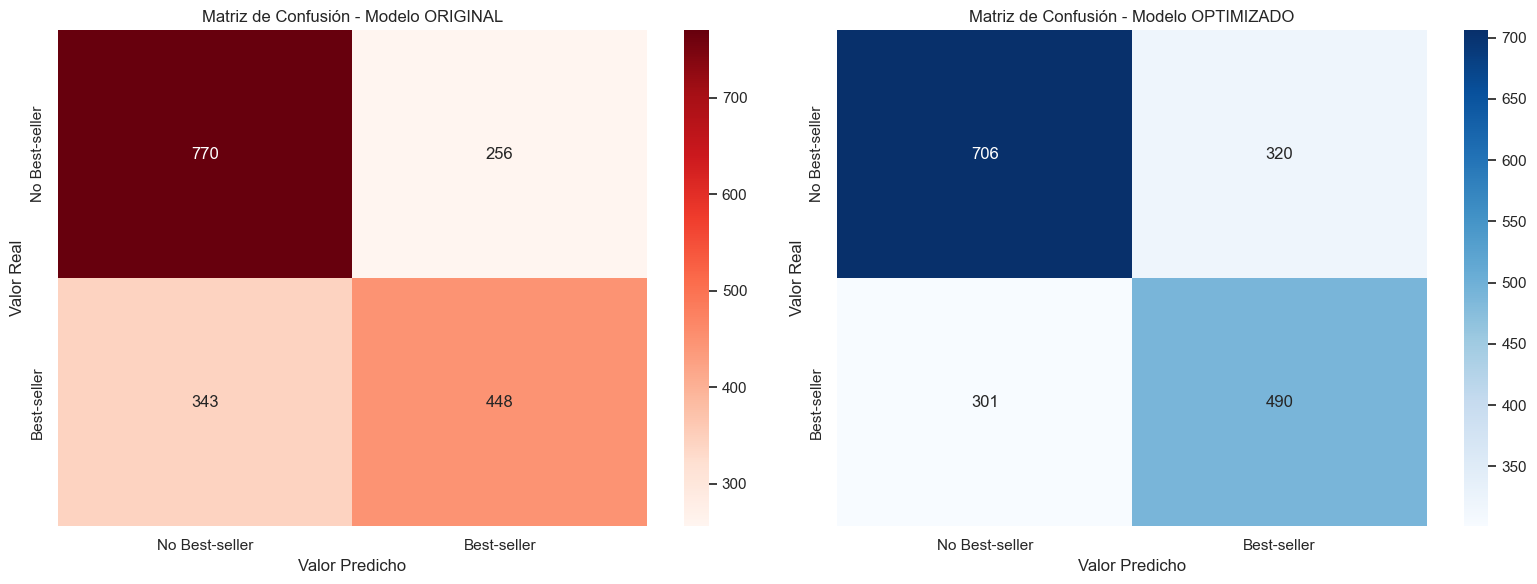


COMPARACIÓN DE MATRICES DE CONFUSIÓN

Modelo ORIGINAL:
    - Verdaderos Negativos: 770
    - Falsos Positivos: 256
    - Falsos Negativos: 343
    - Verdaderos Positivos: 448

Modelo OPTIMIZADO:
    - Verdaderos Negativos: 706
    - Falsos Positivos: 320
    - Falsos Negativos: 301
    - Verdaderos Positivos: 490


In [70]:
# Calcular matriz de confusión
cm_best = confusion_matrix(y_test, y_test_pred_best)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matriz original
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=axes[0],
            xticklabels=['No Best-seller', 'Best-seller'],
            yticklabels=['No Best-seller', 'Best-seller'])
axes[0].set_title('Matriz de Confusión - Modelo ORIGINAL')
axes[0].set_ylabel('Valor Real')
axes[0].set_xlabel('Valor Predicho')

# Matriz optimizada
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['No Best-seller', 'Best-seller'],
            yticklabels=['No Best-seller', 'Best-seller'])
axes[1].set_title('Matriz de Confusión - Modelo OPTIMIZADO')
axes[1].set_ylabel('Valor Real')
axes[1].set_xlabel('Valor Predicho')

plt.tight_layout()
plt.savefig("../Visualizaciones/Comparación matrices - Original vs Optimizado.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("COMPARACIÓN DE MATRICES DE CONFUSIÓN")
print("=" * 80)
print("\nModelo ORIGINAL:")
print(f"    - Verdaderos Negativos: {cm[0,0]}")
print(f"    - Falsos Positivos: {cm[0,1]}")
print(f"    - Falsos Negativos: {cm[1,0]}")
print(f"    - Verdaderos Positivos: {cm[1,1]}")

print("\nModelo OPTIMIZADO:")
print(f"    - Verdaderos Negativos: {cm_best[0,0]}")
print(f"    - Falsos Positivos: {cm_best[0,1]}")
print(f"    - Falsos Negativos: {cm_best[1,0]}")
print(f"    - Verdaderos Positivos: {cm_best[1,1]}")

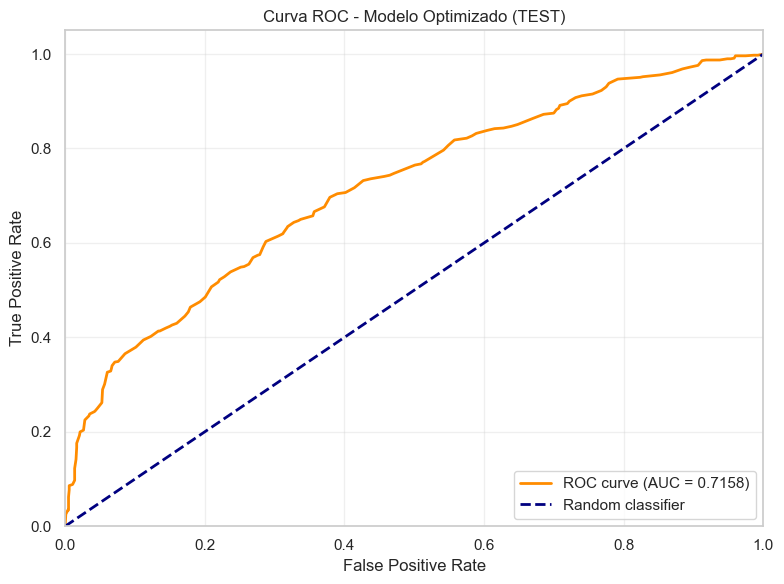

In [71]:
# Calcular probabilidades para la curva ROC
y_test_proba = best_dt.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

# Visualizar curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {test_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo Optimizado (TEST)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../Visualizaciones/Curva ROC - Modelo Optimizado.png", dpi=300, bbox_inches="tight")
plt.show()

<div class="alert alert-block alert-info">
<strong>Análisis:</strong> Justifica la respuesta para cada una de las siguientes preguntas:
    
1. ¿Has conseguido mejorar el rendimiento del modelo? ¿es suficiente?
2. ¿Hay algún atributo descriptivo que no lo consideres válido para el problema que estamos resolviendo?
3. ¿Cómo consideras que podríamos mejorar el rendimiento del modelo?
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:</strong>

**1. ¿Has conseguido mejorar el rendimiento del modelo? ¿es suficiente?**

Sí, **el modelo ha mejorado significativamente**, aunque diría el rendimiento **todavía no es óptimo para su uso en producción**. La mejora más importante es la **eliminación casi total del sobreajuste**, evidenciada por la diferencia entre train y test que se ha reducido drásticamente de 32 puntos porcentuales en *accuracy* a solo 4.38 puntos, y de 40 puntos en F1-score a 5 puntos. Esto indica que **ahora el modelo generaliza adecuadamente**.

Sin embargo, el rendimiento absoluto sigue siendo moderado. El F1-score en test pasó de 59.93% a 61.21%, una mejora de solo 1.28 puntos porcentuales. Lo más relevante es que ahora este valor está mucho más cerca del obtenido en validación cruzada (61.42%), lo que confirma que el modelo es consistente y confiable. El AUC-ROC de 0.7158 indica que el modelo tiene una capacidad de discriminación aceptable pero mejorable.

Por otro lado, analizando la matriz de confusión, se observan cambios importantes: 
- Los verdaderos positivos aumentaron de 448 a 490 (42 *best-sellers* más correctamente identificados), aunque esto vino acompañado de un aumento de falsos positivos de 256 a 320. 
- La reducción de falsos negativos de 343 a 301 es especialmente valiosa desde una perspectiva de negocio, ya que significa que perdemos menos oportunidades de identificar juegos que realmente serán éxitos de ventas.

**¿Es suficiente?** Depende del contexto empresarial. Para una **herramienta de apoyo a la decisión que se combine con análisis humano**, este modelo es aceptable. Para un sistema automático de inversión, probablemente no sea suficiente y requeriría más mejoras.

**2. ¿Hay algún atributo descriptivo que no lo consideres válido para el problema que estamos resolviendo?**

El atributo `User Ratings Count` presenta problemas conceptuales importantes. Esta variable mide el número de valoraciones que ha recibido un videojuego, pero esto crea un problema de causalidad inversa o "*data leakage* temporal", puesto que los juegos que se convierten en *best-sellers* naturalmente reciben más valoraciones porque más personas los compran y juegan. Por tanto, esta variable no está disponible *antes* del lanzamiento del juego, que es cuando necesitamos hacer la predicción.

Si estuviéramos desarrollando un sistema predictivo para decidir qué juegos financiar o en qué invertir recursos de marketing, esta variable sería inútil porque no la conoceríamos hasta después del lanzamiento. Incluirla en el modelo actual lo hace más un análisis retrospectivo ("explicar por qué un juego fue exitoso") que un modelo predictivo genuino ("predecir si un juego será exitoso").

Las demás variables las consideraría como válidas. `Developer`, `Publisher`, `Genres` y `Product Rating` son características que se conocen antes del lanzamiento y tienen sentido predictivo (estudios con mejor historial, géneros más populares, etc.). El año también sería válido, ya que captura tendencias temporales del mercado de videojuegos como se observo en los histogramas de apartados anteriores.

**3. ¿Cómo consideras que podríamos mejorar el rendimiento del modelo?**

Propongo tres estrategias principales para mejorar el rendimiento:

1. **Ingeniería de características avanzada:** Deberíamos crear variables agregadas que capturen información histórica, como la tasa de éxito previa de cada `Developer` o `Publisher` (por ejemplo, "porcentaje de *best-sellers* lanzados por Nintendo en los últimos 3 años"). También podríamos crear interacciones entre variables, como "Publisher_Nintendo × Genres_Action-Adventure", que capturen sinergias específicas. Las 3902 variables one-hot son excesivas y dispersan la información; agrupar developers/publishers poco frecuentes en categorías "Otros" reduciría la dimensionalidad manteniendo información relevante.

2. **Eliminación de `User Ratings Count`:** Como mencioné, esta variable debe eliminarse o reemplazarse por una métrica *proxy* disponible pre-lanzamiento, como la popularidad de lanzamientos anteriores del mismo developer en redes sociales, o el presupuesto de marketing estimado.

3. **Tratamiento más sofisticado del desbalance:** Aunque aplicamos `class_weight='balanced'`, podríamos probar técnicas de remuestreo como SMOTE para generar ejemplos sintéticos de *best-sellers*, o ajustar manualmente el threshold de clasificación (actualmente 0.5) según el coste relativo de falsos positivos vs falsos negativos desde una perspectiva de negocio.
</strong>
</div>

<div class="alert alert-block alert-info">
    <strong>Implementación:</strong> Los árboles de decisión nos permiten calcular la contribución relativa de cada atributo descriptivo al rendimiento predictivo del modelo. Para ello,

1. Calcula la contribución relativa de cada atributo utilizando el atributo `feature_importances_`.
2. Crea un DataFrame que contenga dos columnas, el nombre del atributo descriptivo y su contribución.
3. Ordena las filas por el valor de contribución.
4. Muestra el DataFrame resultante.

</div>


In [72]:
# Obtener la importancia de características del modelo optimizado
feature_importances = best_dt.feature_importances_

# Crear DataFrame con nombres de características y su importancia
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Ordenar por importancia descendente
feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

# Mostrar el DataFrame resultante
print("=" * 80)
print("IMPORTANCIA DE CARACTERÍSTICAS (Top 20)")
print("=" * 80)
print(feature_importance_df.head(20).to_string(index=False))

print("\n" + "=" * 80)
print("ESTADÍSTICAS DE IMPORTANCIA")
print("=" * 80)
print(f"Total de características: {len(feature_importance_df)}")
print(f"Características con importancia > 0: {(feature_importance_df['Importance'] > 0).sum()}")
print(f"Características con importancia = 0: {(feature_importance_df['Importance'] == 0).sum()}")
print(f"Suma total de importancias: {feature_importance_df['Importance'].sum():.4f}")

IMPORTANCIA DE CARACTERÍSTICAS (Top 20)
                            Feature  Importance
                 User Ratings Count    0.505781
                               year    0.287564
          Publisher_Electronic Arts    0.035181
               Publisher_Activision    0.021111
  Product Rating_Rated M For Mature    0.017232
                  Publisher_Ubisoft    0.015690
                         Genres_FPS    0.014455
    Product Rating_Rated T For Teen    0.013474
Product Rating_Rated E For Everyone    0.009879
               Genres_2D Platformer    0.009029
                 Publisher_Nintendo    0.008211
                     Publisher_Sega    0.007387
                 Publisher_2K Games    0.005599
                 Genres_Compilation    0.005275
              Developer_Omega Force    0.004956
                  Genres_Action RPG    0.004756
                        Genres_JRPG    0.004424
            Genres_Action Adventure    0.004341
   Publisher_Microsoft Game Studios    0.003663


<div class="alert alert-block alert-info">
<strong>Análisis:</strong>
    
Relaciona la interpretación de la contribución de los atributos descriptivos con el análisis exploratorio de los datos realizado en el ejercicio 3.2.
</div>

<div class="alert alert-block alert-success">
<strong>Respuesta:


El análisis de importancia de características valida y cuantifica los patrones observados en el EDA, aunque con matices importantes.

**Confirmaciones principales:**

La dominancia de `User Ratings Count` (50.58%) confirma la diferencia sutil observada en los histogramas: los best-sellers tienen una cola hacia valores altos que el modelo capturó como el factor más discriminativo, aunque esto representa un problema de causalidad inversa. La variable `year` (28.76%) valida completamente el patrón visual del EDA donde los best-sellers se concentraban en 2000-2015, confirmando que el momento de lanzamiento tiene poder predictivo genuino.

**Discrepancias reveladoras:**

La jerarquía de importancia contradice parcialmente las frecuencias absolutas observadas. Electronic Arts lidera entre publishers (3.52%) a pesar de tener menos best-sellers que Nintendo (0.82%), sugiriendo que EA funciona mejor como "señal discriminativa" incluso con menos volumen. Capcom, que mostraba la mayor proporción de best-sellers en el EDA, está ausente del top 20, indicando que su información ya está capturada por otras variables.

Los géneros, aunque mostraban distribuciones diferenciadas en el EDA, tienen importancias moderadas (FPS: 1.45%, ninguno supera 2%), sugiriendo que son menos determinantes que el año o publisher. Product Rating aparece con importancias equilibradas (Rated M: 1.72%, Rated T: 1.35%, Rated E: 0.99%), confirmando las proporciones similares observadas entre clases en los histogramas.

**Hallazgo crítico:**

Solo **29 de 3902 características (0.74%) tienen importancia mayor que cero**, validando que visualizar solo el top 15 en el EDA fue acertado: el 99.26% de variables one-hot son irrelevantes, representando entidades poco frecuentes o sin poder discriminativo. Esto demuestra la ineficiencia del encoding sin agrupación y sugiere que feature engineering con categorías agrupadas habría sido más efectivo.

</strong>
</div>